# Reporting — granular varieties, comparative advantage at the attraction-area level

Companion to `analysis.ipynb` (the continuum / ZE-level reporting), for runs made with
`./run.sh <industry> --granular=true --ca_level=aa`.

What differs from the old notebook:

* the moment vector has a sixth block, $\bar G_s(0)$, and the $\gamma$ block lives at the
  **attraction-area** level rather than the ZE level;
* the combined table reports the labor share and the industry shares only;
* the cloglog distance coefficients and $\bar G_s(0)$ get their own figures, empirical
  against simulated, **with standard errors**;
* the Jacobian and the moment variance-covariance matrices get block-structured
  heatmaps, so which parameter block moves which moment block can be read off. The
  parameter axis now includes the **variety counts** $N_s$, on the same footing as the
  comparative advantages $T_{as}$: both are calibrated inside the model rather than
  searched over, and both belong in a picture of what the model's parameters do;
* every elasticity heatmap comes as a **triptych** — the matrix, the cells whose
  elasticity is drowned in simulation noise, and the matrix with those cells blanked —
  because an elasticity estimated from simulated moments is only readable where its
  Monte-Carlo standard deviation is small relative to its own size;
* a sensitivity / identification section thresholds the same elasticities, so the
  near-orthogonality of the $\alpha$ / $T_{as}$ / $N_s$ channels can be read off directly;
* an untargeted-moment section estimates, by Poisson pseudo-maximum-likelihood
  (`pyfixest.fepois`) on the simulated firm-level economy, the distance elasticity
  $\eta$ of $\mathbb{E}[a_{ir}]$ — under a sector $\times$ buyer-region effect, a
  **supplier** effect and both — and compares it with the reduced-form $\delta/\gamma$
  of Table 3, on the reduced form's own scale rather than as a raw elasticity;
* a comparative-advantage section weighs $T_{as}$ against distance within each sector, as
  **six tests taken one at a time**: the spread of $\hat T$, what it is worth in distance,
  whether the favoured area actually wins buyer by buyer, which force disperses the
  competition, what the Sinkhorn inversion implies for the covariance term, and the
  allocation of winners with one force switched off;
* an amplification section reproduces Figure 6 — the coefficient $D_r$ and the share
  of upstream sales within a radius of the shock, the radius being a free parameter;
* the loader takes `mu = 1` (step-1 best parameters) or `mu = 2` (step-3 best parameters).

`load_granular_data` returns a flat dict, so the `analysis.ipynb` pattern still works:

```python
data = load_granular_data(industry, mu=2)
globals().update(data)
```

**How the notebook is organised.** Every section is a pair: one cell that *defines* its
functions, one cell that *runs* it on both industries and writes its figures. Each pair
can be executed on its own, and the last cell of the notebook (`Full Run`) re-executes
all of them in order for a clean end-to-end pass. A new figure therefore has to be added
in two places: its own section's run cell, and the full run.


## Setup

In [86]:
%pip install matplotlib pandas statsmodels seaborn geopandas pyfixest pyarrow



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [87]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
import pyfixest as pf          # PPML with absorbed fixed effects (ppmlhdfe)

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

`load_granular_data` rebuilds on the Python side the moment layout that
`load_parameters.jl` builds under `--granular=true --ca_level=aa`. The full (unmasked)
moment vector stacks six blocks in this order:

| # | block | length | content |
|---|-------|--------|---------|
| 1 | labor          | 1 | aggregate labor share |
| 2 | industry share | $S$ | share of the downstream industry's input bill going to each sector |
| 3 | $\pi_r$        | $R_d$ | share of downstream sales made in each downstream region |
| 4 | reg_coef       | $N_{REG}$ | distance-bin coefficients of the extensive margin (cloglog) |
| 5 | $\gamma$       | $S \times n_{AA}$ | sourcing shares by (sector, attraction area), sector-major |
| 6 | $\bar G_s(0)$  | $S$ | share of regions hosting no supplier of sector $s$ |

The criterion does not use all of them. `MOMENT_MASK` drops the first industry share and
the first $\pi_r$ (both are implied by the others adding up), every (sector, area) pair
with no observed supplier, and, in each sector, the **reference area** — the one with the
largest observed sourcing share, which the within-sector adding-up constraint determines
once the others are known. Block 6 is never masked.

**Which estimate is being reported.** `mu` selects it, and it selects *everything*
consistently — moments, standard errors, Jacobian, and the simulated firm-level economy:

| `mu` | estimate | moments | inference |
|------|----------|---------|-----------|
| 1 | $\hat\theta_1$, the Step-1 identity-weighted fit | `step1/best_simulated_moments.npy` | `step2/inference/` (inference *at* $\hat\theta_1$ is written there) |
| 2 | $\hat\theta_2$, the Step-3 efficiently-weighted fit | `step3/best_simulated_moments.npy` | `step3/inference/` |

The run folder is reconstructed from the flags rather than passed as a path, so a
mismatch between the flags used for estimation and the flags used here surfaces as a
missing folder instead of a plausible-looking but wrong set of numbers.


In [88]:
# Rebuilds, on the Python side, the moment layout `load_parameters.jl` builds under
# `--granular=true --ca_level=aa`, and reads back everything the reporting needs.
# The block layout, the mask and the meaning of `mu` are documented in the markdown
# cell above.

# mu -> (folder holding the moments, folder holding the inference)
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display NAME.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl` builds
    `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` covers more
    commuting zones than the model does, so the join is on the CODE, and a zone with no
    name falls back to its code rather than to NaN.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(_as_ze_string(fdf["ze2010"]).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def ze_name_of_code(data):
    """ZE code -> display name, for anything keyed on the code rather than the index."""
    lab = _region_labels(data)
    return dict(zip(lab["ze2010"], lab["ze2010_name"]))


def aa_display_names(data):
    """
    Attraction-area display names, in AA column order.

    Area `a` is anchored on the a-th downstream region, so its name is that commuting
    zone's name — which is what a reader recognises, unlike the bare ZE code.
    """
    m = ze_name_of_code(data)
    return [m.get(str(a), str(a)) for a in data["aa_names"]]


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`,
    `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS: # Load the best parameter index, either one or two. 
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level, 
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer) # Given the argument, construct the folder name. 
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy")) # Number of regression coefficients. 
    n_tau_path = folder / "n_tau.npy" 
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef  # Number of coefficients parametrizing the trade costs.  

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            row = sub[sub[c_K].astype(float).round().astype(int) == 0]
            if row.empty:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = float(row[c_G].values[0])
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    # Indices at where each moment starts.
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"] # Moment name
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem stacks three moment blocks in a fixed order — the
    # extensive-margin coefficients, the sourcing shares, the zero-supplier shares (the
    # "beta, gamma, G" ordering invariant of CLAUDE.md; the arrows used elsewhere in the
    # code name that stacking order, nothing causal).
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments — how
    #                      precisely each target is measured in the data;
    #   se_moments_fitted: sqrt(diag(G V G')), the SE of the FITTED moment. Under
    #                      profile_T, V is the SANDWICH covariance of alpha_hat and G the
    #                      PROFILED Jacobian dm/dalpha (alpha moved, T following through
    #                      the Sinkhorn inversion), so this is the delta-method
    #                      propagation of alpha_hat's sandwich SE — not an efficient SE
    #                      from the free-parameter Jacobian, which under profiling would
    #                      treat T as free when it is not.
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the parameters. The full free-parameter
    # Jacobian is saved for diagnostics at both estimates, even under profile_T (where
    # INFERENCE runs on the alpha-only profiled Jacobian instead).
    #
    # Under GRANULAR the Julia side appends the S VARIETY-COUNT columns dm/dN_s on the
    # right (compute_jacobian's `append_N_s`): N_s is calibrated by the integer bisection
    # exactly as T is calibrated by the Sinkhorn inversion, so both belong on the
    # parameter axis. `<file>_n_s_columns.npy` records how many were appended; older
    # trees have none, and the width settles it.
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    n_N_path = jac_dir / jac_file.replace(".npy", "_n_s_columns.npy")
    n_N_cols = int(np.load(n_N_path).ravel()[0]) if n_N_path.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_N_cols is None:
            n_N_cols = n_c - len(param_labels)
        if (n_r != int(mask.sum()) or n_c != len(param_labels) + n_N_cols
                or n_N_cols not in (0, S)):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters "
                f"(+{n_N_cols} variety counts) — the run's flags and the ones passed "
                "here disagree.")
        if n_N_cols:
            param_labels += [f"N_s[{sector_names[s]}]" for s in range(S)]
            param_block_sizes.append(S)
            param_block_names.append("Variety count")
    else:
        n_N_cols = n_N_cols or 0

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the same
    # three-block subsystem; Omega = Sigma_data + Sigma_sim is what the estimator
    # actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at — step1 for theta_hat_1, step3 for theta_hat_2 — so `mu`
    # selects the simulated economy exactly as it selects the moments and the inference.
    suppliers_path = folder / step_dir / "suppliers.parquet"
    suppliers = _opt(pd.read_parquet, suppliers_path) if suppliers_path.exists() else None
    w_srd_r_path = folder / step_dir / "w_srd_r.npy"
    w_srd_r = _opt(np.load, w_srd_r_path) if w_srd_r_path.exists() else None

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"], "n_N_cols": n_N_cols,
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "granular_diagnostics": granular_diag,
    }


## Constants

In [89]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 2
THETA_DEFAULT = 1.

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=True, optimizer="pso")

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

# Mean of log Dist in the EMPIRICAL estimation sample of the spatial-comovement
# regression (both industries). The reduced form is linear in the level of the exposure,
# so its delta/gamma is a compressed reading of an elasticity and the compression depends
# on this number — it is what puts the model's eta and the published delta/gamma on the
# same scale. See the untargeted-moment section.
EMPIRICAL_MEAN_LOG_D = 5.8

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Reporting

## Moment table

Empirical against simulated for the two blocks that read naturally as a table: the
aggregate labor share (Panel A) and the sectoral industry shares (Panel B), both
industries side by side, with `---` where a sector is absent from an industry's sample.

The distance coefficients and the zero-supplier shares are *not* table panels here. They
are few enough to plot, and they are the two blocks where the sampling uncertainty
matters for reading the fit, so they get their own figures with standard errors below.


In [90]:
def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex",
                            mu=2, name_A129_path="../external/A129_name_fr_eng.csv", **load_kwargs):
    """
    LaTeX table with one {Emp., Sim.} column pair per industry.

    Panel A: aggregate labor share.  Panel B: aggregate industry shares.

    industries_config : [{'industry': 'aero', 'display_name': 'Aerospace'}, ...]
    mu                : 1 (step1 best parameters) or 2 (step3 best parameters)
    """
    all_data = {c["industry"]: load_granular_data(c["industry"], mu=mu, **load_kwargs)
                for c in industries_config}

    try:
        name_A129 = pd.read_csv(name_A129_path)
    except Exception:
        name_A129 = None

    n_ind = len(industries_config)
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]"] * n_ind)
    header_row1 = " & " + " & ".join(
        [f"\\multicolumn{{2}}{{c}}{{{c['display_name']}}}" for c in industries_config]) + r" \\"
    cmidrules = " ".join([f"\\cmidrule(lr){{{2 + 2 * i}-{3 + 2 * i}}}" for i in range(n_ind)])
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}"] * n_ind) + r" \\"

    # --- Panel A -------------------------------------------------------------
    row_A = ["Aggregate Labor Share"]
    for c in industries_config:
        d = all_data[c["industry"]]
        row_A += [float(d["empirical_moments_dict"]["agg_labor_share"][0]),
                  float(d["simulated_moments_dict"]["agg_labor_share"][0])]

    # --- Panel B -------------------------------------------------------------
    all_codes = sorted({code for d in all_data.values() for code in d["sector_names"]})
    shares = {}
    for c in industries_config:
        d = all_data[c["industry"]]
        shares[c["industry"]] = pd.DataFrame({
            "A129": d["sector_names"],
            "Empirical": d["empirical_moments_dict"]["agg_industry_share"],
            "Simulated": d["simulated_moments_dict"]["agg_industry_share"],
        })

    panel_B_rows = []
    for code in all_codes:
        label = code
        if name_A129 is not None and "A129" in name_A129.columns:
            hit = name_A129.loc[name_A129["A129"].astype(str) == str(code), "name"].values
            if len(hit):
                label = hit[0]
        row = [label]
        for c in industries_config:
            df = shares[c["industry"]]
            m = df[df["A129"].astype(str) == str(code)]
            row += ([float(m.iloc[0]["Empirical"]), float(m.iloc[0]["Simulated"])]
                    if len(m) else ["---", "---"])
        panel_B_rows.append(row)

    def fmt(v, decimals=4):
        if isinstance(v, str) or (isinstance(v, float) and np.isnan(v)):
            return "{---}"
        return f"{v:.{decimals}f}"

    mu_label = r"$\hat{\mu}_1$ (Step~1)" if mu == 1 else r"$\hat{\mu}_2$ (Step~3)"
    tex = (r"\begin{table}[H]" "\n" r"\centering" "\n"
           r"\caption{Empirical and Simulated Moments: Comparison Across Industries}" "\n"
           r"\label{tab:moments_comparison_combined}" "\n"
           r"\renewcommand{\arraystretch}{1.2}" "\n" r"\small" "\n"
           r"\begin{tabular}{" + col_spec + "}\n" r"\toprule" "\n"
           + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n")

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    tex += "\\midrule\n"
    tex += row_A[0] + " & " + " & ".join(fmt(v) for v in row_A[1:]) + " \\\\\n"

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    tex += "\\midrule\n"
    for row in panel_B_rows:
        tex += str(row[0]) + " & " + " & ".join(fmt(v) for v in row[1:]) + " \\\\\n"

    tex += "\\bottomrule\n" + r"\end{tabular}" + "\n\n"
    tex += (r"\vspace{0.3cm}" "\n"
            r"\caption*{\footnotesize \emph{Notes}: Empirical moments against moments simulated "
            r"from the model calibrated on each industry, evaluated at " + mu_label + r". "
            r"``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A reports the aggregate labor "
            r"share, Panel~B the sectoral industry shares. ``---'' indicates the sector is not "
            r"present in that industry's sample. The distance-bin (cloglog) coefficients and the "
            r"zero-supplier shares $\bar{G}_s(0)$ are reported in separate figures, with standard "
            r"errors.}" "\n" r"\end{table}" "\n")

    if output_file is not None:
        os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
        with open(output_file, "w") as f:
            f.write(tex)
        print(f"Combined table saved to: {output_file}")
    return tex


In [91]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)


Combined table saved to: ../reporting_combined/moments_comparison_combined_mu2.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Motor Vehicles} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1551 & 0.1558 & 0.1489 & 0.1606 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0367 & 0.0357 & {---} & {---} \\
Plastic Manufacturing & 0.0673 & 0.0675 & 0.0149 & 0.0107 \\
Steel Manufacturing & 0.0314 & 0.0320 & {---} & {---} \\
Forging \& Metal Machining & 0.0797 & 0.0797 & 0.0132 & 0.0179 \\
Instrume

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


## Fit: sourcing shares and downstream sales

Simulated against empirical, on the 45-degree line. Bubble area is proportional to the
empirical value, so a visually large miss on a small moment is seen for what it is.

For the sourcing shares $\gamma_{s,a}$ the figure reproduces the first panel of the Julia
dashboard. Each sector's **reference area** is dropped from the criterion, so its
simulated value is not fitted directly; it is reconstructed from the within-sector
adding-up constraint

$$\gamma_{\text{ref},s} \;=\; c_s - \sum_{a \neq \text{ref}} \gamma_{s,a},$$

and drawn in a separate colour. The fit statistics annotated on the panel (a weighted
regression through the origin) use the non-reference points only — the reconstructed
ones are an identity, not an independent observation.


In [92]:
def bubble_scatter(ax, x, y, xlabel, ylabel, title, size_scale=300,
                   regression_line=False, weights=None, color=None, label=None):
    """Bubble scatter of simulated against empirical, with a WLS-through-origin fit."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = x > 0
    x, y = x[keep], y[keep]
    w = np.ones_like(x) if weights is None else np.asarray(weights, float)[keep]

    lims = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.1]
    ax.scatter(x, y, s=size_scale * x / x.max(), alpha=1, edgecolor="black",
               linewidths=0.5, color=color or toulouse_color, label=label)

    b, t = wls_through_origin(x, y, w)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    if regression_line:
        xx = np.linspace(0, lims[1], 100)
        ax.plot(xx, b * xx, linestyle="--", color="green")
    else:
        ax.plot(lims, lims, color="black")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)
    _despine(ax)
    return b, t


def wls_through_origin(x, y, weights=None):
    """b and its t-stat for y = b*x (no intercept); weights default to x."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = x if weights is None else np.asarray(weights, float)
    denom = np.sum(w * x ** 2)
    b = np.sum(w * x * y) / denom
    resid = y - b * x
    s2 = np.sum(w * resid ** 2) / max(len(x) - 1, 1)
    se = np.sqrt(s2 / denom)
    return b, (b / se if se > 0 else np.inf)


def gamma_aa_points(data):
    """
    Split the AA-level gamma moments into the two series the dashboard panel plots.

    Returns (x_free, y_free, x_ref, y_ref):
      * free      — active, non-reference (sector, AA) pairs, i.e. the moments that
                    actually enter the criterion;
      * reference — each sector's dropped reference area, RECONSTRUCTED from the
                    within-sector adding-up constraint
                        gamma_ref,s = domestic_share_s - sum_{a != ref} gamma_{s,a},
                    applied to the SIMULATED gammas; its x is the observed share.
    """
    emp, sim = data["empirical_moments_dict"]["gamma_aa"], data["simulated_moments_dict"]["gamma_aa"]
    S, ref, act, c = data["S"], data["T_REF_AA"], data["AA_ACTIVE"], data["domestic_share"]

    free = act.copy()
    for s in range(S):
        if ref[s] >= 0:
            free[s, ref[s]] = False

    x_free, y_free = emp[free], sim[free]
    x_ref, y_ref = [], []
    for s in range(S):
        if ref[s] < 0 or not free[s].any() or emp[s, ref[s]] <= 0:
            continue
        x_ref.append(emp[s, ref[s]])
        y_ref.append(c[s] - sim[s, free[s]].sum())
    keep = x_free > 0
    return x_free[keep], y_free[keep], np.array(x_ref), np.array(y_ref)


def plot_gamma_aa(data, ax=None, save_to=None):
    """Empirical vs simulated gamma at the attraction-area level (dashboard panel 1)."""
    x_free, y_free, x_ref, y_ref = gamma_aa_points(data)
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))

    all_x = np.concatenate([x_free, x_ref]) if len(x_ref) else x_free
    all_y = np.concatenate([y_free, y_ref]) if len(y_ref) else y_free
    lims = [min(all_x.min(), all_y.min()) * 0.9, max(all_x.max(), all_y.max()) * 1.1]

    ax.scatter(x_free, y_free, s=300 * x_free / x_free.max(), alpha=0.6, edgecolor="black",
               linewidths=0.5, color=sim_color, label="Non-reference")
    if len(x_ref):
        ax.scatter(x_ref, y_ref, s=60, marker="D", alpha=0.8, edgecolor="black",
                   linewidths=0.5, color=reference_color, label="Reference")

    # WLS through the origin on the NON-REFERENCE points only.
    b, t = wls_through_origin(x_free, y_free, weights=x_free)
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"Empirical ")
    ax.set_ylabel(r"Simulated ")
    ax.grid(linestyle="dashed", alpha=0.5)
    ax.legend(loc="upper left", frameon=False)   # bottom-right is taken by the fit annotation
    _despine(ax)

    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_pi_r(data, ax=None, save_to=None):
    """Empirical vs simulated downstream sales shares pi_r."""
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))
    bubble_scatter(ax,
                   data["empirical_moments_dict"]["emp_pi_r"],
                   data["simulated_moments_dict"]["emp_pi_r"],
                   r"Empirical", r"Simulated", None, size_scale=400)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


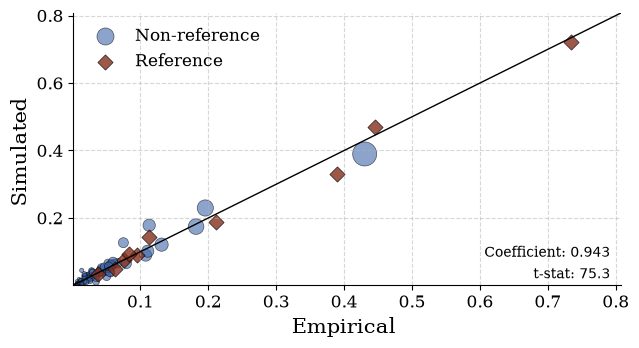

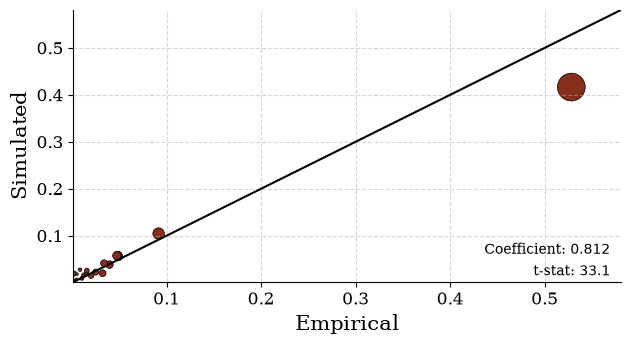

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


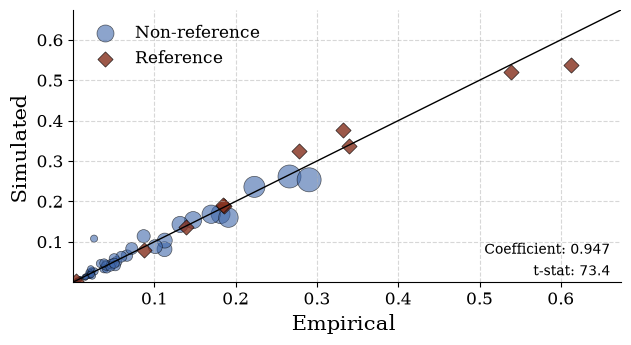

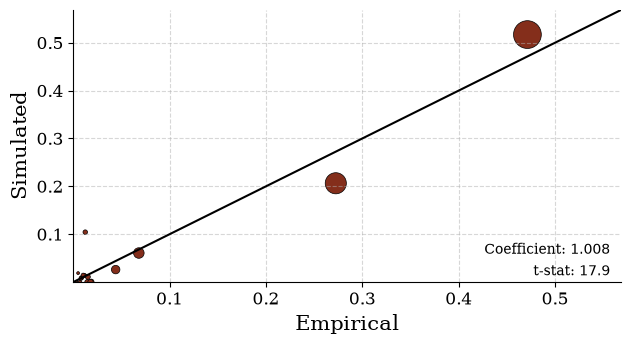

In [93]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()


## Fit with standard errors: extensive margin and zero-supplier share

The two blocks where the comparison is only meaningful against sampling uncertainty: the
cloglog distance-bin coefficients (block 4) and the zero-supplier shares $\bar G_s(0)$
(block 6). Each tick carries the empirical value on the left and the simulated one on the
right, both with 95% bars. **Two different objects, deliberately:**

* **Empirical bars** — $\sqrt{\mathrm{diag}(\Sigma_{data})}$, the bootstrap sampling
  standard error of the moment *in the data*. How precisely the target is measured.
* **Simulated bars** — `se_moments_fitted.npy`, the standard error of the *fitted*
  moment, $\sqrt{\mathrm{diag}(G\,V\,G')}$, i.e. the estimation uncertainty of the
  parameters carried through to the moment they generate.

Under the profiled estimator (`--profile_T=true`, what these runs use) $V$ is the
**sandwich** covariance of $\hat\alpha$ and $G = \partial m / \partial \alpha$ is the
*profiled* Jacobian — $\alpha$ moved with $T$ following through the Sinkhorn inversion.
So the simulated bar is the delta-method propagation of $\hat\alpha$'s sandwich standard
error onto that moment, not an efficient standard error built from the free-parameter
Jacobian: under profiling $T$ is not a free parameter, it is a function of $\alpha$ and of
the sourcing-share targets, and the reported bar takes that dependence into account.
Two consequences worth keeping in mind when reading the figure: the bar does *not*
include the data noise of the $\gamma$ targets that $T$ is inverted from (that channel is
reported separately, in Julia's `inference_delta.txt`), and $\bar G_s(0)$'s bar does not
include the uncertainty of $\hat N_s$, which is calibrated on that very moment.

Both numbers come out of the Julia inference step; nothing is re-estimated here.

Each sector of the $\bar G_s(0)$ panel is annotated with its profiled variety count
$\hat N_s$, starred when it sits on a bound: a sector clamped at a bound cannot close its
own count residual through $\hat N_s$, so a visible miss there is expected rather than a
fit failure.


In [94]:
REG_BIN_LABELS_5 = [r"$]0,50]$", r"$]50,100]$", r"$]100,150]$", r"$]150,200]$", r"$>200$"]


def reg_bin_labels(n_coef):
    if n_coef == 1:
        return [r"$\log d$"]
    if n_coef == 4:
        return REG_BIN_LABELS_5[1:]
    if n_coef == 5:
        return list(REG_BIN_LABELS_5)
    return [rf"$\beta_{{{i + 1}}}$" for i in range(n_coef)]


def _paired_errorbar(ax, labels, emp, sim, se_emp=None, se_sim=None, ci=1.96,
                     ylabel="", xlabel="", title=None, rotate=0):
    """Empirical (left) against simulated (right) at each tick, with +/- ci*SE bars."""
    x = np.arange(len(labels), dtype=float)
    off = 0.12
    ax.errorbar(x - off, emp, yerr=None if se_emp is None else ci * np.asarray(se_emp),
                fmt="o", color=toulouse_color, capsize=3, markersize=7,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Empirical")
    ax.errorbar(x + off, sim, yerr=None if se_sim is None else ci * np.asarray(se_sim),
                fmt="D", color=sim_color, capsize=3, markersize=6,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Simulated")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", linestyle="dashed", alpha=0.5)
    ax.legend(frameon=False)
    _despine(ax)
    return ax


def plot_reg_coef(data, ax=None, save_to=None, ci=1.96):
    """Empirical vs simulated cloglog distance coefficients, with SEs."""
    emp = np.asarray(data["empirical_moments_dict"]["reg_coef"], float)
    sim = np.asarray(data["simulated_moments_dict"]["reg_coef"], float)
    se_e = data["se_empirical"]["reg_coef"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["reg_coef"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, reg_bin_labels(data["n_coef"]), emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"Extensive margin coefficient",
                     xlabel="Distance bin (km)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_G0(data, ax=None, save_to=None, ci=1.96, annotate_N=True):
    """Empirical vs simulated Gbar_s(0) — the share of cells with no supplier."""
    if not data["granular"]:
        raise ValueError("Gbar_s(0) only exists under --granular=true")
    emp = np.asarray(data["empirical_moments_dict"]["G0"], float)
    sim = np.asarray(data["simulated_moments_dict"]["G0"], float)
    se_e = data["se_empirical"]["G0"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["G0"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, data["sector_names"], emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"$\bar{G}_s(0)$", xlabel="Sector (A129)", rotate=45)

    # The profiled variety count is what the model moves to hit this moment, so
    # print it next to each sector — a clamped sector cannot close its own residual.
    diag = data.get("granular_diagnostics")
    if annotate_N and diag is not None and "N_hat" in diag:
        N_hat = np.asarray(diag["N_hat"]).ravel()
        clamped = np.asarray(diag.get("clamped", np.zeros_like(N_hat))).ravel()
        top = ax.get_ylim()[1]
        for i, (n, cl) in enumerate(zip(N_hat, clamped)):
            ax.text(i, top, rf"$\hat{{N}}_s={int(n)}$" + ("*" if cl != 0 else ""),
                    ha="center", va="bottom", fontsize=font_size-3, rotation=45)
        ax.set_ylim(ax.get_ylim()[0], top * 1.02)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


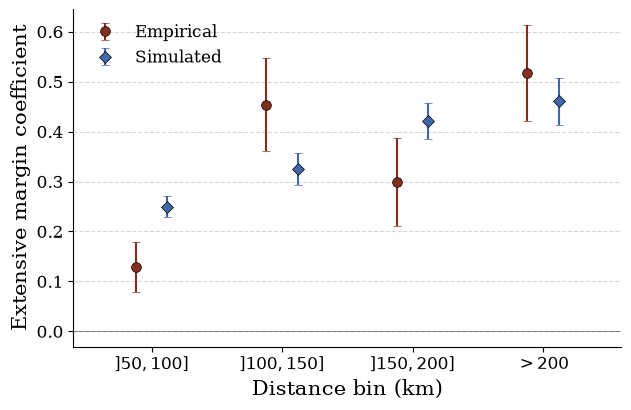

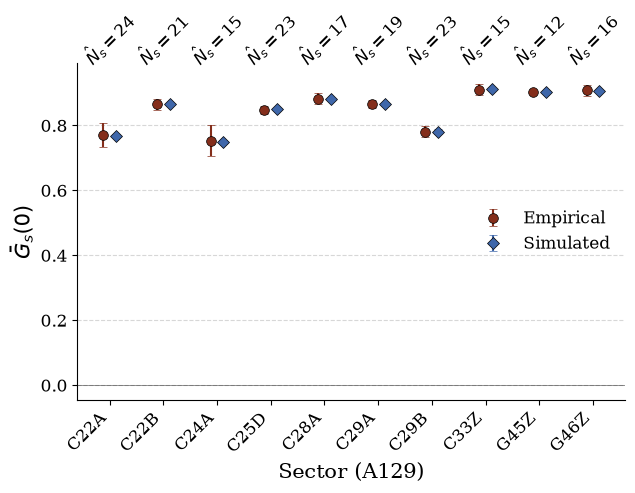

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_nlo1_pso/step3, SEs from step3/inference


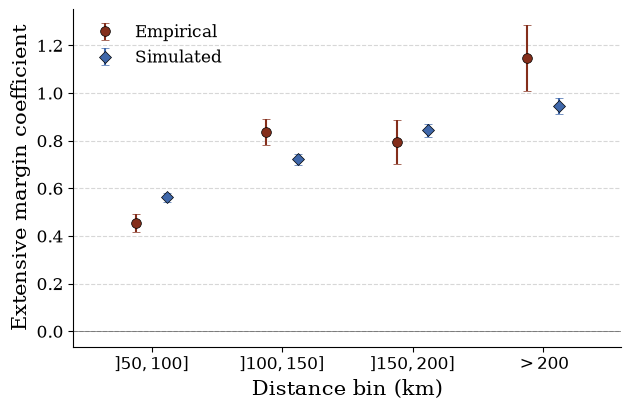

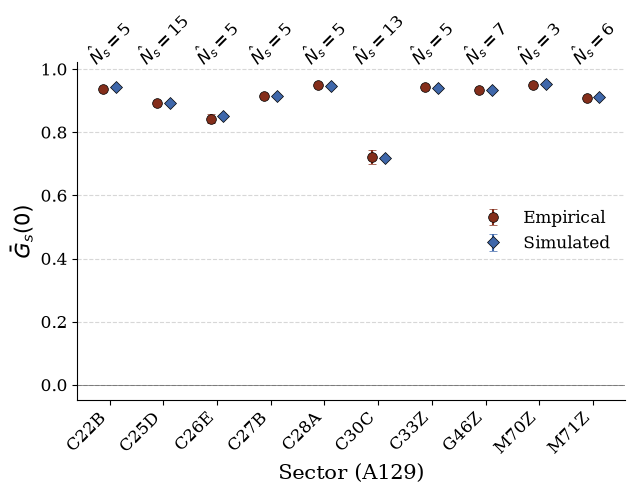

In [95]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # the analysis.ipynb pattern: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()


# Jacobian and variance-covariance


## Jacobian — which parameter moves which moment

Rows are the moments the criterion actually uses (the masked vector, six blocks),
columns are the parameters. The parameter axis is
$[\Omega^L \mid \Omega^s \mid A \mid \alpha \mid T \mid N_s]$: the head parameters, the
trade-cost elasticity, the comparative advantages, and — appended on the right — the
**variety counts**.

**Why $N_s$ is in the picture.** $T$ and $N_s$ are both *calibrated* rather than
searched over: $T$ is the Sinkhorn image that reproduces the observed sourcing shares at
a given $\alpha$, $N_s$ is the solution of $\bar G_s(n) = \hat G_s$ found by integer
bisection. $T$ appeared in the Jacobian only because it happens to be a coordinate of the
parameter vector and $N_s$ is not — a bookkeeping accident, not a statement about the
model. The Julia side now appends $\partial m/\partial N_s$ to the saved Jacobian, so the
matrix covers every parameter the model has. Two conventions for reading those columns:

* the derivative is a unit **first difference** $m(N_s+1) - m(N_s)$. $N_s$ is an integer,
  so one variety *is* the step and there is no step size to choose;
* the zeros outside block 6 are **structural**, not numerical. The two evaluations share
  the same productivity draws, so any moment with no $N_s$ term differences to exactly
  `0.0`, and Julia asserts it (the extensive margin is $N_s$-free by Proposition 1, the
  win probabilities by Lemma 2). An exact zero in an $N_s$ column is the model saying the
  channel does not exist, not a small number that fell below a threshold.

**What is plotted is the elasticity** $\varepsilon_{jk} = \partial \log m_j / \partial
\log \theta_k$ (for $N_s$, $\hat N_s \cdot \partial m_j/\partial N_s / m_j$). The raw
$\partial m/\partial\theta$ mixes units across blocks and cannot share one colour scale.

**The noise-to-signal triptych.** These derivatives are finite differences of *simulated*
moments, so each entry is itself an estimate: `compute_jacobian` averages over $K$
independent draw sets and reports the across-replication standard deviation
$\sigma_{jk}$. An entry is readable only if $\sigma_{jk}/|\varepsilon_{jk}|$ is small —
a large elasticity with a larger standard deviation is not evidence of a channel, and a
zero there means "not measured", not "not there". So each elasticity figure comes in
three panels:

1. the elasticity Jacobian as it is;
2. the noise-to-signal ratio $\sigma/|\varepsilon|$ alone, with the cells that fail the
   criterion marked — which parts of panel 1 are readable at all;
3. the elasticity Jacobian with those cells blanked to white — what survives.

A cell fails when $\sigma/|\varepsilon| \geq$ `NOISE_MAX` (default 0.5: the Monte-Carlo
standard deviation is at least half the elasticity itself). Entries that are *exactly*
zero are treated as readable, since a structural zero carries no simulation noise —
distinguishing them from unmeasured entries is the whole point of the panel.

**Under `profile_T` this is the FREE-parameter Jacobian**, saved for diagnostics: it
answers "what would move if $T$ were free". The inference itself runs on the $\alpha$-only
profiled Jacobian, where $T$ follows $\alpha$ through the Sinkhorn inversion.


In [96]:
# Jacobian heatmaps. `kind="elasticity"` is what should be read; "raw" mixes units.
# The parameter axis carries the variety counts N_s when the run wrote them (see the
# markdown above); `data["n_N_cols"]` says how many columns they occupy.

JACOBIAN_BOUNDARIES = [-1, -0.1, -0.05, -0.025, -0.01, -0.001,
                       0.001, 0.01, 0.025, 0.05, 0.1, 1]

# An elasticity is unreadable when its Monte-Carlo standard deviation across the K
# Jacobian replications is at least this fraction of the elasticity itself.
NOISE_MAX = 0.5


def _binned_cmap(boundaries, coarse=False):
    from matplotlib.colors import BoundaryNorm, ListedColormap
    if coarse:
        return ListedColormap(["#2166ac", "#f0f0f0", "#b2182b"]), \
            BoundaryNorm([-1, -0.1, 0.1, 1], 3)
    n_bins = len(boundaries) - 1
    cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, n_bins)))
    return cmap, BoundaryNorm(boundaries, n_bins)


def jacobian_matrix(data, kind="elasticity"):
    """The Jacobian to plot, with a clear error when it is not on disk."""
    key = {"elasticity": "J_elast", "raw": "J", "sd": "J_sd",
           "elasticity_sd": "J_elast_sd"}[kind]
    J = data.get(key)
    if J is None:
        step = data["inference_step"]
        raise FileNotFoundError(
            f"no Jacobian in {data['folder']}/{step}/ — main.jl writes "
            f"jacobian_all*.npy at theta_hat_1 (step2) and jacobian_all_step3*.npy at "
            f"theta_hat_2 (step3); the corresponding inference step must have run.")
    return J


def jacobian_noise_ratio(data, kind="elasticity"):
    """
    sigma / |epsilon| entry by entry — the Monte-Carlo standard deviation of the
    elasticity across the K Jacobian replications, relative to the elasticity itself.

    Scale-free: the theta/m rescaling that turns dm/dtheta into an elasticity cancels
    between numerator and denominator, so this is the same number for the raw and the
    elasticity Jacobian. An EXACTLY zero entry gets ratio 0 rather than infinity: a
    structural zero (the N_s columns outside block 6) carries no simulation noise, and
    conflating it with an unmeasured entry is precisely what this diagnostic is for.
    """
    E = np.asarray(jacobian_matrix(data, kind), float)
    sd = data.get("J_elast_sd" if "elast" in kind else "J_sd")
    if sd is None:
        raise FileNotFoundError(
            f"no across-replication SD for the Jacobian in {data['folder']}/"
            f"{data['inference_step']}/ — compute_jacobian writes it as "
            "jacobian_all*_elasticity_sd.npy when K > 1.")
    sd = np.abs(np.asarray(sd, float))
    A = np.abs(E)
    with np.errstate(divide="ignore", invalid="ignore"):
        R = sd / A
    R[(A == 0) & (sd == 0)] = 0.0          # structural zero: measured, and exactly zero
    R[~np.isfinite(R)] = np.inf            # nonzero noise on a zero signal: unreadable
    return R


def jacobian_noise_mask(data, kind="elasticity", noise_max=NOISE_MAX):
    """True where the elasticity is DROWNED in simulation noise and must not be read."""
    return jacobian_noise_ratio(data, kind) >= noise_max


def _edges(sizes):
    return np.cumsum([0] + list(sizes))


def _tick_every(n, target=25):
    """Tick stride that keeps roughly `target` labels on an axis of length n."""
    return max(1, int(np.ceil(n / target)))


def _block_grid(ax, data, m_edges, p_edges, block_names=True):
    """Block separators, plus the block names on the outer margins."""
    for e in m_edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    for e in p_edges[1:-1]:
        ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    if not block_names:
        return
    ax_top, ax_right = ax.secondary_xaxis("top"), ax.secondary_yaxis("right")
    ax_top.set_xticks((p_edges[:-1] + p_edges[1:]) / 2 - 0.5)
    ax_top.set_xticklabels(data["param_block_names"], fontsize=10, fontweight="bold",
                           rotation=45)
    ax_right.set_yticks((m_edges[:-1] + m_edges[1:]) / 2 - 0.5)
    ax_right.set_yticklabels(data["moment_block_names"], fontsize=10, fontweight="bold")


def _axis_labels(ax, data, shape):
    xs = np.arange(shape[1])[::_tick_every(shape[1])]
    ax.set_xticks(xs)
    ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
    ax.xaxis.set_ticks_position("bottom")
    ys = np.arange(shape[0])[::_tick_every(shape[0])]
    ax.set_yticks(ys)
    ax.set_yticklabels(np.array(data["moment_labels"])[ys], fontsize=7)
    ax.set_xlabel("Parameter")
    ax.set_ylabel("Moment")


def plot_jacobian_full(data, kind="elasticity", coarse=False, figsize=(15, 11),
                       mask=None, title=None, save_to=None):
    """
    One heatmap of the whole Jacobian, moment blocks on the rows and parameter blocks on
    the columns — the direct read of which parameter block moves which moment block.

    `mask` (boolean, same shape) blanks entries to white: pass `jacobian_noise_mask(...)`
    for the third panel of the triptych, i.e. the matrix purged of the entries whose
    elasticity is not measured precisely enough to be read.
    """
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    M = np.ma.masked_where(np.asarray(mask, bool), J) if mask is not None else J
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(M, cmap=cmap, norm=norm, aspect="auto")
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, J.shape)

    if title is None:
        title = (f"Jacobian ({kind}) — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$   ({J.shape[0]}$\times${J.shape[1]})")
        if mask is not None:
            kept = float((~np.asarray(mask, bool)).mean())
            title += f"\nnoise-purged: {100 * kept:.1f}% of entries readable"
    ax.set_title(title, pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        ticks=(None if coarse else JACOBIAN_BOUNDARIES))
    cbar.set_label("Elasticity" if "elast" in kind else "d m / d theta")
    if not coarse:
        cbar.ax.set_xticklabels([f"{t:g}" for t in JACOBIAN_BOUNDARIES],
                                fontsize=8, rotation=45)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_noise(data, kind="elasticity", noise_max=NOISE_MAX, figsize=(15, 11),
                        save_to=None):
    """
    The middle panel of the triptych: the noise-to-signal ratio sigma/|epsilon| alone.

    Dark = the elasticity is well measured relative to its own size; light = it is not.
    Entries at or above `noise_max` are hatched, and those are exactly the ones the
    purged panel blanks out. Reading this panel first says WHICH parts of the Jacobian
    can be interpreted at all, before any statement is made about what they show.
    """
    R = jacobian_noise_ratio(data, kind)
    bad = R >= noise_max
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    cmap = plt.get_cmap("YlOrRd").copy()
    cmap.set_over("black")
    im = ax.matshow(np.clip(R, 0, noise_max * 2), cmap=cmap, aspect="auto",
                    vmin=0, vmax=noise_max * 2)
    # mark the failures explicitly, so a reader is not left inferring them from a colour
    ys, xs = np.where(bad)
    ax.scatter(xs, ys, s=1.5, marker="s", color="black", alpha=0.35, linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, R.shape)

    share = float(bad.mean())
    ax.set_title(f"Jacobian noise-to-signal $\\sigma/|\\varepsilon|$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\n{100 * share:.1f}% of entries at or above {noise_max:g} "
                 "(black squares) — not readable", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        extend="max")
    cbar.set_label(r"$\sigma_{jk} / |\varepsilon_{jk}|$ across the Jacobian replications"
                   f"   (threshold {noise_max:g})")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_triptych(data, kind="elasticity", noise_max=NOISE_MAX,
                           figsize=(15, 11), out_folder=None, tag="jacobian",
                           show=True):
    """
    The three panels together: the elasticity Jacobian, the noise-to-signal map, and the
    Jacobian purged of the entries the map rejects. Saves `<tag>`, `<tag>_noise` and
    `<tag>_purged` under `out_folder` when one is given.
    """
    def _p(name):
        return None if out_folder is None else \
            f"{out_folder}/{name}_{data['industry']}_mu{data['mu']}.pdf"

    mask = jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    axes = [plot_jacobian_full(data, kind=kind, figsize=figsize, save_to=_p(tag))]
    if show:
        plt.show()
    axes.append(plot_jacobian_noise(data, kind=kind, noise_max=noise_max,
                                    figsize=figsize, save_to=_p(tag + "_noise")))
    if show:
        plt.show()
    axes.append(plot_jacobian_full(data, kind=kind, figsize=figsize, mask=mask,
                                   save_to=_p(tag + "_purged")))
    if show:
        plt.show()
    return axes


def plot_jacobian_blocks(data, kind="elasticity", coarse=True, ncols=3,
                         figsize=(18, 12), mask=None, save_to=None):
    """One panel per MOMENT block, columns spanning all parameters."""
    J = np.asarray(jacobian_matrix(data, kind), float)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    cmap = cmap.copy()
    cmap.set_bad("white")
    if mask is not None:
        J = np.ma.masked_where(np.asarray(mask, bool), J)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    blocks = np.split(J, m_edges[1:-1], axis=0)
    names = data["moment_block_names"]

    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, block) in enumerate(zip(names, blocks)):
        ax = axes[i]
        im = ax.matshow(block, cmap=cmap, norm=norm, aspect="auto")
        for e in p_edges[1:-1]:
            ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.5)

        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12)
        cbar.set_label("Elasticity", fontsize=9)
        ax.set_title(f"{name}\n({block.shape[0]}x{block.shape[1]})",
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Parameter", fontsize=10)

        xs = np.arange(block.shape[1])[::_tick_every(block.shape[1], 20)]
        ax.set_xticks(xs)
        ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
        ax.xaxis.set_ticks_position("bottom")

        row_labels = np.array(data["moment_labels"][m_edges[i]:m_edges[i + 1]])
        ys = np.arange(block.shape[0])[::_tick_every(block.shape[0], 20)]
        ax.set_yticks(ys)
        ax.set_yticklabels(row_labels[ys], fontsize=7)

    for ax in axes[len(names):]:
        ax.axis("off")
    fig.suptitle(f"Jacobian by moment block — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$", fontsize=18, fontweight="bold")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes[:len(names)]


def jacobian_block_summary(data, kind="elasticity", noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block): the mean |elasticity|, and the share of the
    block's entries that are readable at all (noise-to-signal below `noise_max`).

    A large mean elasticity in a block whose readable share is low is a statement about
    the simulation, not about the model.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    try:
        ok = ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        ok = np.ones_like(E, dtype=bool)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    rows = []
    for i, mname in enumerate(data["moment_block_names"]):
        for j, pname in enumerate(data["param_block_names"]):
            sl = (slice(m_edges[i], m_edges[i + 1]), slice(p_edges[j], p_edges[j + 1]))
            sub, sub_ok = E[sl], ok[sl]
            rows.append({"moment_block": mname, "param_block": pname,
                         "mean_abs": sub.mean() if sub.size else np.nan,
                         "max_abs": sub.max() if sub.size else np.nan,
                         "share_readable": sub_ok.mean() if sub.size else np.nan})
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  10 variety-count columns in the Jacobian


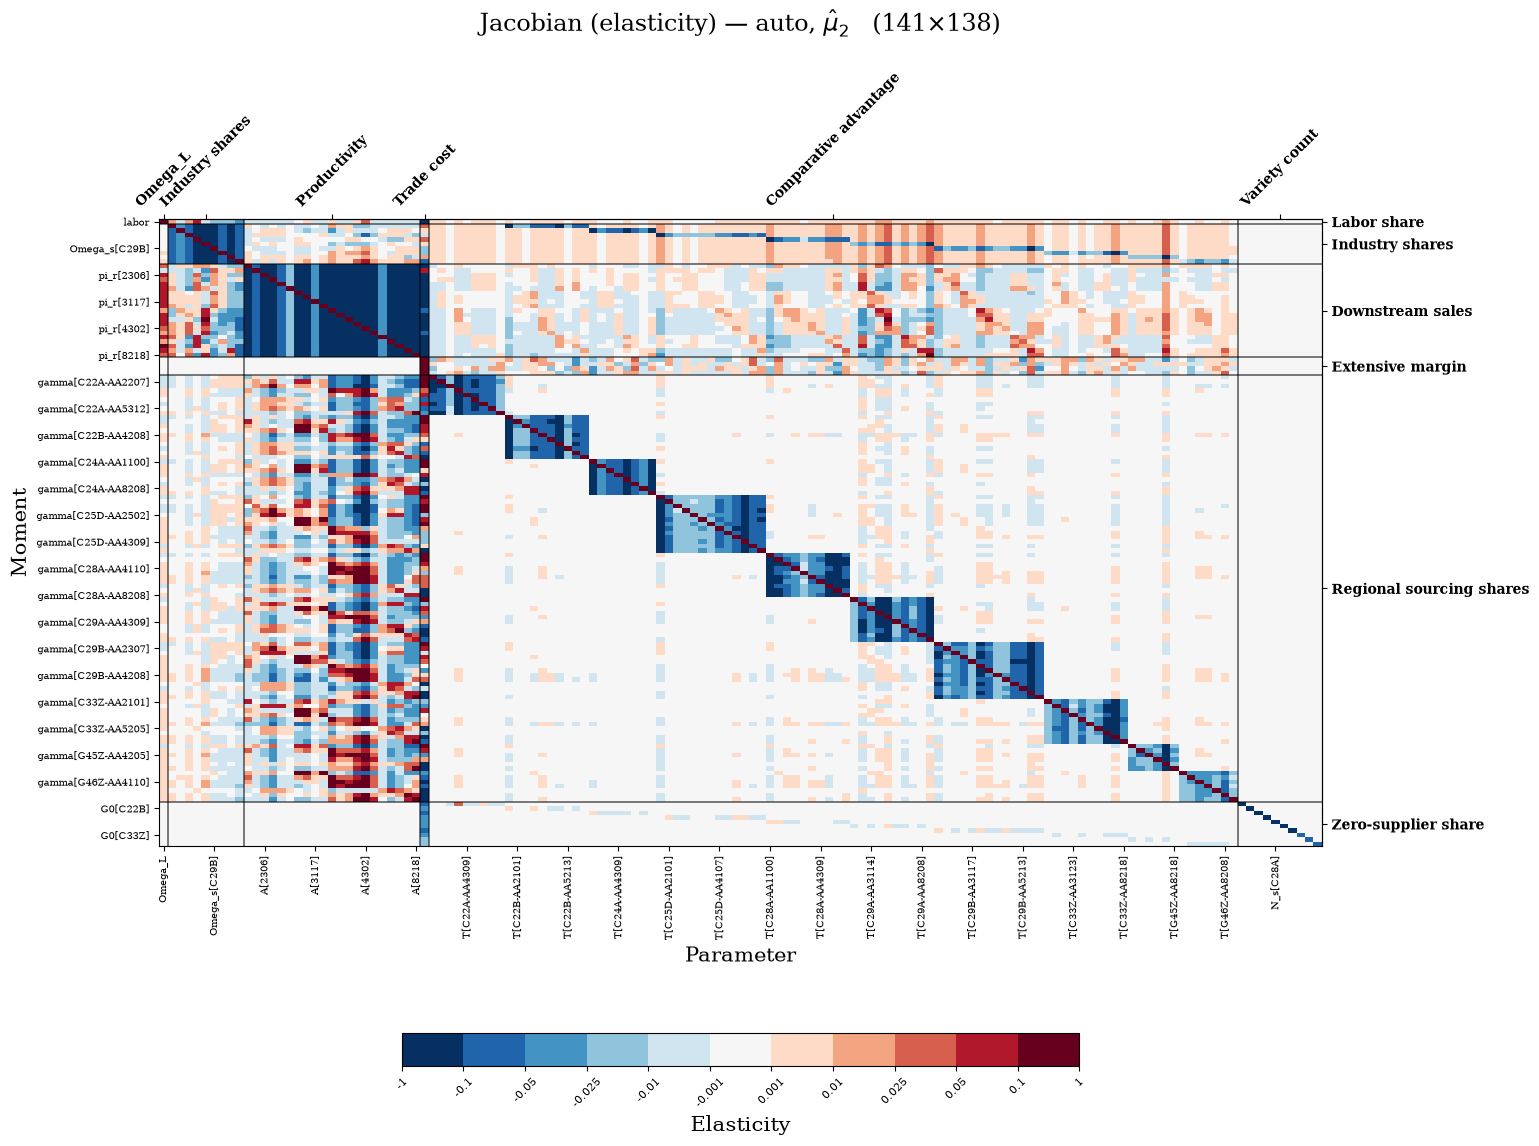

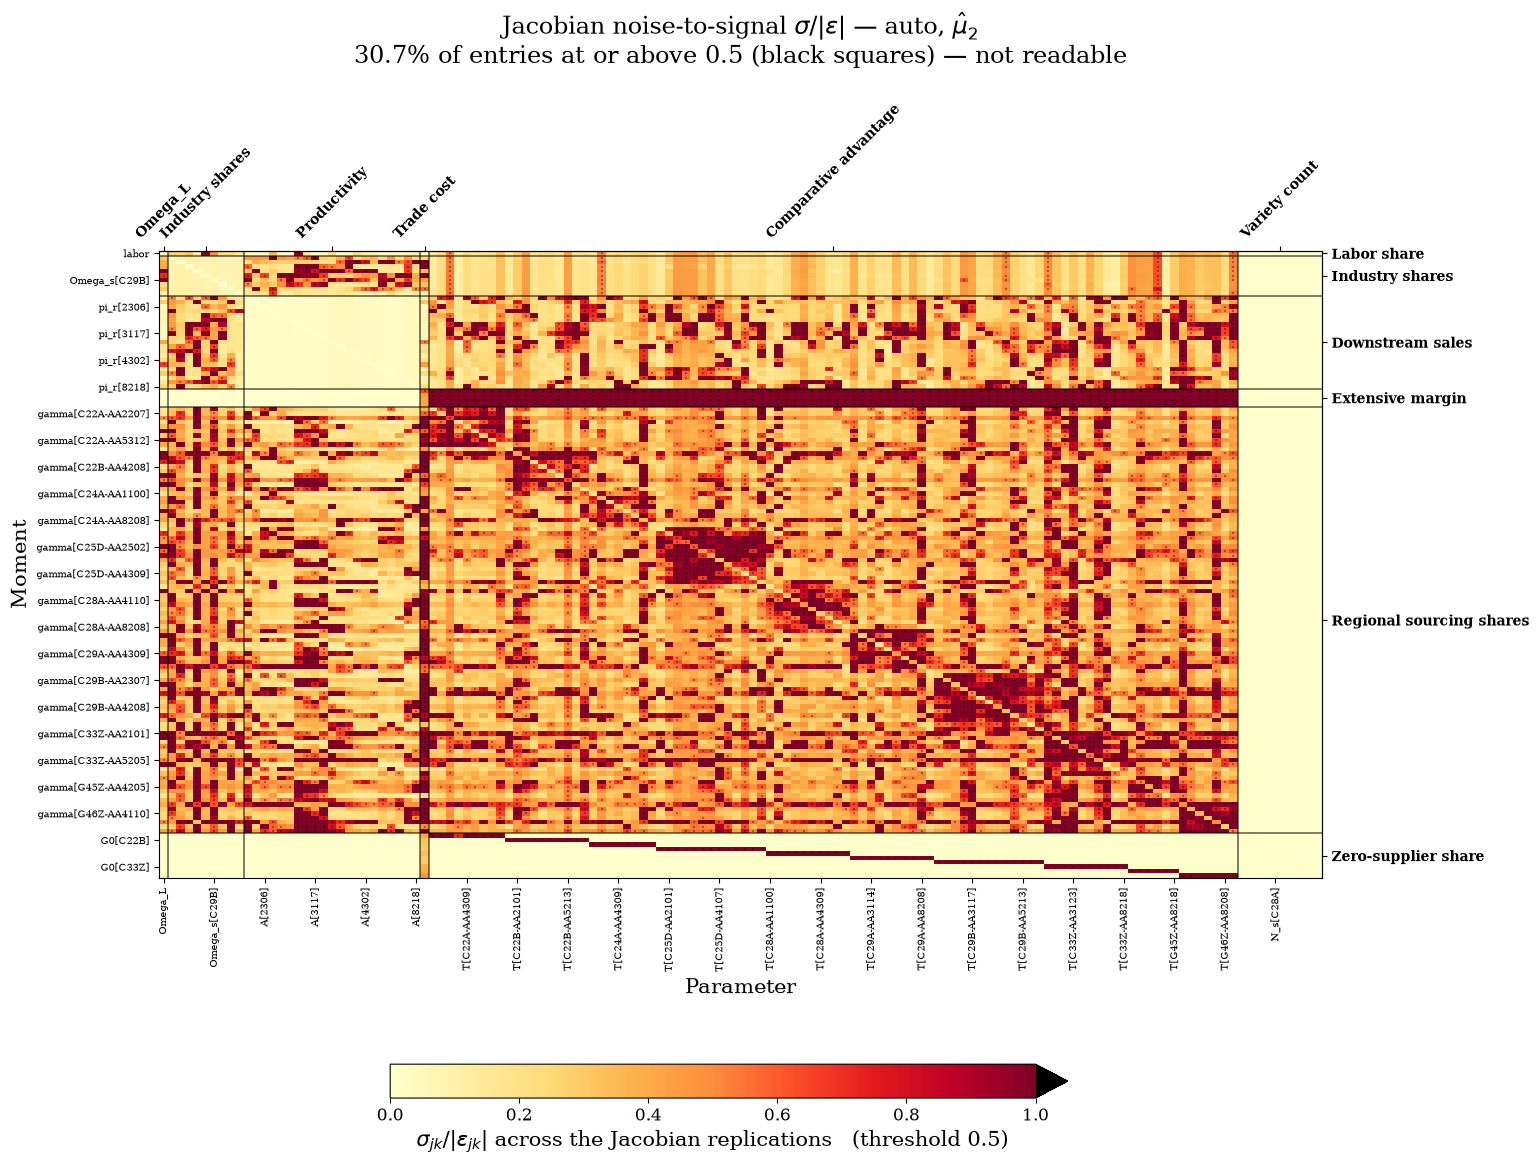

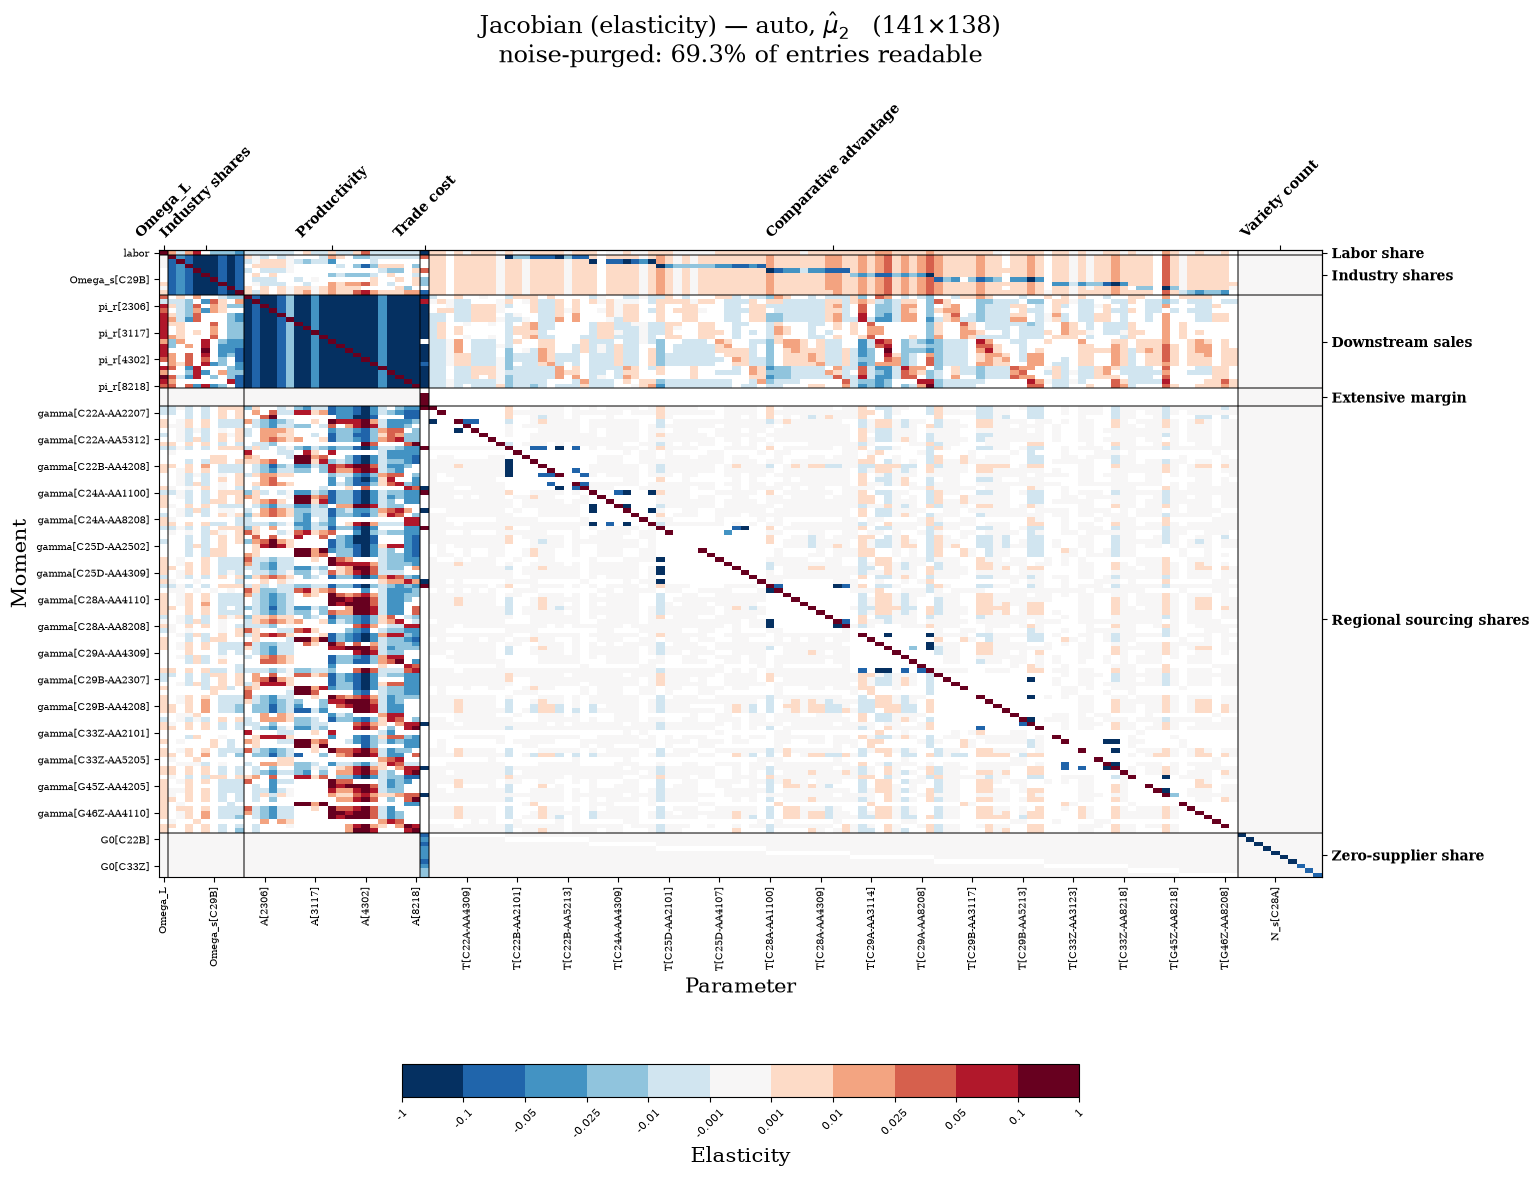

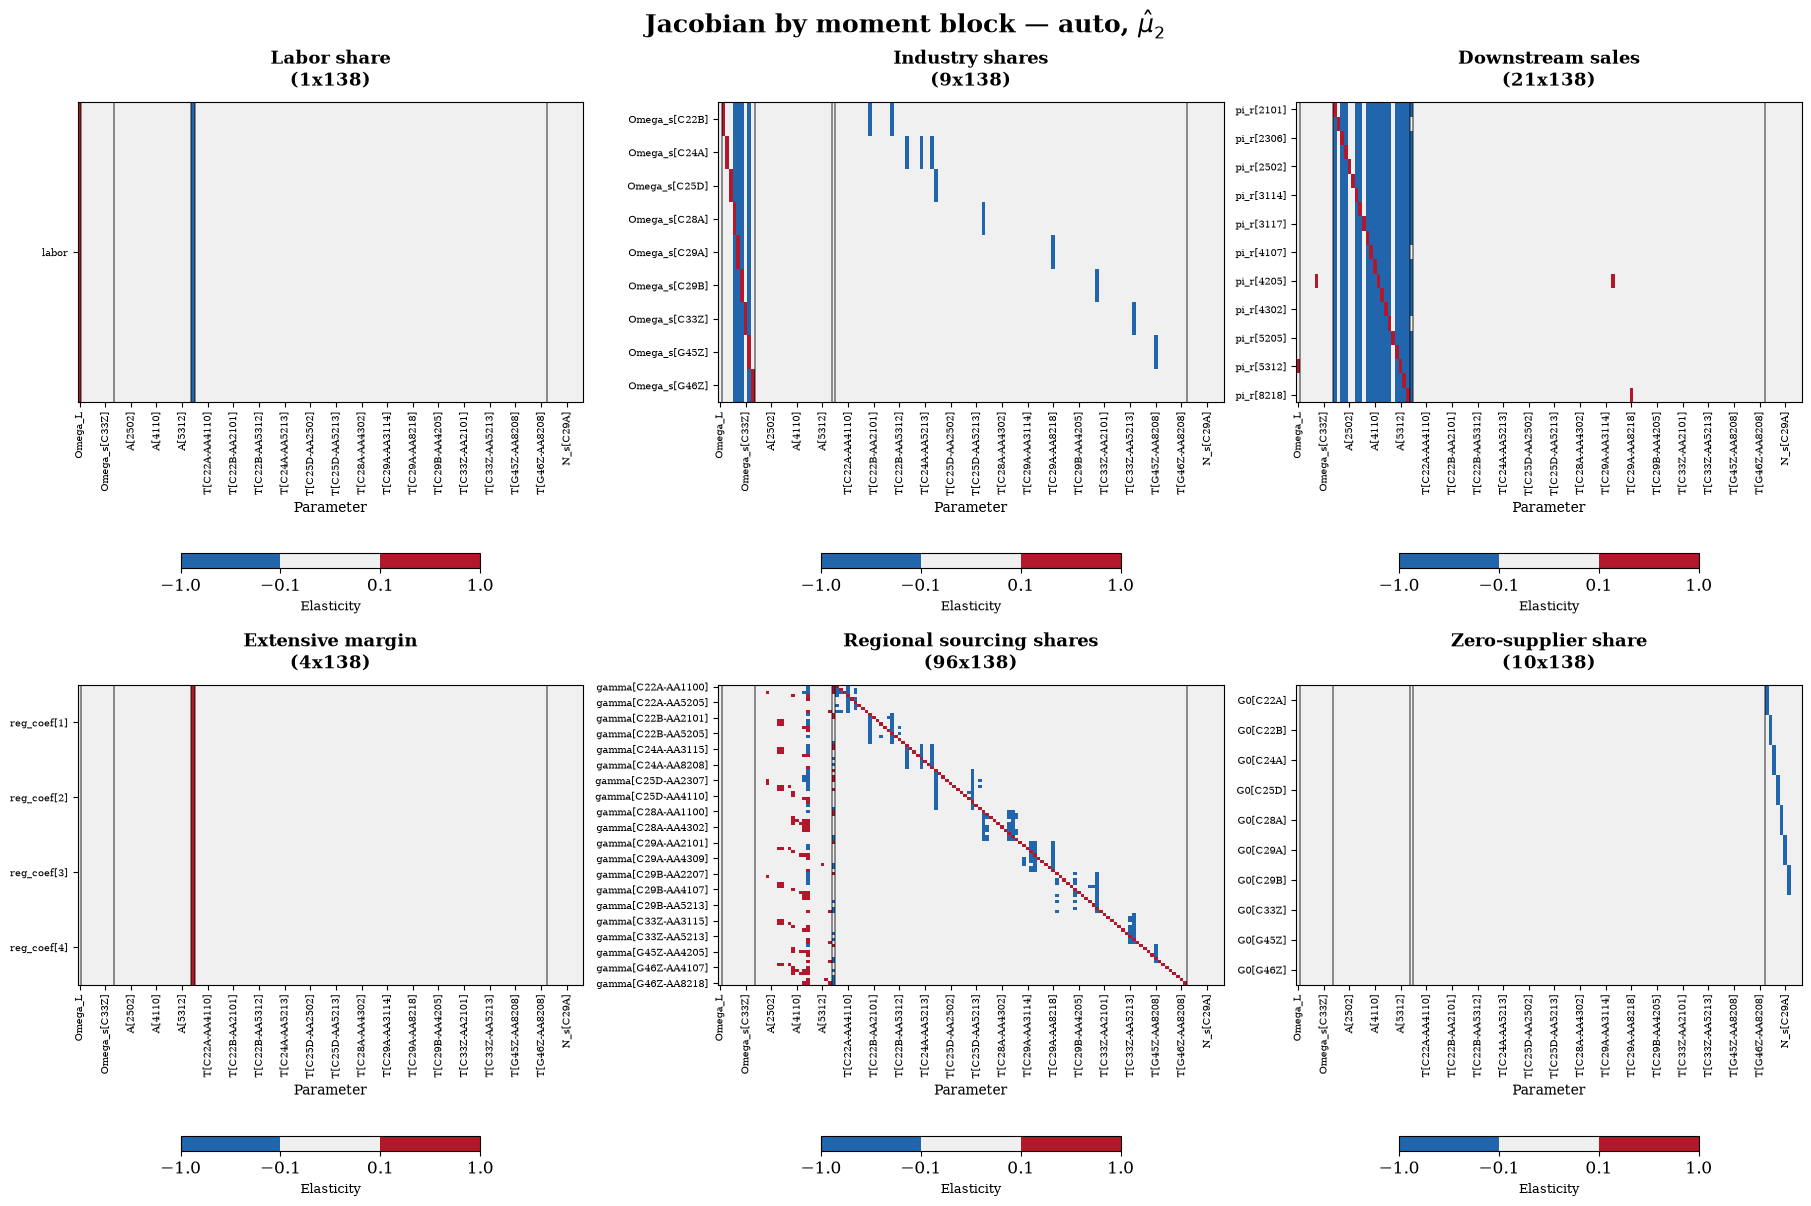

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.850863        0.019183     0.008162   0.496615   
Industry shares           0.000936        0.194207     0.005525   0.020718   
Downstream sales          0.050058        0.020346     0.655007   0.337642   
Extensive margin          0.000000        0.000000     0.000000   1.007340   
Regional sourcing shares  0.003350        0.001895     0.031987   0.081453   
Zero-supplier share       0.000000        0.000000     0.000000   0.047259   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.002888      0.000000  0.850863   
Industry shares                       0.010077      0.000000  0.002860   
Downstream sales                      0.005671      0.000000  0.104109   
Extensive margin                      0.008475      0.000000  0.000000   
Regional sourcing shares              0.017223      0.000000  0.009342   
Zero-supplier share                   0.000272      0.014944  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.060631     0.048392   0.496615   
Industry shares                 0.970375     0.059456   0.072624   
Downstream sales                0.148678     8.999605   0.707852   
Extensive margin                0.000000     0.000000   1.075402   
Regional sourcing shares        0.013277     0.720860   0.266545   
Zero-supplier share             0.000000     0.000000   0.084504   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.022065      0.000000       1.000000   
Industry shares                       0.308449      0.000000       0.666667   
Downstream sales                      0.152740      0.000000       0.952381   
Extensive margin                      0.049996      0.000000       1.000000   
Regional sourcing shares              1.391970      0.000000       0.677083   
Zero-supplier share                   0.028440      0.258579       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.888889     0.952381   1.000000   
Industry shares                 1.000000     0.608466   0.555556   
Downstream sales                0.629630     1.000000   0.952381   
Extensive margin                1.000000     1.000000   0.750000   
Regional sourcing shares        0.547454     0.707837   0.114583   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.937500           1.0  
Industry shares                       0.942130           1.0  
Downstream sales                      0.689484           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.614583           1.0  
Zero-supplier share                   0.900000           1.0

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  10 variety-count columns in the Jacobian


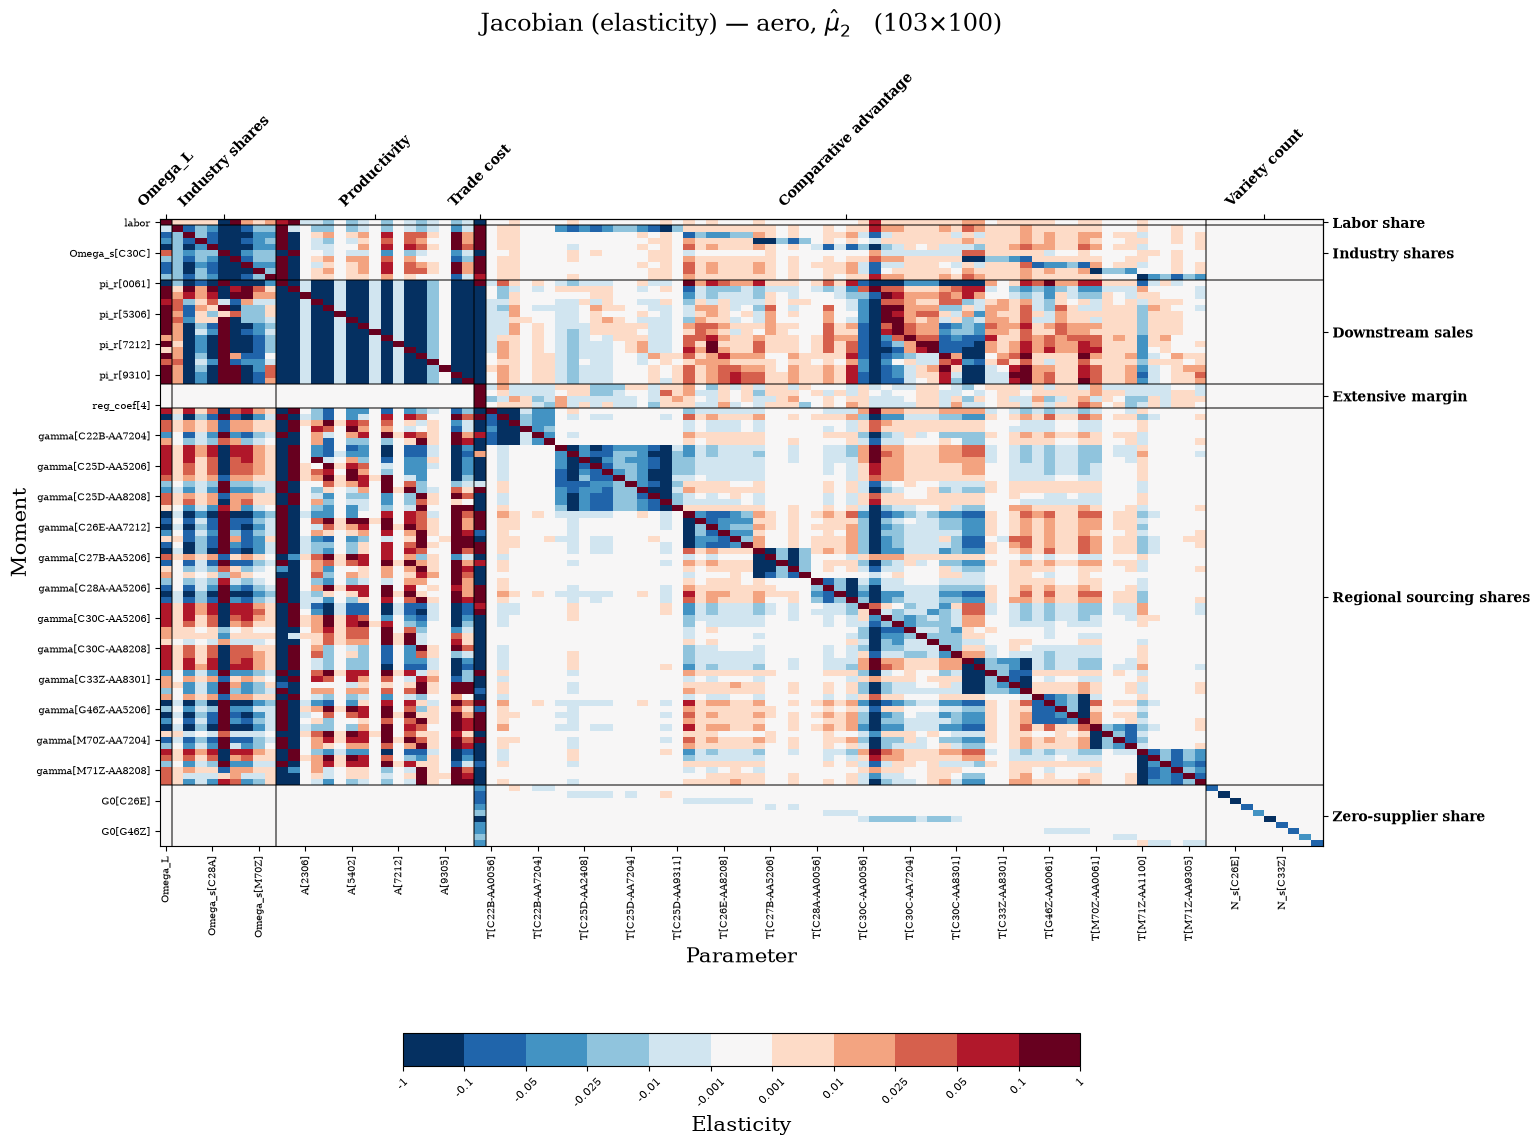

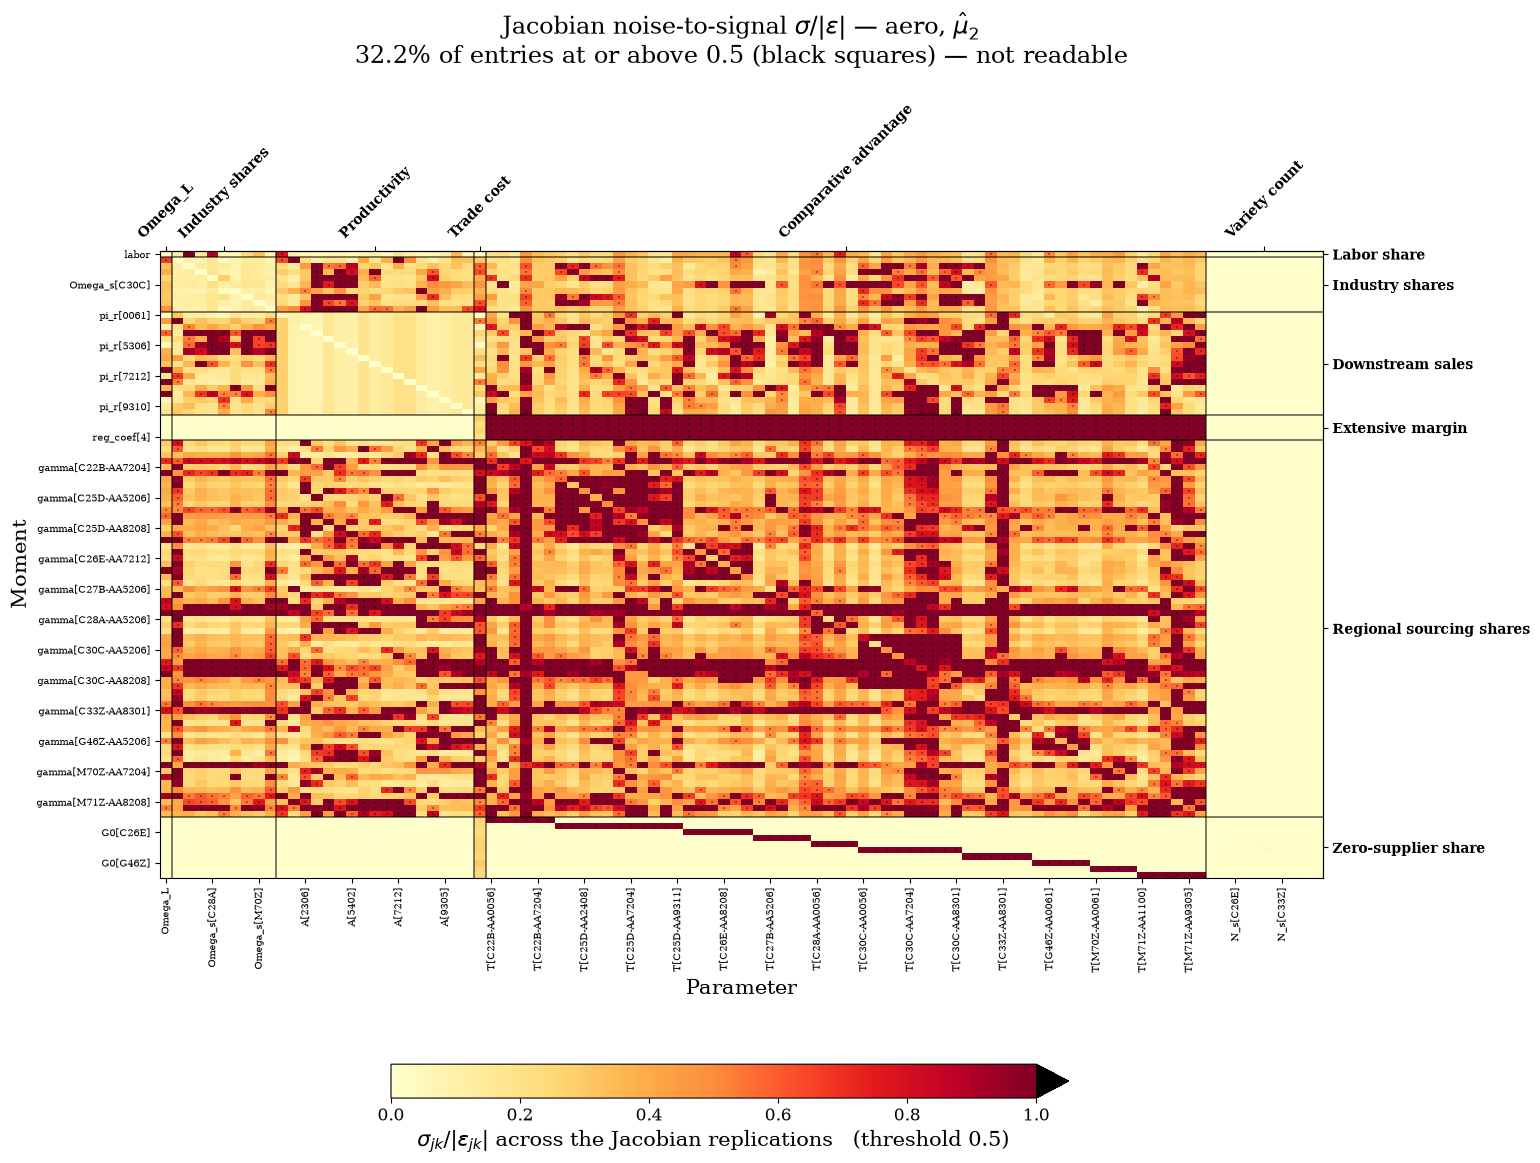

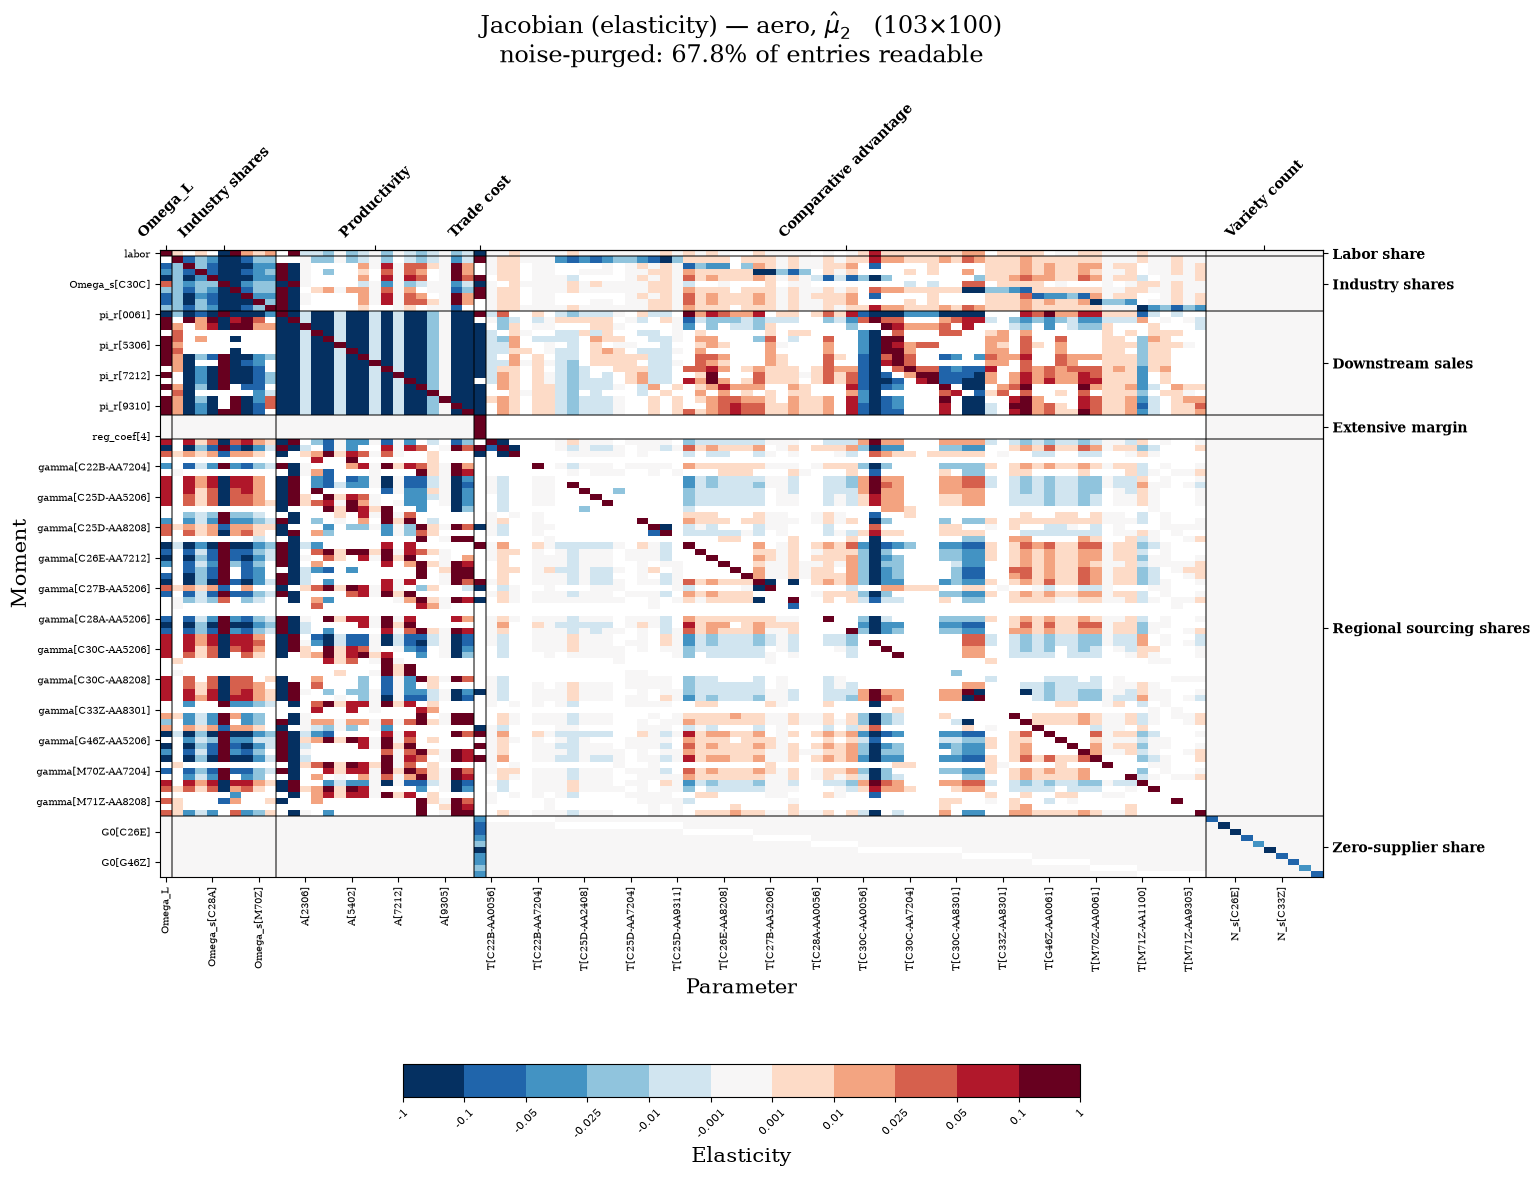

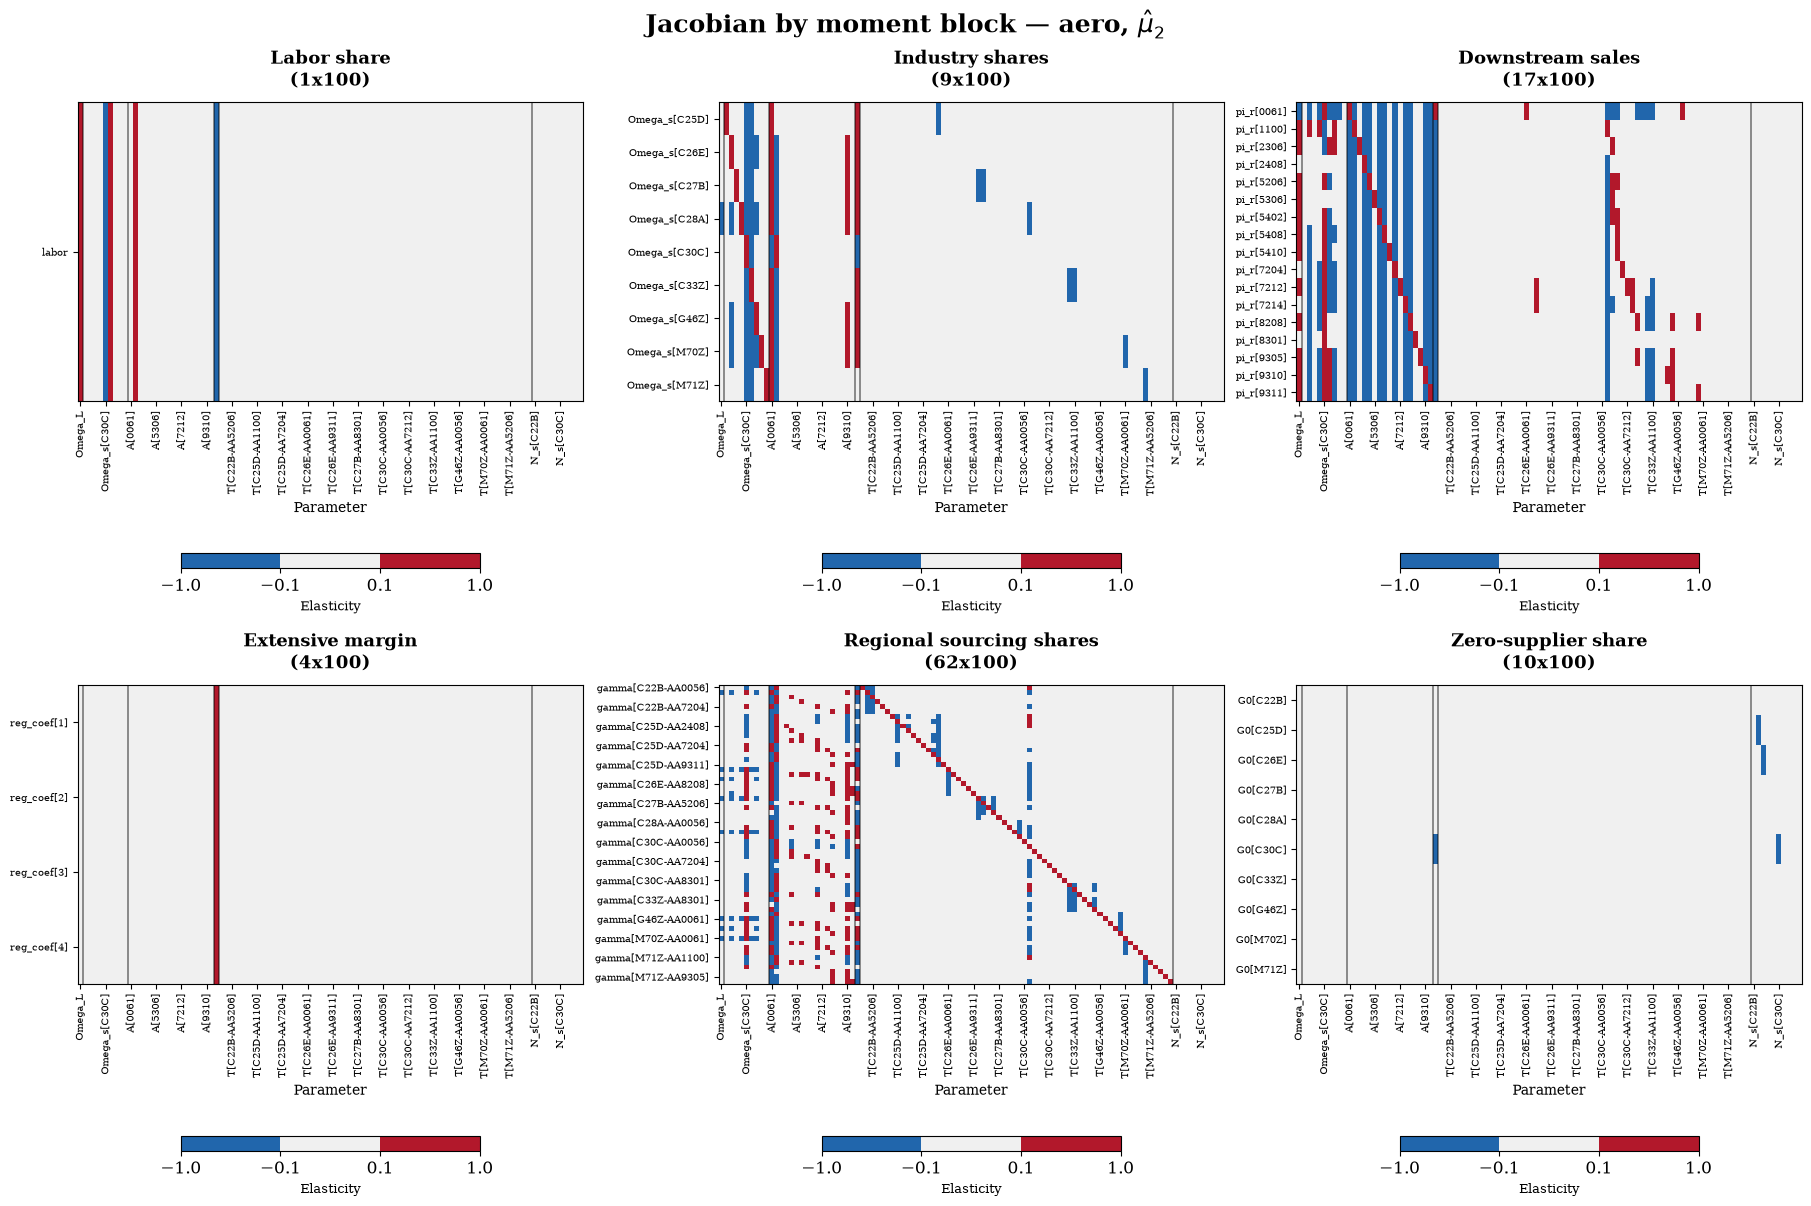

mean_abs                                          \
param_block                Omega_L Industry shares Productivity Trade cost   
moment_block                                                                 
Labor share               0.907045        0.038829     0.041226   0.969213   
Industry shares           0.046887        0.187636     0.116710   0.243268   
Downstream sales          0.252323        0.138227     1.681982   2.103455   
Extensive margin          0.000000        0.000000     0.000000   1.051031   
Regional sourcing shares  0.056656        0.049488     0.189176   0.374187   
Zero-supplier share       0.000000        0.000000     0.000000   0.052855   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.002754      0.000000  0.907045   
Industry shares                       0.009539      0.000000  0.104433   
Downstream sales                      0.029481      0.000000  0.819458   
Extensive margin                      0.005057      0.000000  0.000000   
Regional sourcing shares              0.028144      0.000000  0.222457   
Zero-supplier share                   0.000315      0.008978  0.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.178543     0.531940   0.969213   
Industry shares                 0.982070     2.029217   0.592235   
Downstream sales                2.113967    16.067390   6.483018   
Extensive margin                0.000000     0.000000   1.069508   
Regional sourcing shares        0.757642     4.040662   1.612169   
Zero-supplier share             0.000000     0.000000   0.158541   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.053806      0.000000       1.000000   
Industry shares                       0.282235      0.000000       0.888889   
Downstream sales                      1.009496      0.000000       0.764706   
Extensive margin                      0.034560      0.000000       1.000000   
Regional sourcing shares              1.187732      0.000000       0.693548   
Zero-supplier share                   0.019749      0.209421       1.000000   

                                                                  \
param_block              Industry shares Productivity Trade cost   
moment_block                                                       
Labor share                     0.777778     0.941176   1.000000   
Industry shares                 1.000000     0.725490   0.555556   
Downstream sales                0.686275     1.000000   0.882353   
Extensive margin                1.000000     1.000000   1.000000   
Regional sourcing shares        0.661290     0.609108   0.193548   
Zero-supplier share             1.000000     1.000000   1.000000   

                                                              
param_block              Comparative advantage Variety count  
moment_block                                                  
Labor share                           0.903226           1.0  
Industry shares                       0.808244           1.0  
Downstream sales                      0.664137           1.0  
Extensive margin                      0.000000           1.0  
Regional sourcing shares              0.540583           1.0  
Zero-supplier share                   0.900000           1.0

In [97]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"{data['n_N_cols']} variety-count columns in the Jacobian")

    # the triptych: as is, the noise-to-signal map, and the purged matrix
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))


## Variance-covariance of the moments


Three matrices, all written by Step 2:

* $\Sigma_{data}$ — the bootstrap covariance of the **empirical** moments: how precisely
  the targets are measured;
* $\Sigma_{sim}$ — the covariance across $K$ re-simulations at $\hat\theta_1$: how much
  of the moment vector is Monte-Carlo noise from the simulator;
* $\Omega = \Sigma_{data} + \Sigma_{sim}$ — what the estimator actually weighted with,
  $W = \Omega^{-1}$.

Two views of each. The **covariance** panels are on a common diverging scale, so the
relative magnitude of the three is visible — which is the point, since
$\mathrm{tr}(\Sigma_{sim})/\mathrm{tr}(\Sigma_{data})$ is the share of the weighting that
is simulation rather than data, and the dial for it is `--n_rho_inf`. The **correlation**
panels rescale each matrix by its own diagonal, which removes that magnitude and leaves
the dependence structure: whether the sampling error of the sourcing shares is correlated
across areas, whether the simulation noise is (it is, through the shared draws), and
whether $\Omega$ inherits its correlation from the data or from the simulator.


In [98]:
# The three moment covariance matrices, and the correlations they imply.

def _gb_edges(data):
    """
    Block edges of the inference subsystem and their names.

    The three blocks are stacked in a fixed order — extensive-margin coefficients,
    sourcing shares, zero-supplier shares — on both axes of every Sigma / Omega / W on
    disk. That order is the "beta, gamma, G" ordering invariant of CLAUDE.md.
    """
    n_beta = data["n_coef"]
    n_gam = int(np.asarray(data["moment_block_sizes"])[4])
    sizes = [n_beta, n_gam] + ([data["S"]] if data["granular"] else [])
    names = ["reg_coef", "gamma", "G0"][:len(sizes)]
    return np.cumsum([0] + sizes), names


def _cov_panel(ax, M, data, title, mode="cov", pct=95):
    """One matrix panel with the block grid drawn on; `mode` is "cov" or "corr"."""
    from matplotlib.colors import TwoSlopeNorm
    edges, names = _gb_edges(data)
    if mode == "corr":
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        M = M / np.outer(d, d)
        im = ax.matshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    else:
        v = np.percentile(np.abs(M), pct)
        v = v if v > 0 else (np.abs(M).max() or 1.0)
        im = ax.matshow(M, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v))
    for e in edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
        ax.axvline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
    ticks = (edges[:-1] + edges[1:]) / 2 - 0.5
    ax.set_xticks(ticks)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_yticks(ticks)
    ax.set_yticklabels(names, fontsize=9, rotation=90, va="center")
    ax.set_title(title, pad=14)
    return im


def _cov_matrices(data):
    return [("$\\Sigma_{sim}$ (simulation noise)", data.get("Sigma_sim")),
            ("$\\Sigma_{data}$ (bootstrap)", data.get("Sigma_data")),
            ("$\\Omega = \\Sigma_{data} + \\Sigma_{sim}$", data.get("Omega"))]


def plot_variance_covariance(data, figsize=(16, 5.5), pct=95, save_to=None):
    """Sigma_sim, Sigma_data and Omega side by side, each on its own diverging scale."""
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/ — "
                                "build_step3_weight_matrix writes them in Step 2.")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="cov", pct=pct)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment variance-covariance — {data['industry']} "
                 "(extensive margin, sourcing shares, zero-supplier shares)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_moment_correlation(data, figsize=(16, 5.5), save_to=None):
    """
    The same three matrices as CORRELATIONS, on a common [-1, 1] scale.

    Rescaling by the diagonal removes the magnitude — which the covariance figure is
    there to show — and leaves the dependence structure, so the three are comparable:
    whether the bootstrap error of the sourcing shares is correlated across areas,
    whether the simulator's noise is (it is, through the shared draws), and which of the
    two Omega inherits its structure from.
    """
    mats = _cov_matrices(data)
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/")
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        im = _cov_panel(ax, M, data, title, mode="corr")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Moment CORRELATION — {data['industry']} "
                 "(same three matrices, rescaled by their own diagonal)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def variance_covariance_summary(data):
    """
    How much of the weighting is simulation noise, and how well conditioned is Omega?

    `trace(Sigma_sim)/trace(Sigma_data)` is the share of total moment variance that comes
    from the simulation rather than the data — raise `--n_rho_inf` if it is not small.
    `mean_abs_offdiag_corr` is the average absolute off-diagonal correlation, the same
    thing the correlation figure shows, as one number per matrix. The condition numbers
    say whether inverting Omega to build W is safe.
    """
    out = {}
    for name in ("Sigma_data", "Sigma_sim", "Omega"):
        M = data.get(name)
        if M is None:
            continue
        ev = np.linalg.eigvalsh((M + M.T) / 2)
        d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
        C = M / np.outer(d, d)
        off = ~np.eye(C.shape[0], dtype=bool)
        out[name] = {"trace": float(np.trace(M)),
                     "eig_min": float(ev.min()), "eig_max": float(ev.max()),
                     "cond": float(ev.max() / ev.min()) if ev.min() > 0 else np.inf,
                     "mean_abs_offdiag_corr": float(np.abs(C[off]).mean())}
    if "Sigma_sim" in out and "Sigma_data" in out and out["Sigma_data"]["trace"] != 0:
        out["Sigma_sim"]["share_of_data_trace"] = \
            out["Sigma_sim"]["trace"] / out["Sigma_data"]["trace"]
    return pd.DataFrame(out).T


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


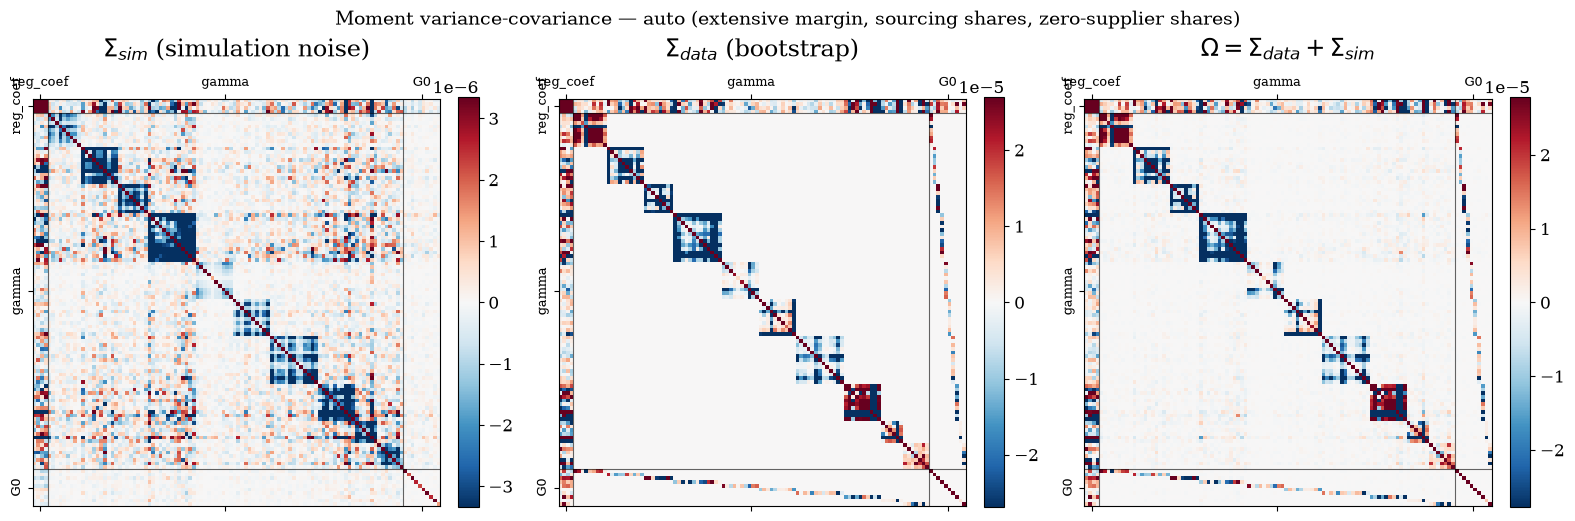

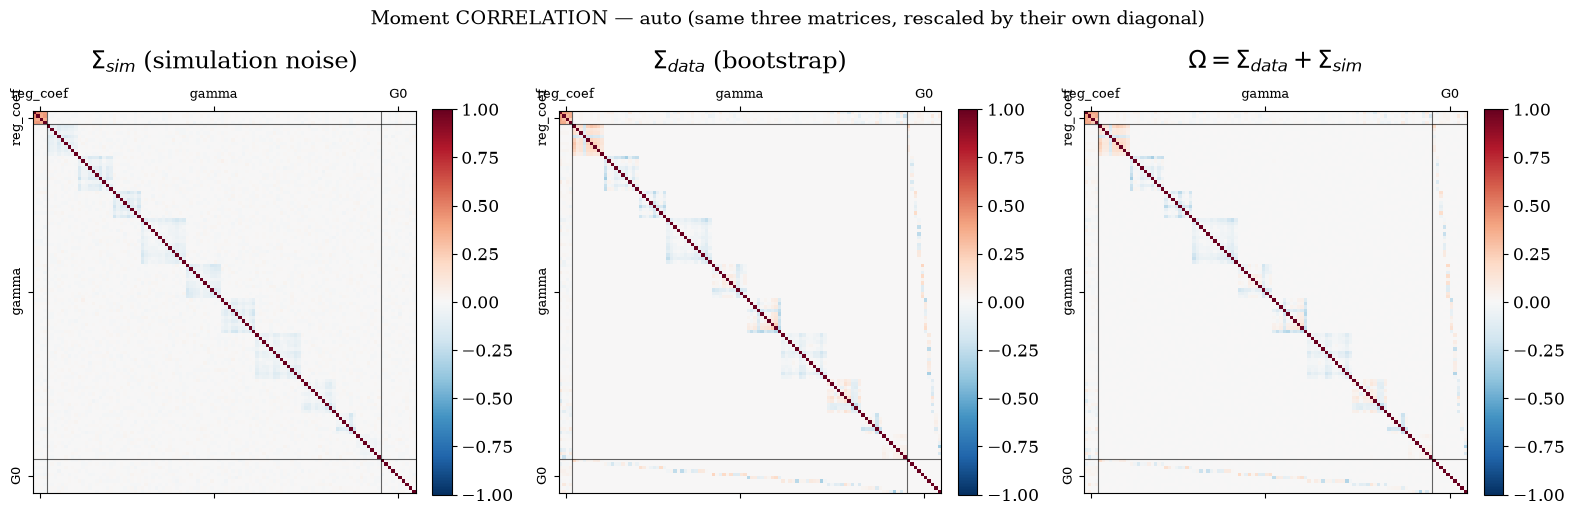

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.104737,0.000004,0.016072,4364.240277,0.008364,NaN
Sigma_sim,0.010705,0.000001,0.001025,897.200289,0.012564,0.102207
Omega,0.115442,0.000006,0.017066,2675.166214,0.008446,NaN


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


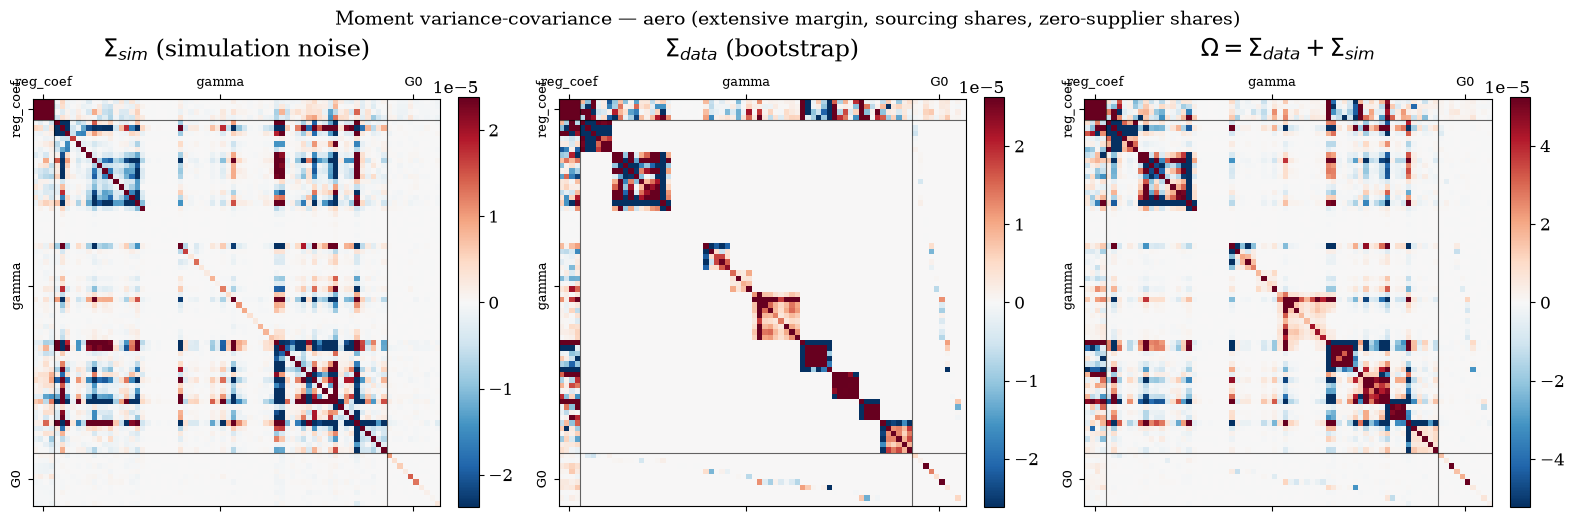

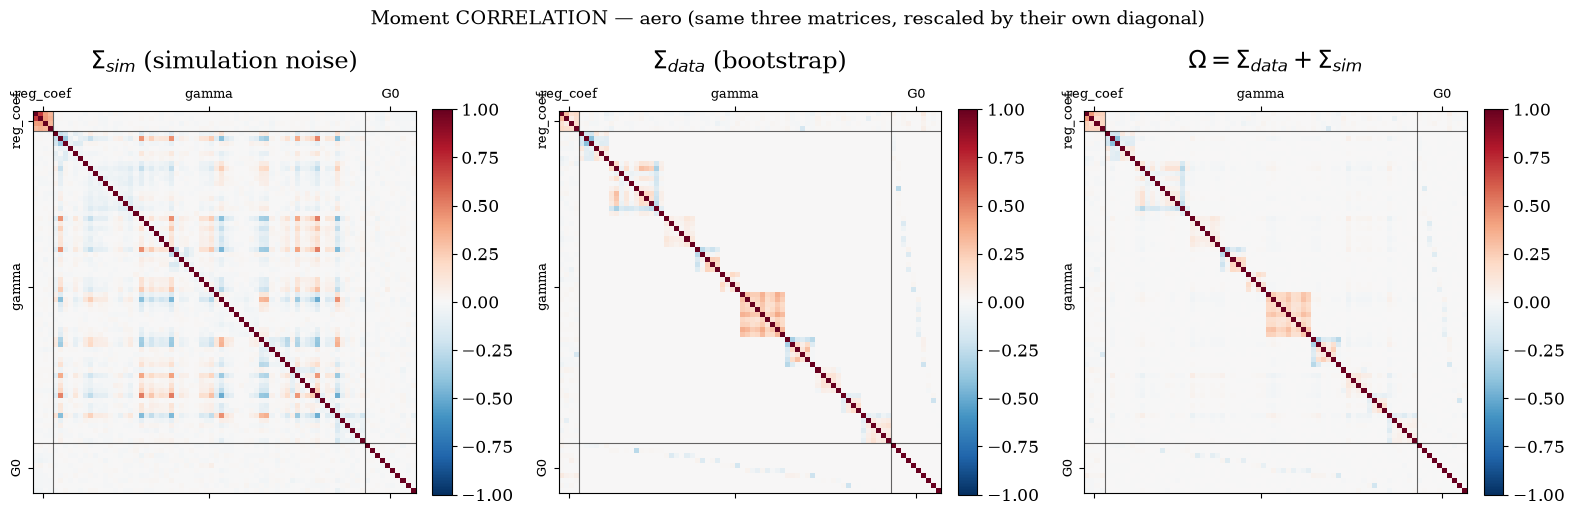

,trace,eig_min,eig_max,cond,mean_abs_offdiag_corr,share_of_data_trace
Sigma_data,0.113914,1.109410e-31,0.022176,1.998878e+29,0.010890,NaN
Sigma_sim,0.012092,1.798901e-09,0.002164,1.203189e+06,0.032292,0.10615
Omega,0.126006,1.038995e-08,0.023034,2.216994e+06,0.012403,NaN


In [99]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(
        data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))


## Identification / sensitivity

A sensitivity analysis fixes every parameter, moves one of them above and below its
estimate, and checks that the moments respond smoothly and in the direction the design
predicts. The elasticity Jacobian *is* that experiment, linearised at the estimate:
$\varepsilon_{jk} = \partial \log m_j / \partial \log \theta_k$ is the local slope of
moment $j$ against parameter $k$. With ten sectors, the attraction areas, the $T$ block
and the variety counts there are far too many parameters to draw a curve each, so the
matrix is drawn instead and everything too small — or too noisy — is blanked out.

Two thresholds, and they answer different questions:

* $|\varepsilon| \geq$ `IDENT_THRESHOLD` (0.01): a 1% move in the parameter shifts the
  moment by at least 0.01%. **Is there a channel?**
* $\sigma/|\varepsilon| <$ `NOISE_MAX` (0.5): the elasticity is estimated precisely
  enough relative to its own size. **Can we see it?** An entry that fails this is not
  evidence of a weak channel; it is evidence of nothing at all, and the summary counts it
  separately rather than pooling it with the structural zeros.

What the figures are meant to show: the three channels are close to orthogonal *by
construction*. $\alpha$ is read from a **within**-area distance gradient that comparative
advantage cannot touch, since comparative advantage is constant within an area; $T_{as}$
is read from **across**-area value shares; $N_s$ is read from the **level** of the
empty-region share, which the sector $\times$ nearest-downstream fixed effect strips out
of the $\alpha$ regression. So the expected picture is near-block-diagonal on the
(Trade cost, Comparative advantage, Variety count) $\times$ (Extensive margin, Regional
sourcing shares, Zero-supplier share) corner — and in the $N_s$ columns *exact* zeros
rather than merely small numbers.


In [100]:
# Identification / sensitivity — the elasticity Jacobian read as the experiment
# "move one parameter, watch the moments", with two thresholds: is there a channel
# (IDENT_THRESHOLD), and is it measured well enough to see (NOISE_MAX).
#
# The variety counts N_s are part of the parameter axis: the Julia side appends
# dm/dN_s to the saved Jacobian, so no re-attachment is done here.

IDENT_THRESHOLD = 0.01


def _blocks_2d(data, M):
    """M split into (moment block x parameter block) sub-matrices."""
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    return {(i, j): M[m_edges[i]:m_edges[i + 1], p_edges[j]:p_edges[j + 1]]
            for i in range(len(data["moment_block_names"]))
            for j in range(len(data["param_block_names"]))}


def _readable(data, kind="elasticity", noise_max=NOISE_MAX):
    """Boolean matrix: entries whose elasticity is precise enough to be interpreted."""
    if noise_max is None:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)
    try:
        return ~jacobian_noise_mask(data, kind=kind, noise_max=noise_max)
    except FileNotFoundError:
        return np.ones_like(np.asarray(jacobian_matrix(data, kind), float), dtype=bool)


def identification_summary(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                           noise_max=NOISE_MAX):
    """
    Per (moment block x parameter block), four numbers that answer four questions:

      share_above       is there a channel?  share of entries with |elasticity| >= threshold
      share_readable    can it be seen?      share whose sigma/|elasticity| < noise_max
      share_live        both at once         above the threshold AND readable
      share_exact_zero  is it absent by construction?  share of entries exactly 0

    The last two are the pair worth reading together: an exact zero is the model saying
    the channel does not exist (the N_s columns outside block 6, asserted in Julia),
    whereas an unreadable entry says nothing at all.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    rows = []
    for (i, j), sub in _blocks_2d(data, E).items():
        sub_ok = _blocks_2d(data, ok)[(i, j)]
        rows.append({
            "moment_block": data["moment_block_names"][i],
            "param_block": data["param_block_names"][j],
            "share_above": float((sub >= threshold).mean()) if sub.size else np.nan,
            "share_readable": float(sub_ok.mean()) if sub.size else np.nan,
            "share_live": float(((sub >= threshold) & sub_ok).mean()) if sub.size else np.nan,
            "max_abs": float(sub.max()) if sub.size else np.nan,
            "mean_abs": float(sub.mean()) if sub.size else np.nan,
            "share_exact_zero": float((sub == 0).mean()) if sub.size else np.nan,
        })
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


def plot_identification_map(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                            noise_max=NOISE_MAX, figsize=(9, 6), save_to=None):
    """
    One cell per (moment block x parameter block), coloured by the share of entries that
    are BOTH above the threshold and readable, annotated with that share, the block's
    max |elasticity|, and — when it is not 100% — the share of the block that is readable
    at all. A near-diagonal pattern down the (Trade cost, Comparative advantage, Variety
    count) columns is the identification claim, read off directly.
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    n_m, n_p = len(m_names), len(p_names)

    def _grid(fn):
        return np.array([[fn(blocks[(i, j)], blocks_ok[(i, j)])
                          if blocks[(i, j)].size else np.nan
                          for j in range(n_p)] for i in range(n_m)])

    live = _grid(lambda s, o: ((s >= threshold) & o).mean())
    mx = _grid(lambda s, o: s.max())
    read = _grid(lambda s, o: o.mean())

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(live, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(n_m):
        for j in range(n_p):
            if not np.isfinite(live[i, j]):
                continue
            txt = f"{100 * live[i, j]:.0f}%\nmax {mx[i, j]:.3g}"
            if read[i, j] < 0.999:
                txt += f"\n({100 * read[i, j]:.0f}% readable)"
            ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                    color="white" if live[i, j] > 0.55 else "black")
    ax.set_xticks(range(n_p))
    ax.set_xticklabels(p_names, rotation=30, ha="left", fontsize=10)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks(range(n_m))
    ax.set_yticklabels(m_names, fontsize=10)
    ax.set_xlabel("Parameter block")
    ax.set_ylabel("Moment block")
    ax.set_title(f"Identification map — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\nshare of $|\\varepsilon| \\geq {threshold:g}$ AND "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$", pad=52)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("share of entries that are both large and measured")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_thresholded(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, figsize=(15, 11), save_to=None):
    """
    The whole elasticity Jacobian with two kinds of entry removed: those below the
    threshold (grey — a channel too small to matter) and those drowned in simulation
    noise (white — nothing was measured). What is left is the set of channels through
    which a parameter can actually be identified, on a symmetric log colour scale so
    three orders of magnitude of live channel stay distinguishable.
    """
    from matplotlib.colors import SymLogNorm

    E = np.asarray(jacobian_matrix(data, kind), float)
    A = np.abs(E)
    ok = _readable(data, kind, noise_max)
    vmax = A[ok].max() if ok.any() and A[ok].max() > 0 else 1.0

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#f2f2f2")                     # below threshold
    small = np.ma.masked_where(A < threshold, E)
    M = np.ma.masked_where(~ok, small)          # unreadable painted white on top
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor("white")
    im = ax.matshow(M, cmap=cmap, aspect="auto",
                    norm=SymLogNorm(linthresh=threshold, vmin=-vmax, vmax=vmax, base=10))
    # the noise-rejected cells, drawn white over the grey "below threshold" background
    ys, xs = np.where(~ok)
    ax.scatter(xs, ys, s=2.0, marker="s", color="white", linewidths=0)
    _block_grid(ax, data, m_edges, p_edges)
    _axis_labels(ax, data, M.shape)

    kept = float(((A >= threshold) & ok).mean())
    ax.set_title(f"Elasticity Jacobian, $|\\varepsilon| \\geq {threshold:g}$ and "
                 f"$\\sigma/|\\varepsilon| < {noise_max:g}$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   ({100 * kept:.1f}% of {A.size} entries shown)", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22)
    cbar.set_label(r"$\varepsilon = \partial \log m / \partial \log \theta$"
                   "   (symmetric log; grey = below threshold, white = too noisy)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_channel_elasticities(data, param_blocks=("Trade cost", "Comparative advantage",
                                                  "Variety count"),
                              threshold=IDENT_THRESHOLD, kind="elasticity",
                              noise_max=NOISE_MAX, stat="max", figsize=(11, 5),
                              save_to=None):
    """
    One panel per channel: the largest READABLE |elasticity| that channel produces in
    each moment block, on a log axis, with the threshold drawn in.

    This is the identification paragraph in one picture — alpha tall on the extensive
    margin, T tall on the sourcing shares, N_s tall on the zero-supplier share and
    EXACTLY zero (no bar, marked "0") everywhere else. Entries rejected for noise are
    excluded from the reduction, so a bar cannot be produced by a single unmeasurable
    outlier; a block with nothing readable left is marked "n/m".
    """
    E = np.abs(np.asarray(jacobian_matrix(data, kind), float))
    ok = _readable(data, kind, noise_max)
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks, blocks_ok = _blocks_2d(data, E), _blocks_2d(data, ok)
    reduce = {"max": np.max, "mean": np.mean}[stat]
    stat_tex = {"max": r"\max", "mean": r"\mathrm{mean}"}[stat]

    wanted = [p for p in param_blocks if p in p_names]
    missing = [p for p in param_blocks if p not in p_names]
    if missing:
        raise ValueError(f"parameter block(s) {missing} absent — the Jacobian has "
                         f"{p_names}. Under --granular=true the run must have written "
                         "the variety-count columns (compute_jacobian append_N_s).")

    vals, unmeasured = {}, {}
    for p in wanted:
        j = p_names.index(p)
        v, nm = [], []
        for i in range(len(m_names)):
            sub, sub_ok = blocks[(i, j)], blocks_ok[(i, j)]
            if sub.size == 0 or not sub_ok.any():
                v.append(0.0)
                nm.append(sub.size > 0)
            else:
                v.append(float(reduce(sub[sub_ok])))
                nm.append(False)
        vals[p], unmeasured[p] = np.array(v), np.array(nm)

    pos = np.concatenate([v[v > 0] for v in vals.values()] or [np.array([threshold])])
    bottom = (pos.min() / 4) if pos.size else threshold / 10

    fig, axes = plt.subplots(1, len(wanted), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(m_names))
    for ax, pname in zip(axes, wanted):
        v_p, nm_p = vals[pname], unmeasured[pname]
        ax.bar(x, v_p, color=[sim_color if v >= threshold else "0.75" for v in v_p])
        ax.set_yscale("log")
        ax.set_ylim(bottom=bottom)
        ax.axhline(threshold, color=reference_color, linestyle="--", linewidth=1.2)
        for i, (v, nm) in enumerate(zip(v_p, nm_p)):
            if v == 0:
                ax.text(i, bottom * 1.35, "n/m" if nm else "0", ha="center", va="bottom",
                        fontsize=9, color=reference_color, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(m_names, rotation=45, ha="right", fontsize=9)
        ax.set_title(pname, fontsize=13, fontweight="bold")
        _despine(ax)
    axes[0].set_ylabel(rf"${stat_tex}_{{j,k}} |\varepsilon_{{jk}}|$ in block (readable only)")
    fig.suptitle(f"Where each channel acts — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   (dashed: threshold {threshold:g}; \"0\" = exactly zero, "
                 "\"n/m\" = nothing measured)", fontsize=13)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


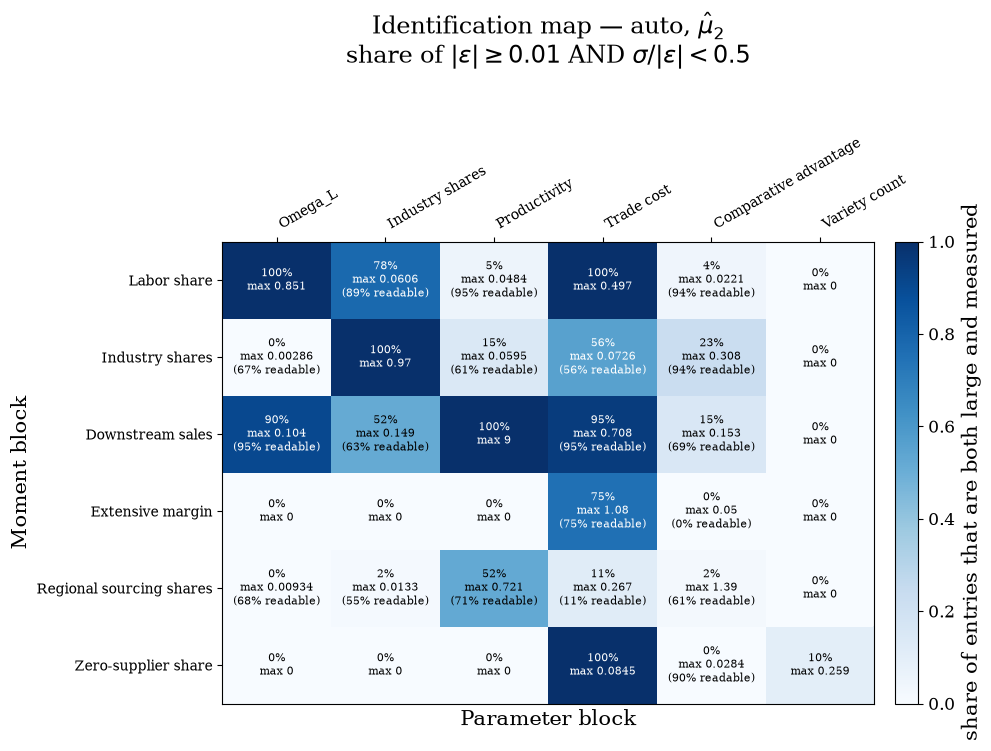

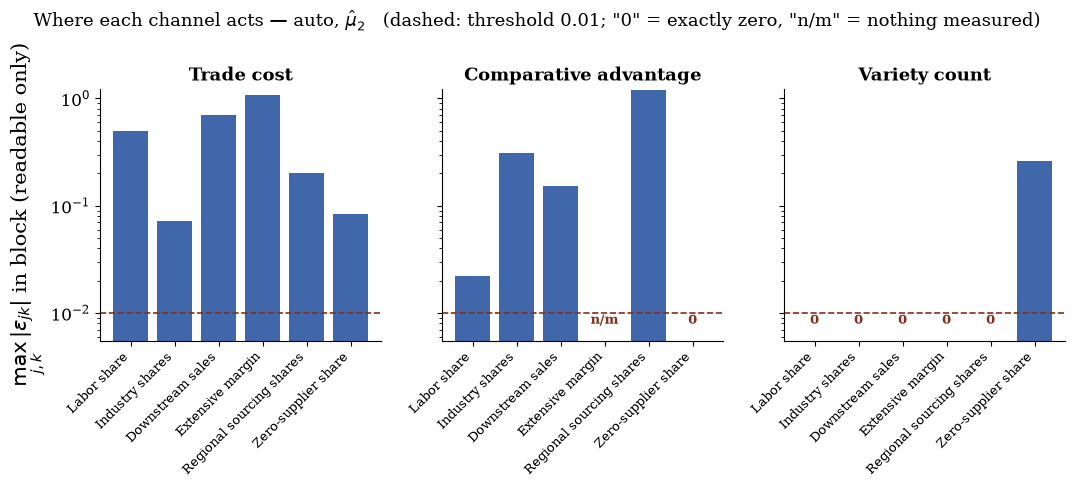

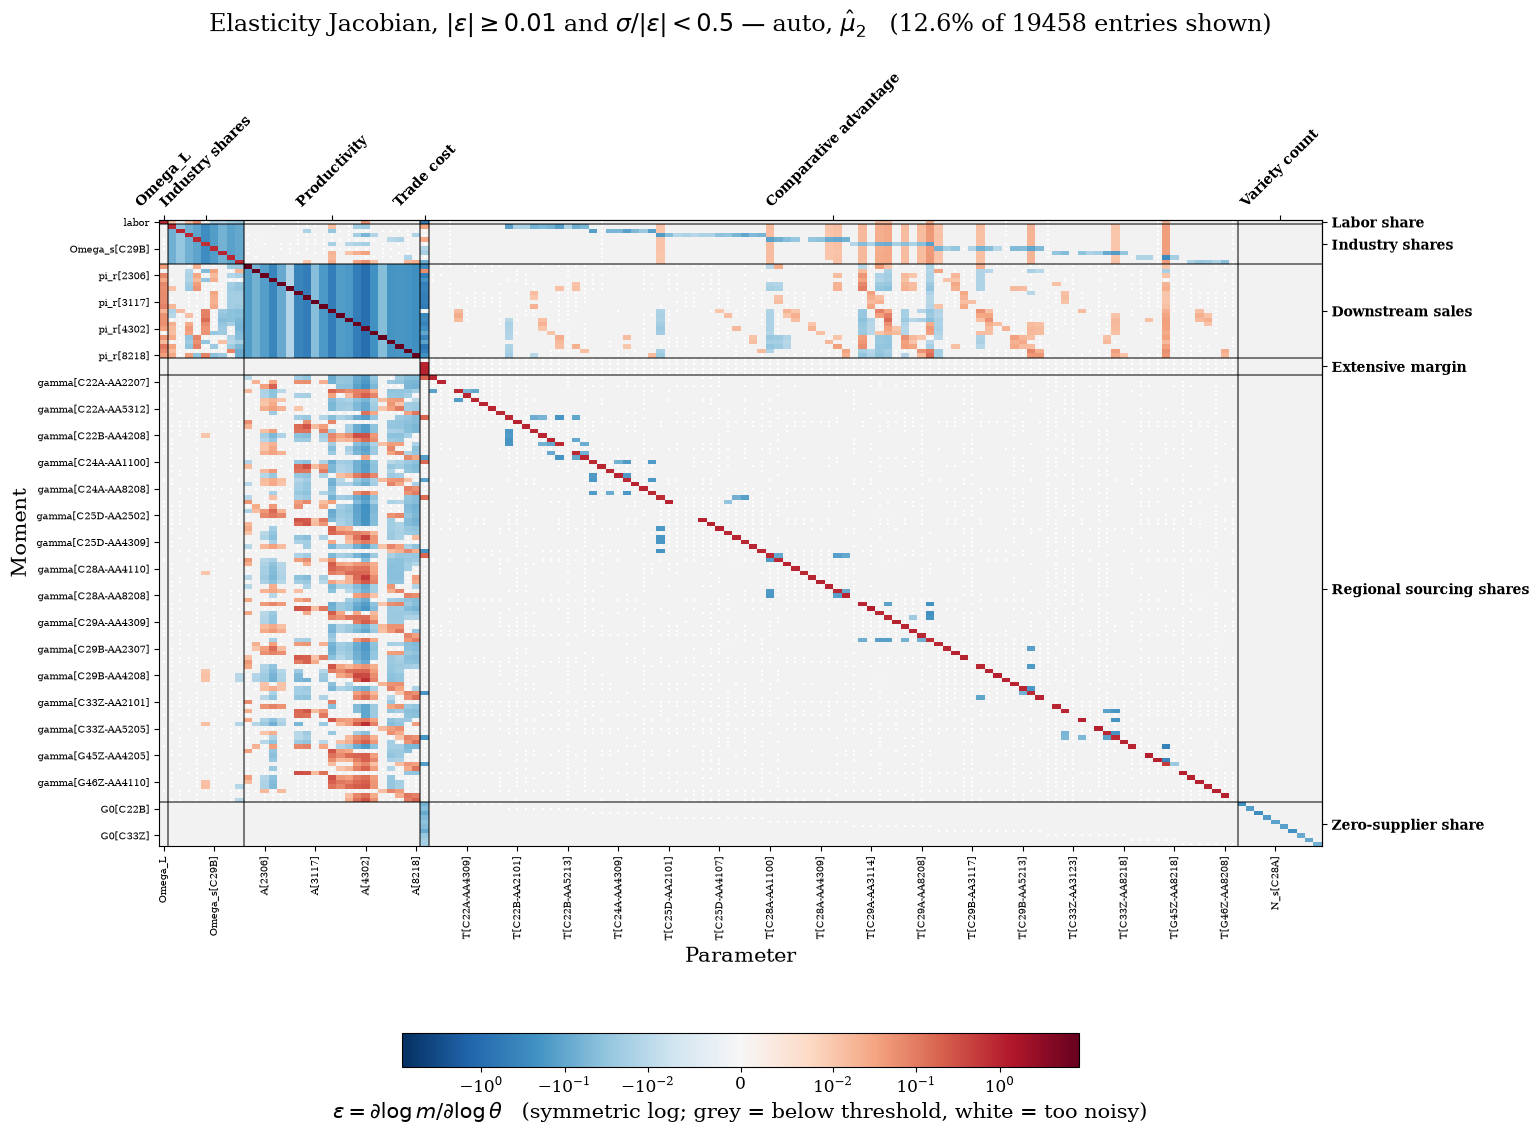

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.777778     0.047619   1.000000   
Industry shares             0.000000        1.000000     0.158730   0.666667   
Downstream sales            0.952381        0.597884     1.000000   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.000000        0.016204     0.596726   0.906250   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.041667           0.0       1.000000   
Industry shares                       0.233796           0.0       0.666667   
Downstream sales                      0.149802           0.0       0.952381   
Extensive margin                      0.312500           0.0       1.000000   
Regional sourcing shares              0.103950           0.0       0.677083   
Zero-supplier share                   0.001042           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.888889     0.952381   1.000000  ...   
Industry shares                 1.000000     0.608466   0.555556  ...   
Downstream sales                0.629630     1.000000   0.952381  ...   
Extensive margin                1.000000     1.000000   0.750000  ...   
Regional sourcing shares        0.547454     0.707837   0.114583  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.008162   0.496615              0.002888   
Industry shares              0.005525   0.020718              0.010077   
Downstream sales             0.655007   0.337642              0.005671   
Extensive margin             0.000000   1.007340              0.008475   
Regional sourcing shares     0.031987   0.081453              0.017223   
Zero-supplier share          0.000000   0.047259              0.000272   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.014944              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


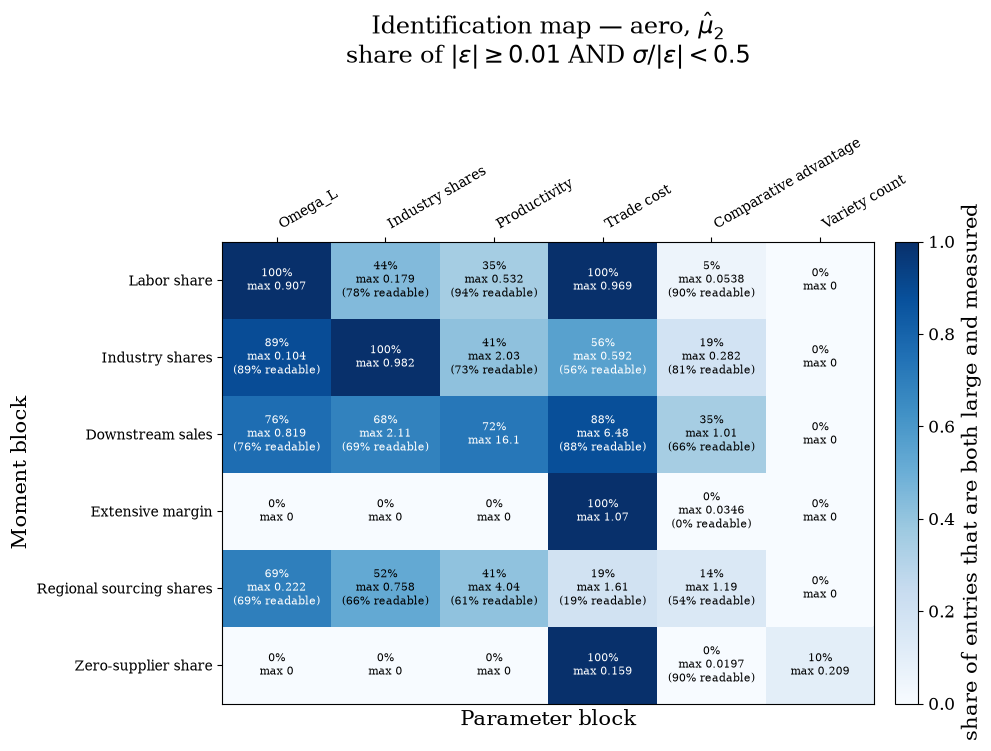

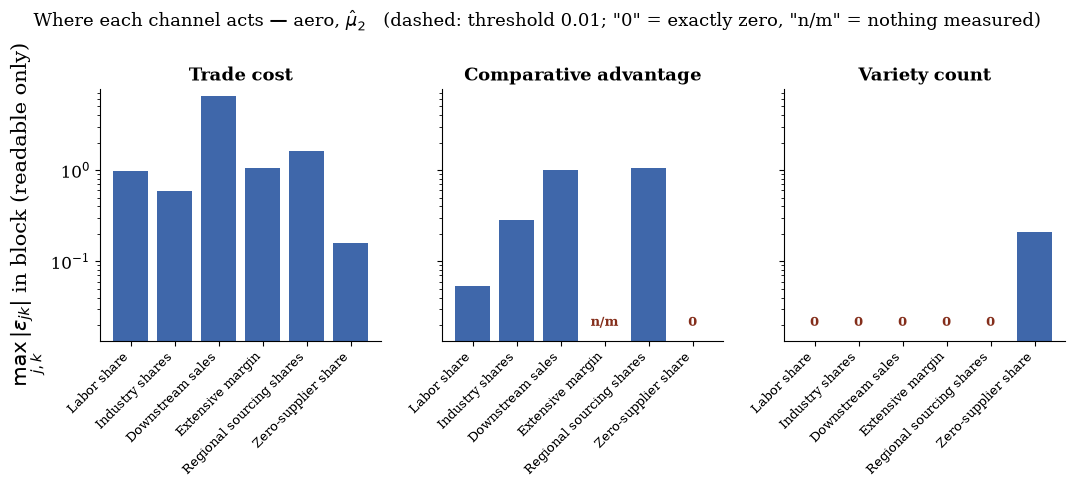

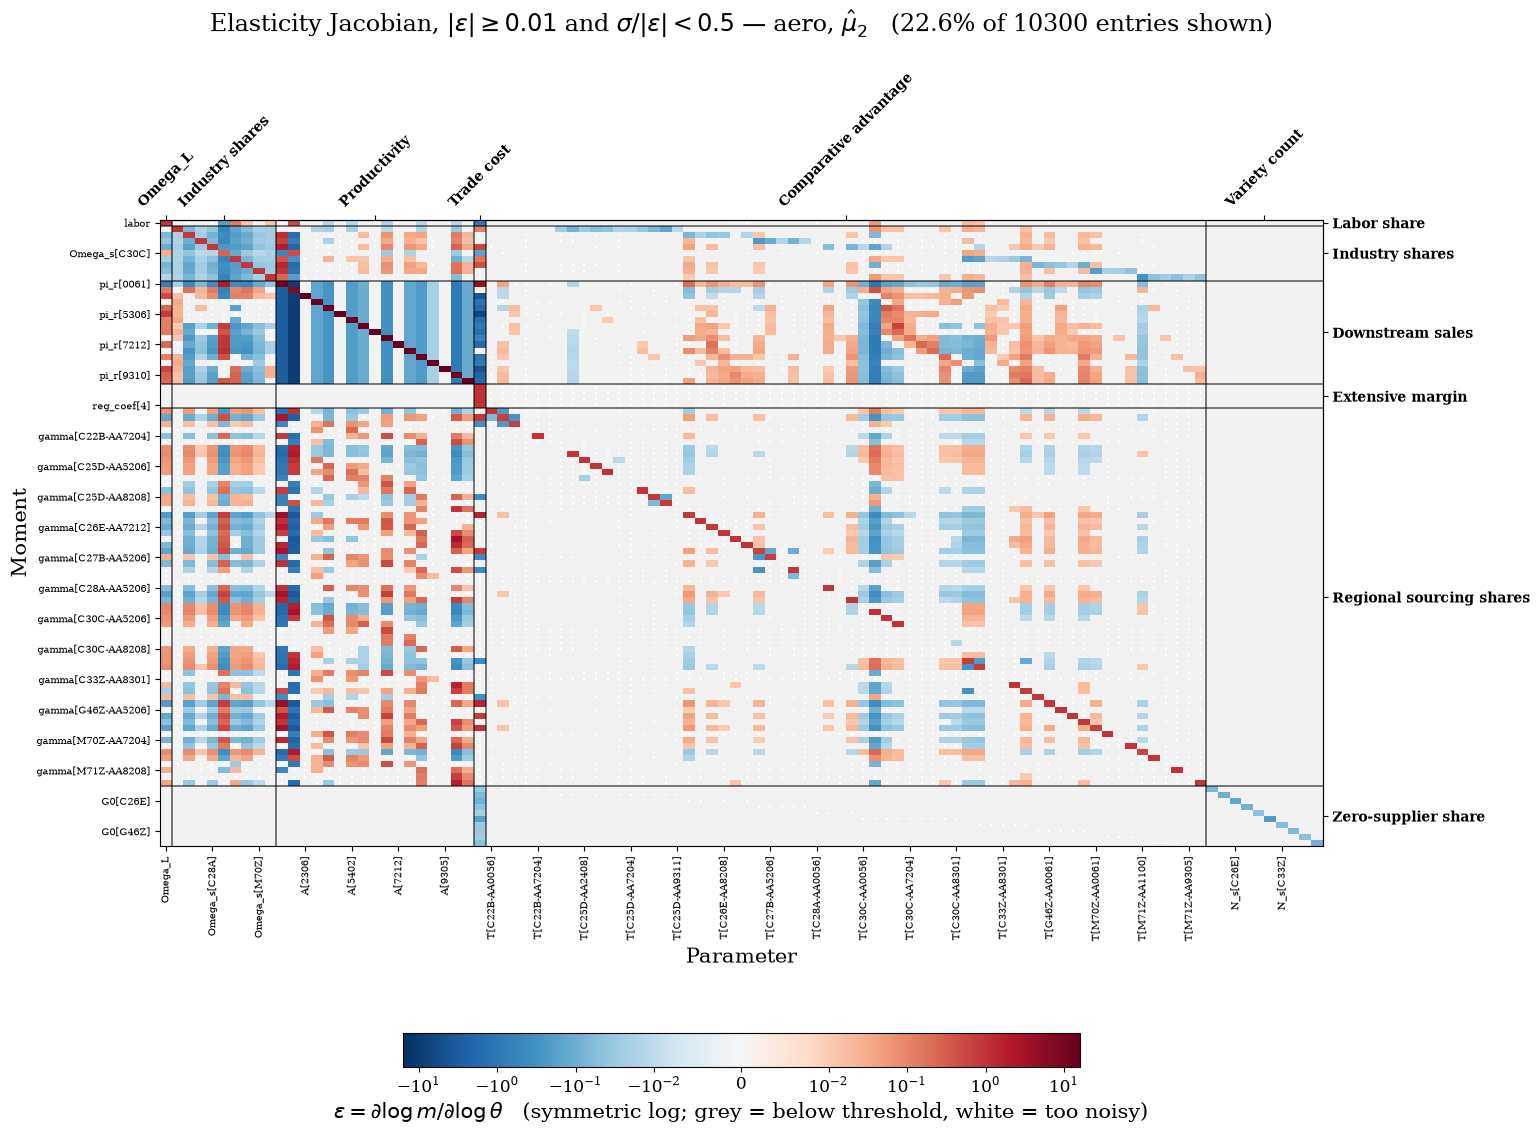

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.444444     0.411765   1.000000   
Industry shares             0.888889        1.000000     0.437908   1.000000   
Downstream sales            0.941176        0.869281     0.723183   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.919355        0.607527     0.556926   0.983871   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                             share_readable  \
param_block              Comparative advantage Variety count        Omega_L   
moment_block                                                                  
Labor share                           0.048387           0.0       1.000000   
Industry shares                       0.193548           0.0       0.888889   
Downstream sales                      0.395636           0.0       0.764706   
Extensive margin                      0.145161           0.0       1.000000   
Regional sourcing shares              0.233091           0.0       0.693548   
Zero-supplier share                   0.009677           0.1       1.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.777778     0.941176   1.000000  ...   
Industry shares                 1.000000     0.725490   0.555556  ...   
Downstream sales                0.686275     1.000000   0.882353  ...   
Extensive margin                1.000000     1.000000   1.000000  ...   
Regional sourcing shares        0.661290     0.609108   0.193548  ...   
Zero-supplier share             1.000000     1.000000   1.000000  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.041226   0.969213              0.002754   
Industry shares              0.116710   0.243268              0.009539   
Downstream sales             1.681982   2.103455              0.029481   
Extensive margin             0.000000   1.051031              0.005057   
Regional sourcing shares     0.189176   0.374187              0.028144   
Zero-supplier share          0.000000   0.052855              0.000315   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.008978              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   

In [101]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))


# Untargeted moment — the distance elasticity of spatial comovement

The estimation targets the spatial decay of production **linkages** (moment block 4).
It does not target how the equilibrium network turns those linkages into the spatial
propagation of downstream shocks. The reduced-form ratio $\delta/\gamma$ of Table 3
measures the latter, and Appendix B.5 shows it identifies

$$\frac{\partial \log \mathbb{E}\!\left[a_{ir}\mid s, r', \mathrm{Dist}_{r'r}=d\right]}{\partial \log d},$$

where $a_{ir}$ is the share of supplier $i$'s sales directed to downstream region $r$.
The model counterpart is therefore obtained by computing $a_{ir}$ in the simulated
economy and estimating by Poisson pseudo-maximum-likelihood

$$\mathbb{E}\!\left[a_{ir}\mid s, r', r\right] \;=\; \exp\!\big(\alpha_{r,s(i)} + \eta \log \mathrm{Dist}_{r'r}\big),$$

with $\alpha_{r,s(i)}$ a sector $\times$ downstream-region fixed effect, and nothing in
the criterion was asked to match it — which is what makes it a test rather than a fit.

Two things stand between $\hat\eta$ and the published number, and both are handled
explicitly below. **The scale**: $\delta/\gamma$ comes from a regression that is linear in
the level of the exposure, so it is a compressed reading of an elasticity —
$\delta/\gamma \approx \eta/(1+|\eta|\overline{\log d})$, bounded by
$1/\overline{\log d}$. Every model estimate is therefore reported on both scales, and the
comparison figure uses the reduced form's. **The variation**: a sector $\times$
buyer-region effect compares *different suppliers* at the same buyer, a **supplier fixed
effect** compares one supplier across *its own* buyers, and those are different objects in
the model — the first includes a composition term the second removes. The moment is
estimated under both, and under both at once.


\swann{Shrink this part, the minimal model should be the model with the downstream x sector + firm fixed effect as in the linear model.}

**Why PPML and not a log-linear regression.** Slightly more than half of the
supplier $\times$ downstream-region cells are zeros, and those zeros *are* the object:
the first of the two forces inside $\eta$ is the extensive margin (a more distant supplier
is less likely to serve the region at all). Taking logs would delete them. Poisson
pseudo-ML is consistent for the conditional **mean** under the exponential specification
alone, so $a_{ir}$ need not be a count, and the zeros enter unmodified. The estimator is
`pyfixest.fepois` — the standard `ppmlhdfe` algorithm — with the fixed effect absorbed and
standard errors clustered on the supplier's own region, as in Table 3.

\swann{Delete this part, note very important}

**The economy this runs on.** `main.jl`'s post-hoc block writes `suppliers.parquet` into
the step folder of the estimate it was computed at (`step1/` for $\hat\theta_1$, `step3/`
for $\hat\theta_2$), so `mu` selects the firm-level economy exactly as it selects the
moments and the inference.

\swann{Delete this part}

### What `suppliers.parquet` contains

One row per **realised linkage**: a (simulated firm, downstream region) pair such that the
firm won at least one variety supplied to that region. A firm is a (cell, sector, variety)
triple — one variety producer, which is the model's supplier — and the file has no row for
a firm-region pair with no linkage, which is why the panel below has to be zero-filled.

| column | what it is |
|--------|-----------|
| `SIREN` | synthetic firm identifier, one per (upstream region, sector, variety) triple |
| `A129` | the sector, as the model's own index $1..S$ — **not** the A129 code; map through `sector_names` |
| `ze2010` | the **supplier's** region, as the model's own index $1..R$ (regions sorted by ZE code) |
| `ze2010_downstream` | the **buyer's** downstream region, same $1..R$ index space |
| `share` | the badly-named one. It is $\texttt{exp\_val}$: the share of the buyer region's **unit cost** spent on this firm, $w_\rho\,\Omega^s(1-\Omega^L)(p_{\rho s}/P_{sr})^{1-\nu_s}(P_{sr}/P_r)^{1-\nu}(P_r/c_r)^{1-\lambda}$. Summed over every firm it gives that region's intermediate-input share of cost — it is *not* a share of the supplier's sales, and it is *not* normalised within the supplier |
| `downstream_purchase` | $\mu Y_r$, the buyer region's total spending on intermediates. `share` $\times$ `downstream_purchase` is the euro flow $X_{i \to r}$ |
| `intermediate_derivative` | `share` renormalised *within* intermediates ($\texttt{exp\_val}$ divided by $(1-\Omega^L)(P_r/c_r)^{1-\lambda}$). Sums to one by construction, so it is a composition, not a magnitude — do not use it as a flow |
| `productivity` | the firm's Fréchet productivity draw $z$ |
| `sample_weight` | the Monte-Carlo weight of the variety draw ($1/N_\rho$ under the flat designs), i.e. how many real firms this simulated one stands for |

The sales share the untargeted moment is about is built from these:
$X_{i \to r} = \texttt{share} \times \texttt{downstream\_purchase}$ and
$a_{ir} = X_{i\to r} / \sum_{r'} X_{i \to r'}$, which sums to one over $r$ for every
supplier.



### The two coefficients of `decompose_untargeted_moment`

Write $\Lambda_{ir} = \mathbf{1}\{a_{ir}>0\}$ for the extensive margin. Then, exactly,

$$\mathbb{E}[a_{ir}] \;=\; \underbrace{\Pr(\Lambda_{ir}=1)}_{\text{extensive}}\times\underbrace{\mathbb{E}[a_{ir}\mid \Lambda_{ir}=1]}_{\text{intensive}},$$

so taking logs and differentiating in $\log d$ gives the **identity**

$$\eta \;=\; \frac{\partial \log \Pr(\Lambda=1)}{\partial \log d} \;+\; \frac{\partial \log \mathbb{E}[a\mid \Lambda=1]}{\partial \log d} \;=\; \eta_{ext} + \eta_{int}.$$

Each term is exactly what its regression estimates. PPML with an exponential mean is a
*conditional-mean* estimator: the coefficient on $\log d$ in
$\mathbb{E}[y \mid \cdot] = \exp(\alpha_g + \beta \log d)$ is
$\partial \log \mathbb{E}[y\mid\cdot]/\partial \log d$ for whatever non-negative $y$ is put
on the left. Put $y = a_{ir}$ on the full panel and $\beta = \eta$. Put $y = \Lambda_{ir}$,
a 0/1 variable whose conditional mean *is* $\Pr(\Lambda=1)$, and $\beta = \eta_{ext}$ — this
is why the extensive margin is estimated by Poisson on a binary outcome rather than by a
logit: PPML returns the elasticity of the **probability**, which is the term of the
identity, whereas a logit returns the elasticity of the odds, which is not. Put
$y = a_{ir}$ on the positive cells only and $\beta = \eta_{int}$, the elasticity of the
conditional mean.

\swann{I like this distinction between the extensive and the intensive margin. Would it be possible, using the decomposition on the appendix (in the latex document ap_structural_2026_endogeneous.tex) to have the theoretical derivation of each margin so we can interpret their amplitude ? I think what you have done bellow is good but I would have liked to have something unified with the appendix too. For the moment keep the demonstration bellow and provide a unification framework in a separate cell.  }

The identity is exact in the population. In the sample the three regressions absorb their
own fixed effects — and the third does so on a *different* set of cells (the positive
ones), where the sector $\times$ region effect is identified off a selected subsample — so
$\hat\eta - \hat\eta_{ext} - \hat\eta_{int}$ need not be exactly zero. It is reported
rather than assumed, and it is small when the composition of the surviving cells does not
move with distance.

**Where the size distribution of downstream regions enters.** $a_{ir}$ is a *portfolio
share*,

$$a_{ir} \;=\; \frac{\rho_{ir}\,\mu Y_r}{\sum_{r'} \rho_{ir'}\,\mu Y_{r'}},$$

with $\rho_{ir}$ the supplier's cost share in region $r$ and $Y_r$ that region's size. The
numerator's $Y_r$ is absorbed by the downstream-region fixed effect — it is common to
every supplier of region $r$. The denominator's is not: it is supplier-specific, and it is
dominated by the *large* regions the supplier serves. That asymmetry is the intensive
margin. Differentiating,

$$\frac{\partial \log a_{ir}}{\partial \log d_{ir}} \;=\; \frac{\partial \log \rho_{ir}}{\partial \log d_{ir}}\,\big(1 - a_{ir}\big),$$

\swann{Bellow you say that $\frac{\partial \log \rho_{ir}}{\partial \log d_{ir}} = \alpha \theta$. Verify it is good and if yes precise it here.}

the $(1-a)$ portfolio term: moving a supplier away from $r$ costs it sales in $r$ *and*
reallocates its remaining sales toward its other buyers, so the share falls by less than
the flow does — and by much less when $r$ is a small part of its portfolio. Hence
$|\eta_{int}| < |\partial \log \rho / \partial \log d|$, with the gap set by how
concentrated the supplier's buyers are, i.e. by the dispersion of $Y_r$. In a geography of
equal-sized downstream regions the wedge is $1 - 1/R_d$ for every supplier and washes into
the fixed effect; with one dominant buyer region, suppliers close to it have $a$ near one
for that region and near zero elsewhere, so their measured intensive decay is compressed
toward zero for the dominant region and near the full $\rho$-elasticity for the rest. The
$Y_r$ distribution therefore shows up in $\eta_{int}$, not in $\eta_{ext}$ (which is a
probability, free of $Y$), and it is one reason the model's $\eta$ can differ from the
reduced-form $\delta/\gamma$ even when the linkage decay is matched exactly.



### The distance profile, and what the fixed effect does to it

`plot_a_ir_profile` re-runs the *same* PPML with distance-bin dummies in place of
$\log d$, so the shape is not imposed. Its points are therefore **not** a mean profile
across sectors: the sector $\times$ downstream-region fixed effect is absorbed exactly as
in the $\eta$ regression, so each point is a comparison *within* a (sector, buyer region)
cell between suppliers at different distances — the same variation $\hat\eta$ uses, read
non-parametrically. Only differences relative to the reference (nearest) bin are
identified, which is what the axis reports; the level is absorbed. For contrast the figure
also draws, in a lighter dashed line, the **unconditional** profile — the raw
weighted-mean $a_{ir}$ by bin, relative to the nearest bin, with no fixed effect. The gap
between the two lines is what the fixed effect removes: composition, i.e. the fact that
distant supplier-buyer pairs are not drawn from the same sectors and the same buyer
regions as nearby ones.


In [102]:
# The (supplier x downstream region) panel, and the PPML that reads eta off it.
# The estimator is pyfixest.fepois — ppmlhdfe's algorithm — so nothing about Poisson
# pseudo-ML is re-implemented here.

# Empirical delta/gamma from Table 3 (the spatial comovement regression): point estimate
# and 95% CI. These are DATA, not model output, and they are not read from any file in
# this repository — override them here if the reduced-form estimates change.
EMPIRICAL_DELTA_OVER_GAMMA = {
    "auto": {"estimate": -0.109, "ci_lo": -0.122, "ci_hi": -0.096,
             "display_name": "Motor Vehicles"},
    "aero": {"estimate": -0.098, "ci_lo": -0.130, "ci_hi": -0.065,
             "display_name": "Aerospace"},
}


def build_a_ir_panel(data, min_distance_km=1.0, firm_key=("SIREN",)):
    """
    The (supplier x downstream region) panel the PPML runs on, ZERO-FILLED.

    `suppliers.parquet` records only realised linkages (see the column glossary above).
    The regression needs the non-linkages too — a supplier that does not serve region r
    has a_ir = 0, and that extensive margin is half of what the moment measures — so
    every supplier is crossed with every downstream region and the missing cells are
    filled at 0.

    The sample is suppliers, i.e. varieties that win somewhere, which is the
    conditioning Sup_i = 1 of equation (3) and of (B36).

    Region codes are the model's own 1..R indices for BOTH `ze2010` (the supplier's
    cell) and `ze2010_downstream` (the buyer), so the distance is read straight out of
    `distances.npy` with no name round-trip.

    `firm_key` is what counts as one supplier. The default is the parquet's own `SIREN`,
    i.e. ONE VARIETY in one cell — the model's supplier. Passing `("ze2010", "A129")`
    pools every variety a (region, sector) produces into a single multi-variety firm,
    which is closer to what a SIREN is in the data and flattens the distance profile; the
    specification ladder below uses it to measure how much.

    `min_distance_km` is a floor, not a convention: the own-region entry of the distance
    matrix is the region's own internal distance, which is POSITIVE and differs across
    regions (a large commuting zone is further from itself than a small one), exactly as
    the model uses it. The floor only guards against a data file that happens to store a
    hard zero on the diagonal, which would send log d to -infinity.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data['step_dir']}/ (or it was "
            "unreadable — pyarrow missing?). main.jl writes one per estimate in its "
            "post-hoc block, after the estimation.")

    dist_path = data["input_folder"] / "distances.npy"
    if not dist_path.exists():
        raise FileNotFoundError(f"{dist_path} not found — needed for log Dist_{{r'r}}.")
    D = np.load(dist_path)
    R = data["R"]
    if D.shape[0] < R or D.shape[1] < R:
        raise ValueError(f"distances.npy is {D.shape}, too small for R = {R} regions.")
    D = D[:R, :R]

    df = sup[["SIREN", "A129", "ze2010", "ze2010_downstream",
              "share", "downstream_purchase", "productivity", "sample_weight"]].copy()

    # The supplier identifier. Under the default it IS the parquet's SIREN; under an
    # aggregating `firm_key` the column is rebuilt from the key, and the euro flows of the
    # pooled varieties are added before the share is formed — which is what makes the
    # aggregated firm a genuine multi-variety supplier rather than an average of shares.
    if tuple(firm_key) != ("SIREN",):
        df["SIREN"] = df[list(firm_key)].astype(str).agg("-".join, axis=1)

    # X_{i->r} = share x (mu Y_r); a_ir = X_{i->r} / sum_r X_{i->r}
    df["X_ir"] = df["share"] * df["downstream_purchase"]
    # how many real firms one simulated supplier stands for: the MEAN of its varieties'
    # draw weights, so that pooling varieties does not multiply the weight (under the
    # flat draw designs every variety carries 1/N_rho and a pooled firm still does)
    w_firm = df.groupby("SIREN", sort=True)["sample_weight"].mean()
    df = (df.groupby(["SIREN", "ze2010_downstream"], as_index=False)
            .agg(A129=("A129", "first"), ze2010=("ze2010", "first"),
                 X_ir=("X_ir", "sum"), productivity=("productivity", "mean")))
    tot = df.groupby("SIREN", sort=False)["X_ir"].transform("sum")
    df["a_ir"] = np.where(tot > 0, df["X_ir"] / tot, 0.0)

    # --------------------------------------------------------- zero-filling ---
    firms = df.groupby("SIREN", sort=True).agg(
        A129=("A129", "first"), ze2010=("ze2010", "first"),
        productivity=("productivity", "first")).reset_index()
    firms["sample_weight"] = firms["SIREN"].map(w_firm)
    downstream = np.sort(df["ze2010_downstream"].unique())

    panel = firms.merge(pd.DataFrame({"ze2010_downstream": downstream}), how="cross")
    panel = panel.merge(df[["SIREN", "ze2010_downstream", "a_ir"]],
                        on=["SIREN", "ze2010_downstream"], how="left")
    panel["a_ir"] = panel["a_ir"].fillna(0.0)

    # ------------------------------------------------------------ regressors --
    d = D[panel["ze2010"].to_numpy() - 1, panel["ze2010_downstream"].to_numpy() - 1]
    panel["distance"] = d
    panel["log_distance"] = np.log(np.maximum(d, min_distance_km))
    panel["log_productivity"] = np.log(np.maximum(panel["productivity"].to_numpy(), 1e-300))
    panel["served"] = (panel["a_ir"].to_numpy() > 0).astype(float)
    # alpha_{r, s(i)} : sector x downstream-region
    panel["fe_group"] = (panel["A129"].astype(str) + "-"
                         + panel["ze2010_downstream"].astype(str))
    panel["cluster"] = panel["ze2010"].astype(str)     # supplier's region, as in Table 3
    return panel


def fepois_fit(panel, y, rhs=("log_distance",), fe="fe_group", cluster="cluster",
               weights="sample_weight"):
    """
    One `pyfixest.fepois` call: E[y | .] = exp(fixed effect + rhs'beta).

    `fe` is passed to pyfixest as written, so "fe_group" absorbs the sector x
    downstream-region effect, "SIREN" absorbs a SUPPLIER effect, and "fe_group + SIREN"
    absorbs both.

    A three-line wrapper around the library, not an estimator: it writes the formula,
    passes the Monte-Carlo draw weights as analytic weights, clusters on the supplier's
    own region and lets pyfixest drop the fixed-effect groups that are separated (a
    group with no positive outcome contributes nothing to the Poisson score, exactly as
    in `ppmlhdfe`). Returns the fitted object, so `.coef()`, `.se()`, `.tidy()` and
    `.summary()` are all available at the call site.
    """
    fml = f"{y} ~ " + " + ".join(rhs) + (f" | {fe}" if fe else "")
    return pf.fepois(fml=fml, data=panel, weights=weights, weights_type="aweights",
                     vcov=None if cluster is None else {"CRV1": cluster},
                     separation_check=["fe"])


def delta_over_gamma_from_eta(eta, mean_log_d=None):
    """
    A constant elasticity `eta` expressed as the reduced form's `delta/gamma`.

    The spatial-comovement regression is LINEAR IN THE LEVEL of the exposure — gamma on
    the demand shock, delta on the shock interacted with log distance — so it fits
    E[a|d] = gamma + delta log d. Fitting a constant-elasticity profile A d^eta that way
    puts gamma at the extrapolated intercept log d = 0 (one kilometre, far outside any
    data), and linearising around the mean gives

        delta/gamma  ~=  eta / (1 + |eta| * mean(log d)).

    Two things follow. The map is strongly COMPRESSIVE, and it is BOUNDED: whatever the
    true elasticity, |delta/gamma| can never exceed 1/mean(log d) — 0.17 at the empirical
    mean of 5.8. So a model eta and a published delta/gamma cannot be compared as they
    stand; one has to be put on the other's scale, which is what this does.

    `mean_log_d` defaults to `EMPIRICAL_MEAN_LOG_D`, the mean in the ESTIMATION SAMPLE OF
    THE REDUCED FORM — the right one here, since the compression is a property of the
    regression that produced the published number, not of the simulated geography.
    """
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    return float(eta) / (1.0 + abs(float(eta)) * m)


def eta_from_delta_over_gamma(ratio, mean_log_d=None):
    """The inverse map: the constant elasticity a published `delta/gamma` implies."""
    m = EMPIRICAL_MEAN_LOG_D if mean_log_d is None else mean_log_d
    r = float(ratio)
    denom = 1.0 - abs(r) * m
    return r / denom if denom > 0 else -np.inf


# The fixed effects the moment is estimated under. The first is the paper's own
# specification; the other two are the diagnostic the comparison with the data needs.
UNTARGETED_FE_SPECS = {
    "sector x buyer region": "fe_group",
    "supplier (firm FE)": "SIREN",
    "both": "fe_group + SIREN",
}


def estimate_untargeted_moment(data, controls=(), cluster="cluster", panel=None,
                               fe_specs=UNTARGETED_FE_SPECS, verbose=True):
    """
    PPML estimate of eta in E[a_ir] = exp(fixed effect + eta log Dist_{r'r}), under each
    fixed-effect specification in `fe_specs`.

    The FIRST entry is the headline: a sector x downstream-region effect, the paper's own
    specification. It compares DIFFERENT SUPPLIERS serving the same buyer, so the distance
    gradient it measures includes a composition term — a supplier far from r is, in this
    geography, necessarily close to some other buyer, and that buyer dominates the
    denominator of its portfolio share.

    The SUPPLIER fixed effect removes exactly that: it compares one supplier's shares
    across ITS OWN buyers, which is the variation a firm-fixed-effect shock regression
    uses, and which the model bounds at theta*alpha(1-a). Absorbing BOTH leaves only the
    variation that is within a supplier and within a buyer region at once.

    `controls` adds columns of the panel to the right-hand side (the paper's
    specification has none; `("log_productivity",)` conditions on the supplier's
    productivity draw). `cluster=None` gives the classical Poisson variance.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    cols = ["log_distance"] + list(controls)
    specs = {}
    for label, fe in fe_specs.items():
        fit = fepois_fit(panel, "a_ir", rhs=cols, fe=fe, cluster=cluster)
        b = float(fit.coef()["log_distance"])
        se = float(fit.se()["log_distance"])
        specs[label] = {"fe": fe, "eta": b, "se": se,
                        "ci_lo": b - 1.96 * se, "ci_hi": b + 1.96 * se,
                        "dg": delta_over_gamma_from_eta(b),
                        "dg_lo": delta_over_gamma_from_eta(b - 1.96 * se),
                        "dg_hi": delta_over_gamma_from_eta(b + 1.96 * se),
                        "n_obs": int(getattr(fit, "_N", len(panel))), "fit": fit}

    head = specs[list(fe_specs)[0]]
    eta, se = head["eta"], head["se"]
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    out = {"industry": data["industry"], "mu": data["mu"], "spec": "+".join(cols),
           "eta": eta, "se": se, "t": eta / se if se > 0 else np.nan,
           "ci_lo": head["ci_lo"], "ci_hi": head["ci_hi"],
           # the same estimate on the reduced form's own scale
           "dg": head["dg"], "dg_lo": head["dg_lo"], "dg_hi": head["dg_hi"],
           "specs": specs,
           "coefs": head["fit"].coef().to_dict(), "ses": head["fit"].se().to_dict(),
           "n_obs": head["n_obs"], "n_firms": int(panel["SIREN"].nunique()),
           "share_zero": float((panel["a_ir"].to_numpy() == 0).mean()),
           "emp_estimate": emp.get("estimate"), "emp_ci_lo": emp.get("ci_lo"),
           "emp_ci_hi": emp.get("ci_hi"), "fit": head["fit"], "panel": panel}

    if verbose:
        print(f"[{data['industry']}]  {len(panel):,} supplier x downstream-region cells, "
              f"{out['n_firms']:,} suppliers, {100 * out['share_zero']:.1f}% zeros, "
              f"from {data['suppliers_path']}")
        print(f"{'  fixed effect':<26}{'eta':>10}{'se':>9}   "
              f"{'-> delta/gamma':>15}  (mean log d = {EMPIRICAL_MEAN_LOG_D})")
        for label, sp in specs.items():
            print(f"  {label:<24}{sp['eta']:>+10.4f}{sp['se']:>9.4f}   "
                  f"{sp['dg']:>+15.4f}  [{sp['dg_lo']:+.4f}, {sp['dg_hi']:+.4f}]")
        if out["emp_estimate"] is not None:
            print(f"  {'DATA delta/gamma':<24}{'':>10}{'':>9}   "
                  f"{out['emp_estimate']:>+15.4f}  [{out['emp_ci_lo']:+.4f}, "
                  f"{out['emp_ci_hi']:+.4f}]")
    return out


def decompose_untargeted_moment(data, panel=None, cluster="cluster", verbose=True):
    """
    eta split into its extensive and intensive parts, as derived in the markdown above.

    E[a_ir] = P(i serves r) x E[a_ir | i serves r], so the elasticity of the product is
    the sum of the two elasticities:

        eta = eta_ext + eta_int,
        eta_ext : PPML on the 0/1 indicator — the elasticity of the PROBABILITY of
                  serving the region (Poisson, not logit, precisely because the identity
                  is about the probability and not the odds),
        eta_int : PPML on the positive a_ir — the elasticity of the conditional mean,
                  which carries the (1 - a) portfolio term.

    Exact in the population; in the sample the three regressions absorb their own fixed
    effects, and the intensive one does so on the selected subsample of positive cells,
    so the residual is reported rather than assumed away.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    pos = panel[panel["a_ir"] > 0]

    total = fepois_fit(panel, "a_ir", cluster=cluster)
    ext = fepois_fit(panel, "served", cluster=cluster)
    inte = fepois_fit(pos, "a_ir", cluster=cluster)

    rows = [("eta (total)", total, len(panel)),
            ("eta_ext (extensive: probability of serving)", ext, len(panel)),
            ("eta_int (intensive: portfolio share, served cells)", inte, len(pos))]
    df = pd.DataFrame([{"channel": name,
                        "coefficient": float(f.coef()["log_distance"]),
                        "se": float(f.se()["log_distance"]),
                        "n_obs": n} for name, f, n in rows])
    gap = float(df.loc[0, "coefficient"] - df.loc[1, "coefficient"] - df.loc[2, "coefficient"])
    if verbose:
        print(df.to_string(index=False))
        print(f"  eta - (eta_ext + eta_int) = {gap:+.4f}   "
              "(exactly zero only when the three fixed effects coincide)")
    return {"table": df, "gap": gap, "total": total, "extensive": ext, "intensive": inte}


In [103]:
# The untargeted-moment figures and the summary table.

def untargeted_summary(results):
    """
    One row per (industry, fixed-effect specification): the model's eta, the delta/gamma
    it corresponds to under the reduced form's functional form, and the published number.

    The comparison column is `delta/gamma (model)`, NOT eta: the two are different
    readings of the same profile, and only the first is on the scale Table 3 reports.
    """
    rows = []
    for r in results:
        emp = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
        for label, sp in r["specs"].items():
            rows.append({
                "industry": emp.get("display_name", r["industry"]),
                "fixed effect": label,
                "eta (model)": sp["eta"],
                "se": sp["se"],
                "delta/gamma (model)": sp["dg"],
                "95% CI (model, delta/gamma)": f"[{sp['dg_lo']:+.3f}, {sp['dg_hi']:+.3f}]",
                "delta/gamma (data)": r["emp_estimate"],
                "95% CI (data)": (f"[{r['emp_ci_lo']:+.3f}, {r['emp_ci_hi']:+.3f}]"
                                  if r["emp_ci_lo"] is not None else "---"),
                "inside data CI": (None if r["emp_ci_lo"] is None
                                   else bool(r["emp_ci_lo"] <= sp["dg"] <= r["emp_ci_hi"])),
                "suppliers": r["n_firms"], "cells": sp["n_obs"],
            })
    return pd.DataFrame(rows).set_index(["industry", "fixed effect"])


MODEL_SPEC_MARKERS = {"sector x buyer region": ("o", sim_color),
                      "supplier (firm FE)": ("^", (0.30, 0.55, 0.40)),
                      "both": ("v", (0.45, 0.40, 0.60))}


def plot_untargeted_moment(results, scale="delta_over_gamma", figsize=None, save_to=None):
    """
    The model against the published reduced form, one group per industry.

    `scale="delta_over_gamma"` (the default) is the comparison that means something: each
    model estimate is mapped through `delta_over_gamma_from_eta`, i.e. read the way the
    spatial-comovement regression would have read the same profile. On that scale the
    dashed line is the ceiling 1/mean(log d) — no reduced-form ratio, in the model or in
    the data, can lie beyond it, which is worth seeing next to the estimates.
    `scale="eta"` plots the raw elasticities instead, and then only the model points are
    on the right scale.

    Every fixed-effect specification is drawn: the paper's sector x buyer-region effect,
    the supplier effect, and both. The spread between them IS the composition channel.
    """
    dg = scale == "delta_over_gamma"
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.65))
    x = np.arange(len(results))
    labels = list(MODEL_SPEC_MARKERS)
    offs = np.linspace(-0.22, 0.06, len(labels))

    for i, r in enumerate(results):
        for k, label in enumerate(labels):
            sp = r["specs"].get(label)
            if sp is None:
                continue
            v = sp["dg"] if dg else sp["eta"]
            lo = sp["dg_lo"] if dg else sp["ci_lo"]
            hi = sp["dg_hi"] if dg else sp["ci_hi"]
            m, c = MODEL_SPEC_MARKERS[label]
            ax.errorbar(x[i] + offs[k], v, yerr=[[v - lo], [hi - v]], fmt=m, color=c,
                        capsize=4, markersize=7,
                        label=f"Model, {label} FE" if i == 0 else None)
        if r["emp_estimate"] is not None and dg:
            ax.errorbar(x[i] + 0.22, r["emp_estimate"],
                        yerr=[[r["emp_estimate"] - r["emp_ci_lo"]],
                              [r["emp_ci_hi"] - r["emp_estimate"]]],
                        fmt="s", color=reference_color, capsize=4, markersize=8,
                        label="Data $\\delta/\\gamma$ (Table 3)" if i == 0 else None)

    if dg:
        ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
        ax.axhline(ceil, color="0.4", linestyle=":", linewidth=1.1)
        ax.annotate(rf"ceiling $-1/\overline{{\log d}}$ = {ceil:.3f}", (0.01, ceil),
                    xycoords=("axes fraction", "data"), fontsize=8, color="0.35",
                    va="bottom")
    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xlim(-0.5, len(results) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
                        .get("display_name", r["industry"]) for r in results])
    ax.set_ylabel(r"$\delta/\gamma$ (reduced-form scale)" if dg
                  else r"$\eta$ (constant elasticity)")
    ax.set_title("Untargeted moment: model against the spatial-comovement regression"
                 + (f"\n(model elasticities mapped through "
                    rf"$\delta/\gamma = \eta/(1+|\eta|\overline{{\log d}})$, "
                    f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),
                 fontsize=10)
    ax.legend(frameon=False, loc="best", fontsize=8)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def a_ir_bin_profile(panel, bins, cluster="cluster"):
    """
    The distance profile behind eta, estimated non-parametrically.

    Distance-bin dummies replace log distance in the SAME PPML — same outcome, same
    sector x downstream-region fixed effect, same weights and clustering — so each
    coefficient is a comparison WITHIN a (sector, buyer region) cell between suppliers
    at different distances, relative to the nearest bin. It is not a mean across sectors:
    the fixed effect removes exactly the composition that a raw mean would confound.

    Returns (labels, b, se, raw), where `raw` is the UNCONDITIONAL profile — the log of
    the weighted-mean a_ir by bin, relative to the nearest bin, with no fixed effect at
    all. The gap between the two is what the fixed effect takes out.
    """
    p = panel.copy()
    cats = pd.cut(p["distance"], bins=list(bins), right=False)
    codes, intervals = pd.factorize(cats, sort=True)
    labels = [f"{int(iv.left)}-{'+' if np.isinf(iv.right) else int(iv.right)}"
              for iv in intervals]
    dummy_cols = []
    for k in range(1, len(intervals)):                 # first bin = reference
        col = f"dbin_{k}"
        p[col] = (codes == k).astype(float)
        dummy_cols.append(col)

    fit = fepois_fit(p, "a_ir", rhs=tuple(dummy_cols), cluster=cluster)
    coef, se_all = fit.coef(), fit.se()
    b = np.concatenate([[0.0], [float(coef[c]) for c in dummy_cols]])
    se = np.concatenate([[0.0], [float(se_all[c]) for c in dummy_cols]])

    w = p["sample_weight"].to_numpy()
    a = p["a_ir"].to_numpy()
    means = np.array([np.average(a[codes == k], weights=w[codes == k])
                      if (codes == k).any() else np.nan for k in range(len(intervals))])
    with np.errstate(divide="ignore", invalid="ignore"):
        raw = np.log(means / means[0])
    return labels, b, se, raw


def plot_a_ir_profile(results, bins=(0, 50, 100, 150, 200, 300, np.inf),
                      show_unconditional=True, figsize=None, save_to=None):
    """
    The shape behind eta, per industry: the fixed-effect-absorbed profile (solid, with
    95% bars) and, for contrast, the unconditional one (dashed, no fixed effect).
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    labels = None
    palette = [sim_color, reference_color, (0.3, 0.5, 0.3), (0.5, 0.4, 0.6)]
    for i_r, r in enumerate(results):
        labels, b, se, raw = a_ir_bin_profile(r["panel"], bins)
        name = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {}).get(
            "display_name", r["industry"])
        col = palette[i_r % len(palette)]
        ax.errorbar(np.arange(len(b)), b, yerr=1.96 * se, marker="o", capsize=3,
                    color=col, label=f"{name} — within sector x buyer region")
        if show_unconditional:
            ax.plot(np.arange(len(raw)), raw, marker="", linestyle="--", alpha=0.55,
                    color=col, label=f"{name} — unconditional")

    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Distance to the downstream region (km)")
    ax.set_ylabel(r"$\log E[a_{ir}]$ relative to the nearest bin")
    ax.legend(frameon=False, fontsize=8)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\l'
<>:93: SyntaxWarning: invalid escape sequence '\o'
<>:93: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_227950/792948901.py:93: SyntaxWarning: invalid escape sequence '\o'
  f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),
/tmp/ipykernel_227950/792948901.py:93: SyntaxWarning: invalid escape sequence '\l'
  f"$\overline{{\log d}}$ = {EMPIRICAL_MEAN_LOG_D})" if dg else ""),


### Why is the model's $\hat\eta$ so much larger than the data's $\delta/\gamma$?

$\hat\eta \approx -0.71$ against $\delta/\gamma \approx -0.10$ looks like a factor of
seven, and the cross-industry ranking comes out reversed. Most of that is not a
disagreement about the economics: **the two numbers are read off the same profile in two
different ways**, and until they are put on one scale there is nothing to compare. Three
questions have to be separated — *are they the same object*, *what would bias the data's
number*, and *what is missing from the model* — and the ladder below walks the model's
number down to the data's, one specification difference at a time.

\swann{Since we do the fix bellow, the above description is not very important, remove it and keep bellow by assuming that now the correction you propose is the baseline. In the empiric the distance is not centered so the gap is real. Still keep the description of the correction}

**1. The functional forms differ, and that is most of the gap.** PPML fits a *constant
elasticity*, $\mathbb{E}[a\mid d] = e^{\alpha_g} d^{\eta}$. The spatial-comovement
regression is *linear in the level*: the coefficient on the demand shock is $\gamma$ and on
its interaction with $\log d$ is $\delta$, so it fits
$\mathbb{E}[a \mid d] = \gamma + \delta \log d$. Fit $A d^{\eta}$ that way and $\gamma$
lands at the *extrapolated intercept at* $\log d = 0$, one kilometre — far outside any
data — so the ratio is compressed:

$$\frac{\delta}{\gamma} \;\approx\; \frac{\eta}{1 + |\eta|\,\overline{\log d}}.$$

At the empirical $\overline{\log d} = 5.8$ (`EMPIRICAL_MEAN_LOG_D`, about 330 km),
$\eta = -0.71$ **reports as $\delta/\gamma = -0.139$**, against $-0.098$ in the data: a
factor of seven becomes a factor of 1.4, and the model's number sits just outside the
aerospace interval $[-0.130, -0.065]$ rather than an order of magnitude away. Note also
that the map is *bounded* — $|\delta/\gamma| < 1/\overline{\log d} = 0.17$ whatever the
true elasticity — so a published ratio of $0.1$ is already 60% of the way to the ceiling.
Everything the notebook reports is therefore shown on **both** scales, and the comparison
figure plots the reduced-form one.



This compression is real only if the empirical regression does not centre $\log d$. If it
uses $\log(d/\bar d)$, $\gamma$ is $\mathbb{E}[a]$ at the mean distance and the ratio is
the elasticity there. **Worth checking in the empirical code**, because it is the
difference between a factor of 1.4 and a factor of 7.

**2. Whose variation? The fixed effect decides.** The headline PPML absorbs a
sector $\times$ *buyer-region* effect, so it compares *different suppliers* serving the
same buyer, and part of what it measures is composition: a supplier far from $r$ is, in
this geography, necessarily close to some *other* buyer, and that buyer dominates the
denominator of its portfolio share. Within a supplier the model's gradient is bounded:

$$\frac{\partial \log a_{ir}}{\partial \log d_{ir}} = -\theta\alpha\,(1-a_{ir}),$$

with $\theta\hat\alpha \approx 0.27$ for motor vehicles and $0.43$ for aerospace. Mapped
onto the reduced-form scale those bounds are $-0.105$ and $-0.123$ — sitting essentially
on the published $-0.109$ and $-0.098$. So the trade-cost elasticity the estimation
identifies is, on its own, about the right size for the reduced form; what the headline
$\hat\eta$ adds on top of it is the cross-supplier composition. If the empirical
regression carries a **firm fixed effect** — as the comovement regressions in this
repository's own simulation code do (`fe(firm_id)`) — then the data's $\delta/\gamma$ is a
within-firm gradient and the model's within-firm counterpart is the right comparison.
That is why the moment is now estimated under three fixed-effect specifications
(`UNTARGETED_FE_SPECS`): sector $\times$ buyer region, supplier, and both. The gap between
the first two *is* the composition channel, measured.

\swann{The right specification is both. Make it the baseline and remove the other specification. Clean the code for that.}

**3. The unit is not the same firm.** A model supplier is one *variety* produced in one
*cell*: the most concentrated portfolio the geography allows. A SIREN in the data is a
bundle of products and often of plants, and aggregation averages distance profiles toward
zero. The ladder pools all varieties of a (region, sector) into one multi-variety firm —
still single-location, so it is a lower bound on the effect — and re-estimates.

\swann{So it is a representative firm with average productivity being close to the mean of frechet if there is a high number of varieties per sector region right ? But it is the upper bound of the frechet since we only have varieties of selected suppliers.}

**4. What is missing from the model all pushes the same way.** Everything that lets a
distant supplier hold a large share of a buyer is absent: long-term contracts and
certification (decisive in aerospace, where a qualified supplier is not replaced because a
closer one exists), multi-plant firms, logistics hubs, and any product differentiation
within a sector other than the Fréchet draw. Once the sector $\times$ buyer-region effect
is absorbed, distance is the *only* thing left in the model that can move $a_{ir}$, so it
inherits the whole of the variation that in the data is spread across many determinants.
Granularity works the same way: with $\hat N_s$ of the order of ten varieties per sector,
whichever supplier wins takes a large share, which sharpens the map from distance to
shares.

**5. What would bias the data's number, and in which direction.** Classical measurement
error in the demand shock attenuates $\gamma$ and $\delta$ *proportionally*, so the ratio
is protected against it — that is the virtue of reporting a ratio. Three things are not
symmetric, and all three push $|\delta/\gamma|$ **down**:

* *spatially correlated demand shocks.* $\gamma$ is identified off the common component of
  regional demand growth, $\delta$ off its spatial dispersion. French regional demand
  shocks are strongly correlated, so the interaction is the weakly identified half and
  attenuates toward zero;
* *error in the distance itself* — a firm's registered address rather than the plant that
  ships, a buyer assigned to its headquarters' region. Classical error in $\log d$
  attenuates $\delta$ and leaves $\gamma$ alone, which is exactly a downward bias in the
  ratio;
* *sample composition.* The estimation sample is firms large enough to be observed
  responding to shocks; large firms are the diversified ones with the flattest profiles.

One thing pushes the other way and is worth stating: firm sales in the data include sales
outside the modelled industry. If suppliers near the industry's core are more specialised
in it, that outside share *rises* with distance, measured exposure falls faster than
$a_{ir}$ does, and $|\delta/\gamma|$ is biased *up* — so it cannot explain a number that
is too small.

**6. The ranking.** Two things. First, the data cannot rank the industries: the intervals
are $[-0.130, -0.065]$ for aerospace and $[-0.122, -0.096]$ for motor vehicles, each
containing the other's point estimate, so the "reversal" is a difference of $0.011$
between two statistically indistinguishable numbers. Second, the model's ranking follows
$\theta\hat\alpha$ ($0.43$ aerospace against $0.27$ motor vehicles) and, on top of it, the
geography of the estimated $\hat T$: under profiling $\hat T$ is the Sinkhorn image of the
*observed* sourcing shares, so an industry whose sourcing is concentrated on one attraction
area gets a concentrated $\hat T$, hence concentrated portfolios, hence a steeper
cross-supplier gradient. Aerospace is the more concentrated of the two, so the model makes
it the steeper — while in the data aerospace is, weakly, the flatter, which is what a
contracting-and-certification story would predict and what §4 says the model has no room
for.


In [104]:
# The specification ladder: the same panel, one difference at a time, from the model's
# reported eta to the object the reduced form actually reports. Every rung is shown both
# as an elasticity and mapped onto the reduced form's own delta/gamma scale, which is the
# only column comparable to Table 3. See the markdown above for what each rung is for.


def linear_delta_over_gamma(panel, weight="sample_weight"):
    """
    The model's `a_ir` fitted in the EMPIRICAL functional form: level-linear in log d,
    E[a | d] = gamma + delta log d, which is what a shock-response regression with a
    distance interaction estimates (gamma on the shock, delta on shock x log d).

    This is the direct version of `delta_over_gamma_from_eta`: instead of mapping the
    PPML elasticity through the closed form, it refits the simulated panel in the
    reduced form's own shape. The two answer the same question and should agree up to
    the curvature of the profile and to the difference between the SIMULATED distance
    distribution (used here) and the EMPIRICAL one (used by the closed-form map).

    Also reports the elasticity that same fit implies AT THE MEAN DISTANCE,
    `delta / (gamma + delta * mean log d)`, which is what the ratio would be if the
    empirical regression centred log d.
    """
    a = panel["a_ir"].to_numpy(float)
    ld = panel["log_distance"].to_numpy(float)
    w = np.ones_like(a) if weight is None else panel[weight].to_numpy(float)
    X = np.column_stack([np.ones_like(ld), ld])
    WX = X * w[:, None]
    gamma, delta = np.linalg.solve(X.T @ WX, WX.T @ a)
    m = float(np.average(ld, weights=w))
    return {"gamma": float(gamma), "delta": float(delta),
            "delta_over_gamma": float(delta / gamma) if gamma != 0 else np.nan,
            "elasticity_at_mean_d": float(delta / (gamma + delta * m))
            if (gamma + delta * m) != 0 else np.nan,
            "mean_log_distance": m}


def untargeted_specification_ladder(data, panel=None, verbose=True):
    """
    One row per specification, all on the same simulated economy, walking the model's
    reported eta down toward the reduced-form number.

    The rungs, and what each isolates:

      reported eta                 sector x buyer-region FE — a CROSS-SUPPLIER gradient;
      served cells only            the same, without the extensive margin;
      extensive margin only        the probability of serving at all;
      within-supplier (firm FE)    a supplier fixed effect instead: the gradient the model
                                   allows a single firm across its own buyers, bounded by
                                   theta*alpha, and the analogue of a firm-FE shock
                                   regression. The GAP between this rung and the first is
                                   the composition channel — a supplier far from r being
                                   necessarily close to some other buyer;
      both fixed effects           within a supplier AND within a buyer region at once;
      multi-variety firms          all varieties of a (region, sector) pooled into one
                                   firm, so the supplier is a bundle rather than a single
                                   variety — the granularity channel, single-location so
                                   it is a lower bound;
      level-linear delta/gamma     the model refitted in the EMPIRICAL functional form on
                                   the simulated distance distribution;
      level-linear at mean d       the same fit read at the mean distance instead;
      theta * alpha                the model's own trade-cost elasticity — the ceiling on
                                   the within-supplier gradient, for reference;
      data delta/gamma             the published number, and the constant elasticity it
                                   implies.

    The `delta_over_gamma` column maps each elasticity through
    `delta_over_gamma_from_eta`, so the whole ladder can be read against Table 3 without
    converting anything by hand.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    lin = linear_delta_over_gamma(panel)
    pos = panel[panel["a_ir"] > 0]
    rows = []

    def _add(label, value, note, n=np.nan, se=np.nan, dg=None):
        rows.append({"specification": label, "eta": value,
                     "delta_over_gamma": delta_over_gamma_from_eta(value)
                     if dg is None and np.isfinite(value) else dg,
                     "se": se, "n_obs": n, "isolates": note})

    def _ppml(df, fe, label, note, y="a_ir"):
        fit = fepois_fit(df, y, fe=fe, cluster="cluster")
        _add(label, float(fit.coef()["log_distance"]), note,
             n=int(getattr(fit, "_N", len(df))), se=float(fit.se()["log_distance"]))

    _ppml(panel, "fe_group", "PPML, sector x buyer-region FE (reported eta)",
          "cross-supplier gradient at a given buyer")
    _ppml(pos, "fe_group", "   ... served cells only",
          "intensive margin: the portfolio (1 - a) term")
    _ppml(panel, "fe_group", "   ... extensive margin only",
          "probability of serving the region at all", y="served")
    _ppml(panel, "SIREN", "PPML, supplier FE (within-supplier)",
          "within-firm gradient across its own buyers; bounded by theta*alpha")
    _ppml(panel, "fe_group + SIREN", "PPML, supplier + buyer-region FE",
          "within supplier AND within buyer region")

    firms = build_a_ir_panel(data, firm_key=("ze2010", "A129"))
    _ppml(firms, "fe_group", "PPML, multi-variety firms",
          "granularity: varieties of a cell pooled into one supplier")

    _add("Level-linear on the simulated panel, delta/gamma", np.nan,
         f"the empirical functional form, at the SIMULATED mean log d = "
         f"{lin['mean_log_distance']:.2f}", n=len(panel), dg=lin["delta_over_gamma"])
    _add("Level-linear, elasticity at mean distance", lin["elasticity_at_mean_d"],
         "the same fit read where the data actually are", n=len(panel))

    ta = np.nan
    try:                                  # defined in the comparative-advantage section
        est = unpack_estimated_T(data)
        ta = -est["theta"] * float(est["alpha"][0])
    except Exception:
        pass
    _add("-theta * alpha (trade-cost elasticity)", ta,
         "the model's distance friction itself: the ceiling on the within-supplier rung")

    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    if emp.get("estimate") is not None:
        _add("DATA, implied constant elasticity",
             eta_from_delta_over_gamma(emp["estimate"]),
             "the published ratio inverted through the linear-form map",
             dg=emp["estimate"])
        _add("DATA delta/gamma (Table 3)", np.nan, "the published reduced form",
             dg=emp["estimate"])

    df = pd.DataFrame(rows).set_index("specification")
    df.attrs.update(lin)
    df.attrs["mean_log_d_empirical"] = EMPIRICAL_MEAN_LOG_D
    df.attrs["ceiling_on_ratio"] = -1.0 / EMPIRICAL_MEAN_LOG_D
    if verbose:
        print(f"[{data['industry']}]  empirical mean log d = {EMPIRICAL_MEAN_LOG_D} "
              f"(d = {np.exp(EMPIRICAL_MEAN_LOG_D):.0f} km), simulated "
              f"{lin['mean_log_distance']:.2f}   =>  a level-linear delta/gamma cannot "
              f"exceed {abs(df.attrs['ceiling_on_ratio']):.3f} in magnitude, whatever the "
              "true elasticity")
        print(df.round(4).to_string())
    return df


def plot_untargeted_ladder(ladder, industry, scale="delta_over_gamma", figsize=None,
                           save_to=None):
    """
    The ladder as a picture, on the reduced form's scale by default: each specification
    against the band the data's delta/gamma occupies, with the ceiling drawn in. On this
    scale a rung inside the band is a rung that reproduces Table 3.
    """
    col = "delta_over_gamma" if scale == "delta_over_gamma" else "eta"
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(industry, {})
    df = ladder[::-1]
    y = np.arange(len(df))
    is_data = df.index.str.startswith("DATA")
    vals = df[col].to_numpy(float)
    # the SE of an elasticity maps to the delta/gamma scale through the same transform
    se = df["se"].to_numpy(float)
    lo = np.where(np.isfinite(se), vals - 1.96 * se, np.nan)
    hi = np.where(np.isfinite(se), vals + 1.96 * se, np.nan)
    if col == "delta_over_gamma":
        eta = df["eta"].to_numpy(float)
        with np.errstate(invalid="ignore"):
            lo = np.array([delta_over_gamma_from_eta(e - 1.96 * s)
                           if np.isfinite(e) and np.isfinite(s) else np.nan
                           for e, s in zip(eta, se)])
            hi = np.array([delta_over_gamma_from_eta(e + 1.96 * s)
                           if np.isfinite(e) and np.isfinite(s) else np.nan
                           for e, s in zip(eta, se)])

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=1.0, hf=0.7))
    if emp.get("ci_lo") is not None and col == "delta_over_gamma":
        ax.axvspan(emp["ci_lo"], emp["ci_hi"], color=reference_color, alpha=0.15,
                   label="data 95% CI")
    ax.barh(y, vals, color=[reference_color if d else sim_color for d in is_data],
            alpha=0.85)
    for i, (l, h) in enumerate(zip(lo, hi)):
        if np.isfinite(l) and np.isfinite(h):
            ax.plot([l, h], [i, i], color="black", linewidth=1)
    if col == "delta_over_gamma":
        ceil = -1.0 / EMPIRICAL_MEAN_LOG_D
        ax.axvline(ceil, color="0.4", linestyle=":", linewidth=1.1)
        ax.annotate(rf"$-1/\overline{{\log d}}$", (ceil, len(df) - 0.4), fontsize=8,
                    color="0.35", ha="right")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=8)
    ax.set_xlabel(r"$\delta/\gamma$ (reduced-form scale)" if col == "delta_over_gamma"
                  else r"$\eta$ (constant elasticity)")
    ax.set_title(f"From the model's $\\hat\\eta$ to the reduced form — {industry}",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto]  88,220 supplier x downstream-region cells, 4,010 suppliers, 26.9% zeros, from ../reporting_auto_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  fixed effect                   eta       se    -> delta/gamma  (mean log d = 5.8)
  sector x buyer region      -0.6294   0.0445           -0.1353  [-0.1390, -0.1308]
  supplier (firm FE)         -1.0372   0.0448           -0.1478  [-0.1495, -0.1459]
  both                       -0.9392   0.0323           -0.1457  [-0.1471, -0.1441]
  DATA delta/gamma                                      -0.1090  [-0.1220, -0.0960]
                                           channel  coefficient       se  n_obs
                                       eta (total)    -0.629433 0.044468  88220
       eta_ext (extensive: probability of serving)    -0.151380 0.008571  88220
eta_int (intensive: portfolio share, served cells)    -0.487229 0.042453  64460
  eta - (eta_ext + eta_int) = +0.0092   (exactly zero only when the three fixed effects coincide)


[auto]  empirical mean log d = 5.8 (d = 330 km), simulated 5.73   =>  a level-linear delta/gamma cannot exceed 0.172 in magnitude, whatever the true elasticity
                                                     eta  delta_over_gamma      se    n_obs                                                                       isolates
specification                                                                                                                                                             
PPML, sector x buyer-region FE (reported eta)    -0.6294           -0.1353  0.0445  88220.0                                       cross-supplier gradient at a given buyer
   ... served cells only                         -0.4872           -0.1273  0.0425  64460.0                                   intensive margin: the portfolio (1 - a) term
   ... extensive margin only                     -0.1514           -0.0806  0.0086  88220.0                                       probability of serving the

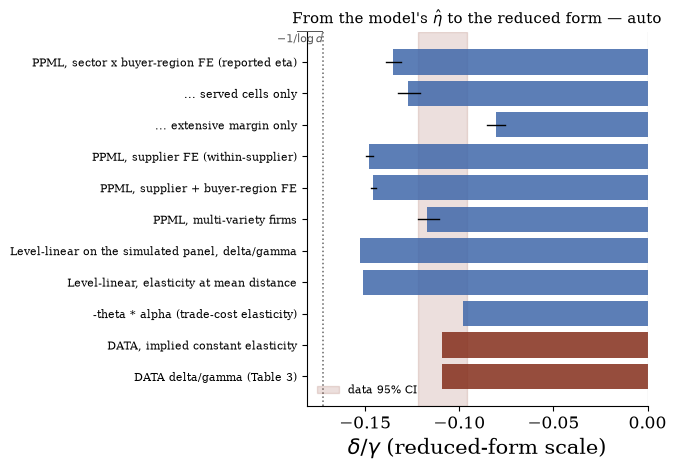

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  219,402 supplier x downstream-region cells, 12,189 suppliers, 40.7% zeros, from ../reporting_aero_profiled_aa_gran_nlo1_pso/step3/suppliers.parquet
  fixed effect                   eta       se    -> delta/gamma  (mean log d = 5.8)
  sector x buyer region      -0.7062   0.0656           -0.1386  [-0.1429, -0.1328]
  supplier (firm FE)         -1.3390   0.0455           -0.1527  [-0.1538, -0.1515]
  both                       -1.1717   0.0331           -0.1503  [-0.1513, -0.1492]
  DATA delta/gamma                                      -0.0980  [-0.1300, -0.0650]
                                           channel  coefficient       se  n_obs
                                       eta (total)    -0.706207 0.065626 219402
       eta_ext (extensive: probability of serving)    -0.322424 0.009302 219402
eta_int (intensive: portfolio share, served cells)    -0.457739 0.059896 130140
  eta - (eta_ext + eta_int) = +0.0740   (exactly zero only when the three fixed effects coincide)
[aero]

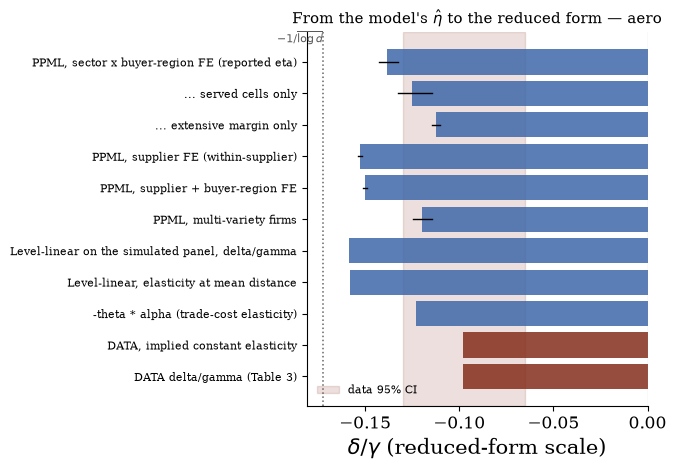

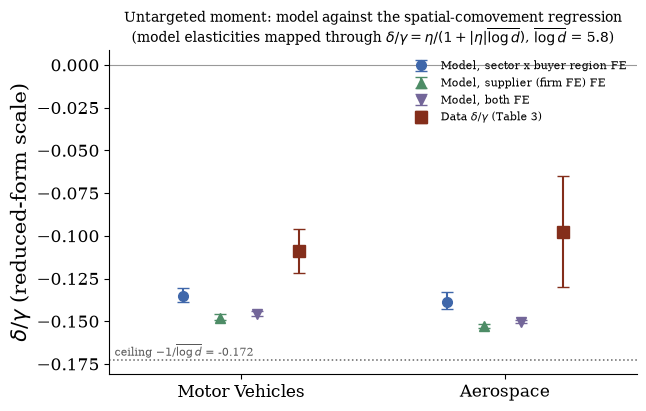

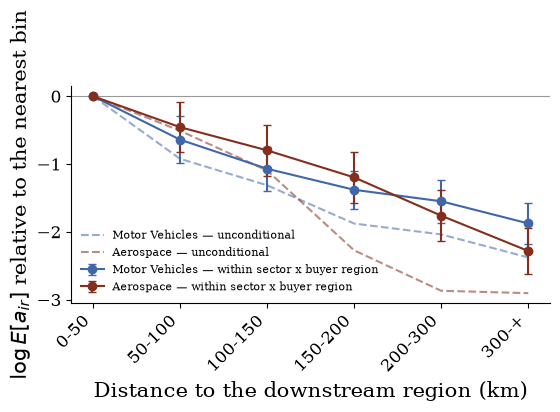

eta (model)        se  \
industry       fixed effect                                   
Motor Vehicles sector x buyer region    -0.629433  0.044468   
               supplier (firm FE)       -1.037156  0.044765   
               both                     -0.939246  0.032264   
Aerospace      sector x buyer region    -0.706207  0.065626   
               supplier (firm FE)       -1.338963  0.045535   
               both                     -1.171716  0.033094   

                                      delta/gamma (model)  \
industry       fixed effect                                 
Motor Vehicles sector x buyer region            -0.135341   
               supplier (firm FE)               -0.147838   
               both                             -0.145673   
Aerospace      sector x buyer region            -0.138581   
               supplier (firm FE)               -0.152745   
               both                             -0.150298   

                                     95% CI (model, delta/gamma)  \
industry       fixed effect                                        
Motor Vehicles sector x buyer region            [-0.139, -0.131]   
               supplier (firm FE)               [-0.149, -0.146]   
               both                             [-0.147, -0.144]   
Aerospace      sector x buyer region            [-0.143, -0.133]   
               supplier (firm FE)               [-0.154, -0.152]   
               both                             [-0.151, -0.149]   

                                      delta/gamma (data)     95% CI (data)  \
industry       fixed effect                                                  
Motor Vehicles sector x buyer region              -0.109  [-0.122, -0.096]   
               supplier (firm FE)                 -0.109  [-0.122, -0.096]   
               both                               -0.109  [-0.122, -0.096]   
Aerospace      sector x buyer region              -0.098  [-0.130, -0.065]   
               supplier (firm FE)                 -0.098  [-0.130, -0.065]   
               both                               -0.098  [-0.130, -0.065]   

                                      inside data CI  suppliers   cells  
industry       fixed effect                                              
Motor Vehicles sector x buyer region           False       4010   88220  
               supplier (firm FE)              False       4010   88220  
               both                            False       4010   88220  
Aerospace      sector x buyer region           False      12189  219402  
               supplier (firm FE)              False      12189  219402  
               both                            False      12189  219402

In [105]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
untargeted_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])

    # why the model's eta and the reduced-form delta/gamma differ, rung by rung
    ladder = untargeted_specification_ladder(data, panel=untargeted_results[-1]["panel"])
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))


## Untargeted moment — the supplier-count distribution beyond the zero

$G_s(K) = \Pr(K_{ls} \le K)$ is the share of commuting zones of sector $s$ hosting **at
most** $K$ active suppliers, and the estimation targets exactly one point of it: the
$K = 0$ row, $\bar G_s(0)$, which is moment block 6. That one point is what the variety
count $\hat N_s$ is calibrated on — a monotone integer bisection on
$\bar G_s(n) = \operatorname{mean}_l (1-q_{ls})^n$, one number per sector, and the outer
optimiser never sees it. **Every other point of the curve is then a prediction**, and
that is what this section reads.

The prediction is not vague. A cell $l$ hosts a supplier for a variety when it wins that
variety *somewhere* in the downstream industry, which happens with probability $q_{ls}$,
and varieties are independent draws, so

$$K_{ls} \sim \mathrm{Binomial}(N_s,\, q_{ls}), \qquad
G_s(K) \;=\; \operatorname{mean}_{l}\ \Pr\!\big(\mathrm{Bin}(N_s, q_{ls}) \le K\big).$$

The $q_{ls}$ come from the sourcing block — comparative advantage, trade costs, the
Ricardian competition — and the single free number $N_s$ is spent on $G_s(0)$. So the
*shape* of the count distribution above zero is a joint test of the win probabilities and
of the Binomial mechanism, with no parameter left to absorb a miss. Two sectors with the
same share of empty zones but different concentrations of $q$ have different $G_s(1)$,
$G_s(2)$, …, and only one of them can be right.

### Statistical secrecy: the data's $G_s(0)$ is not $\Pr(K=0)$

No statistic may be published on a commuting zone hosting fewer than **three** suppliers,
so those zones had their suppliers removed before `G_K.csv` was built. The observed count
is therefore censored,

$$K^{obs}_{ls} \;=\; \begin{cases} K_{ls} & K_{ls} \ge c\\ 0 & K_{ls} < c\end{cases}
\qquad c = 3,$$

and the reported curve is the curve of $K^{obs}$, not of $K$:

$$G^{obs}_s(K) \;=\; \Pr\big(K_{ls} \le \max(K,\, c-1)\big),$$

flat over $K = 0, 1, 2$ at the common value $\Pr(K_{ls} \le 2)$. That is exactly the
$G_s(1) = G_s(2) = G_s(0)$ pattern in the file.

**The model is put through the same transformation; the data are not un-censored.** The
censoring is not invertible — a reported zero is a zone with zero, one or two suppliers
and nothing in the file says which — so the only honest comparison maps the model into
the observation, `censor_min = COUNT_CENSOR_MIN` in the code. The model's censored curve
is $\hat G^{obs}_s(K) = \hat G_s(\max(K, c-1))$, which costs nothing: the dense curve is
computed anyway and is simply read at a shifted index.

Two consequences, and they are the reason this matters.

**The comparison at $K^*$ becomes like for like.** The data's first step is at $K^* = c$
by construction, and the increment there is $\Pr(K_{ls}=c)$ — the share of zones with
exactly three suppliers. The censored model returns $\hat G_s(c) - \hat G_s(c-1)$, the
same quantity. *Without* the transformation the model's increment is
$\Pr(1 \le K_{ls} \le c)$, which carries the one- and two-supplier zones the data were
forbidden to show, so the model would be over the data by construction — several times
over, since those are the most common non-empty zones.

**The targeted moment inherits the same problem, and this section measures it.** Block 6
matches the model's $\bar G_s(0) = \Pr(K_{ls}=0)$ against a target that is really
$\Pr(K_{ls} \le 2)$, so the criterion is implicitly asking the model to put the one- and
two-supplier zones at zero as well. Since $\Pr(K=0;N)$ is decreasing in $N$, matching a
target that is too large returns a variety count $\hat N_s$ that is too **small**. The
`censoring` table reports, per sector, the wedge $\Pr(1 \le K_{ls} \le 2)$ and the
variety count `N censored-consistent` the same bisection returns once the target is read
as $\Pr(K \le 2)$; the ratio to $\hat N_s$ is the size of the bias in the estimate. That
is a finding about the *estimation*, not about this section, and fixing it means changing
what block 6 computes on the Julia side — `gbar_sector` evaluated at $c-1$ rather than at
$0$.

### Which $K$, and why the increment rather than the level

Matching the *whole* curve is a great deal to ask of one calibrated number. The moment
taken here is the smallest departure from the point that was matched:

$$K^*_s \;=\; \min\{K > 0 \;:\; G_s(K) - G_s(0) \neq 0\},$$

**the first step of the curve** — the smallest number of suppliers any commuting zone of
the sector actually hosts — and the moment read there is the **increment**

$$\Delta G_s \;=\; G_s(K^*_s) - G_s(0),$$

not the level $G_s(K^*_s)$. Two reasons, and they are the whole design.

**The increment, because the level is half-matched.** $G_s(K^*)$ contains $G_s(0)$, which
the variety count was calibrated to reproduce; a model that hits the zero and then
predicts nothing at all would still look close in levels. Subtracting $G_s(0)$ leaves
exactly the part no parameter was pointed at: the mass the curve picks up on its first
rung. With the censoring applied to both sides that mass is
$\Pr(K_{ls} = K^*)$ — the share of zones hosting exactly $K^*$ suppliers — since the
censored curve is flat below $c$ and $K^* \ge c$. (On an uncensored dataset, `censor_min
= 1`, it would be $\Pr(1 \le K_{ls} \le K^*)$ on the model side against
$\Pr(K_{ls} = K^*)$ on the data side, and any mass the model puts on counts the data
never realise would show up in the gap.)

**The first step, because $K = 1$ is not usable and a deep quantile asks too much.** The
empirical curve is a step function over finitely many commuting zones, so the increment
$G_s(K) - G_s(K-1)$ can be exactly zero for a small $K$ out of granularity alone — and
under the censoring above it is zero for $K = 1, 2$ in *every* sector, by construction.
A moment placed at $K = 1$ would compare the model against an artefact of the disclosure
rule; the first step finds $K^* = 3$ on its own, without being told about $c$. Taking the first $K$ at which the curve *does* rise makes
that impossible by construction — the increment is nonzero in the data by the definition
of $K^*_s$ — while staying as close to the calibrated point as the data allow. It also
needs no arbitrary constant: nothing is chosen but "the next rung that exists".

The deeper reading is still available. `rule="median"` takes instead the smallest $K$ with
$G_s(K) - G_s(0) \ge \tfrac12 (1 - G_s(0))$ and $G_s(K) \neq G_s(K-1)$ — the median
supplier count among the zones that have at least one — which is self-normalising across
sectors and probes the middle of the distribution rather than its edge. It is the
robustness check; a sector whose curve is truncated before the halfway point returns no
$K^*$ under it, whereas the first step exists whenever any zone is non-empty.

Where the *censored* model curve first rises is reported beside the data's $K^*_s$. It is
$c$ whenever the model is censored like the data, which is the check that the
transformation is doing what it should; a data $K^*_s$ **above** $c$ means no zone of that
sector hosts exactly $c$ suppliers, and the moment is then read one rung further out on
both sides.

### The estimator, and why it is not $(1-\hat q)^n$

The model side is computed from the **win counts** $k_{ls}$ — how many of the $m$ simulated
varieties cell $l$ wins somewhere — exactly as the criterion computes block 6. Given
$k \sim \mathrm{Bin}(m, q)$, the unbiased estimator of $\Pr(\mathrm{Bin}(N,q) = j)$ is the
hypergeometric probability of drawing $j$ winners in a random subset of size $N$ of the $m$
draws,

$$\widehat{\Pr}(K_{ls} \le K) \;=\; \sum_{j=0}^{K}
\frac{\binom{k_{ls}}{j}\binom{m-k_{ls}}{N_s-j}}{\binom{m}{N_s}},$$

because a size-$N$ subset of $m$ i.i.d. draws carries a $\mathrm{Bin}(N,q)$ win count. At
$K=0$ this is $\binom{m-k}{N}/\binom{m}{N}$, which is `gbar_cell` verbatim — so the
$K = 0$ column of the model curve reproduces the fitted block-6 moment, and the section
checks that it does. The plug-in $\binom{N}{j}\hat q^{\,j}(1-\hat q)^{N-j}$ with
$\hat q = k/m$ is available for comparison and is reported as a diagnostic; it is biased,
and the bias is exactly the one that motivated the unbiased estimator on the targeted
moment in the first place.

### How to read the result

Two readings, both in the table below. The **direct** one is the gap
$\Delta \hat G_s - \Delta G_s$ between the model's first-step mass and the data's, in the
units of a share of commuting zones, next to the residual on the targeted $K=0$ moment
for scale — a gap of the same order as that residual is a model doing as well off the
target as on it. A **positive** gap means the model puts more zones on the first rung
than the data do, i.e. its count distribution is too concentrated just above zero.

The **normalised** one divides by the mass that was not matched at the zero:
$\Delta G_s/\big(1 - G_s(0)\big)$ is the share of the *non-empty* zones that sit on the
first rung, which removes the level of $G_s(0)$ from the comparison and so separates
"the model has the wrong number of empty zones" from "the model has the wrong shape among
the non-empty ones".

The third reading is a variety count. $\hat N_s$ was chosen so that the model's curve
passes through the data at $K = 0$; solving the same equation on the LEVEL $G_s(K^*_s)$
instead gives $N_s^{(K^*)}$, the variety count the sector would have been given had the
calibration been done one rung further up. (The inversion is on the level, not on the
increment: $\Pr(K_{ls} \le K)$ is monotone in $N_s$ and so has a unique solution, while
the increment $\Pr(1 \le K_{ls} \le K)$ is hump-shaped in $N_s$ and would not.) It is a second route to $N_s$ in the spirit of
the free over-identifying check $N^{\text{count}}_s = N^{\text{obs}}_s/\sum_l \hat q_{ls}$,
and the ratio $N_s^{(K^*)}/\hat N_s$ is the size of the miss expressed in the model's own
parameter rather than in shares.

In [106]:
# The supplier-count distribution beyond the zero. G_s(0) is moment block 6; every
# other point of the curve is a prediction of the win probabilities and of the Binomial
# variety mechanism, with no free parameter left to absorb a miss. See the markdown above
# for the K* selection rule and for the estimator.

COUNT_K_RULE = "first_step"   # where the untargeted point is read: the first rung
                              # of the curve above the targeted K = 0, or "median"
COUNT_HALF_MASS = 0.5         # the quantile "median" places K* at

# STATISTICAL SECRECY. The data may not report a statistic on a commuting zone hosting
# fewer than this many suppliers, so those zones had their suppliers removed and enter
# G_K.csv as zero-supplier zones. The empirical curve is therefore CENSORED:
#
#     K^obs_ls = K_ls  if  K_ls >= COUNT_CENSOR_MIN,   0 otherwise,
#
# which makes the reported G_s(0) equal Pr(K_ls <= COUNT_CENSOR_MIN - 1), NOT Pr(K = 0),
# and flattens the curve over K = 1 .. COUNT_CENSOR_MIN - 1. The model is put through
# the SAME transformation rather than the data being un-censored, since the censoring is
# part of how the data were observed and is not invertible. Set to 1 for uncensored data.
COUNT_CENSOR_MIN = 3


def read_count_cdf(data, path=None):
    """
    The EMPIRICAL supplier-count CDF G_s(K) = Pr(K_ls <= K), sector by sector.

    Read from the same `G_K.csv` the estimation reads, through the same
    case-insensitive column matching (`group, A129, G, K, N_supplier_s`; `G` is the
    value column). The loader keeps only the K = 0 row, which is the targeted moment;
    this reads the whole curve.

    The K grid is the UNION of the K values the file carries, and it is generally
    SPARSE: a sector's curve is reported at the supplier counts that sector actually
    realises, so the grid can run 0, 1, 2, ..., 12, 17, 34, 92 with most of it missing
    for most sectors. Nothing downstream may assume `K[j] == j`: `G[s, j]` is the value
    at `K[j]`, NaN where sector `s` has no row there, and the model curve is evaluated
    on this same grid rather than on every integer.

    Returns {"K": (nK,) integer grid starting at 0, "G": (S, nK) with NaN where a
    sector has no row for that K, "N_supplier_s": (S,), "sector_codes", "K_max"}.
    Rows are in the model's 1..S sector order (sorted A129), the loader's own.
    """
    path = Path(data["input_folder"]) / "G_K.csv" if path is None else Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found — G_s(K) is the granular count moment, so this section "
            "needs the same G_K.csv the estimation was run against.")
    G_K = pd.read_csv(path)
    c_sector = _gk_col(G_K, ("a129", "sector"))
    c_K = _gk_col(G_K, ("k",))
    c_G = _gk_col(G_K, ("g",))
    c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))

    codes = data.get("sector_codes")
    if codes is None:
        codes = sorted(G_K[c_sector].unique())
    S = len(codes)
    # A129 comes back from the CSV with whatever dtype pandas infers, while the codes
    # carried by `data` may be the loader's strings, so the row lookup is done on a
    # normalised key rather than on raw equality — the same int/float/str round trip
    # `_as_ze_string` guards against on the region codes.
    def _key(v):
        s = str(v).strip()
        return s[:-2] if s.endswith(".0") else s
    by_code = {k: sub for k, sub in G_K.groupby(G_K[c_sector].map(_key))}
    Ks = np.sort(G_K[c_K].astype(float).round().astype(int).unique())
    if Ks[0] != 0:
        raise ValueError(f"G_K.csv starts at K = {Ks[0]}; the K = 0 row is the targeted "
                         "moment and the curve is read relative to it.")

    G = np.full((S, Ks.size), np.nan)
    N_sup = np.full(S, np.nan)
    for s, code in enumerate(codes):
        sub = by_code.get(_key(code))
        if sub is None or sub.empty:
            continue
        kk = sub[c_K].astype(float).round().astype(int).to_numpy()
        vv = sub[c_G].astype(float).to_numpy()
        G[s, np.searchsorted(Ks, kk)] = vv
        N_sup[s] = float(pd.unique(sub[c_N])[0])

    # G is a CDF: non-decreasing in K and bounded by one. A violation is a data problem,
    # not something to silently clip, so it is reported and left in place.
    bad = np.nanmax(np.where(np.isnan(np.diff(G, axis=1)), 0.0,
                             -np.diff(G, axis=1)), initial=0.0)
    if bad > 1e-12:
        print(f"  warning: G_K.csv is not monotone in K (largest decrease {bad:.3g}) — "
              "G_s(K) = Pr(K_ls <= K) should never fall")
    n_sparse = int(Ks[-1]) + 1 - Ks.size
    if n_sparse:
        print(f"  G_K.csv reports {Ks.size} distinct K up to K = {Ks[-1]} "
              f"({n_sparse} integers absent from the grid): the curve is given at the "
              "supplier counts the data realise, so it is read on that support")
    return {"K": Ks, "G": G, "N_supplier_s": N_sup, "sector_codes": list(codes),
            "K_max": int(Ks[-1]), "path": path}


def select_untargeted_K(curve, sector_names=None, rule=COUNT_K_RULE,
                        half=COUNT_HALF_MASS, tol=1e-12, verbose=True):
    """
    K*_s and the increment read there.

    rule="first_step" (the default) — **the first step of the curve**: the smallest
        K > 0 at which G_s rises above G_s(0),

            K*_s = min { K > 0 : G_s(K) - G_s(0) != 0 },

        i.e. the smallest number of suppliers any commuting zone of the sector actually
        hosts. It is the point of the distribution CLOSEST to the one the estimation
        targets, which is what makes it the right first untargeted test: matching the
        whole curve asks a great deal of the single number `N_hat_s`, while the first
        step asks only whether the model gets the very next rung right.

        This is the earlier "sits on a step, not on a plateau" condition applied at the
        very first rung — the increment is nonzero by construction, so a sector's moment
        can never land on a flat step created by the granularity of the data.

    rule="median" — the smallest K > 0 with G_s(K) - G_s(0) >= half*(1 - G_s(0)) AND
        G_s(K) != G_s(K-1): the median supplier count among the zones with at least one.
        A deeper point of the same curve, kept as the robustness check; a sector whose
        curve is truncated before the halfway point returns no K*.

    Either rule reads the curve on the SECTOR'S OWN support — the K at which it is
    reported — not on the union grid, which is generally sparse: "the previous rung" is
    K-1 when the file gives every integer and the previous realised count when it gives
    only the counts that occur.

    The column that matters downstream is `dG_at_K = G_s(K*) - G_s(0)`, the mass the
    curve picks up between the targeted point and the first untargeted one. Under
    "first_step" the data's support has nothing between 0 and K*, so on the DATA side
    that increment is the share of zones hosting exactly K* suppliers; on the MODEL side
    it is Pr(1 <= K_ls <= K*), which is the same functional of the same curve and is
    what makes the two comparable — the model is not forbidden from putting mass where
    the data have none, and if it does, that shows up here as a gap.
    """
    if rule not in ("first_step", "median"):
        raise ValueError(f"rule must be 'first_step' or 'median', got {rule!r}")
    K, G = curve["K"], curve["G"]
    S = G.shape[0]
    names = sector_names if sector_names is not None else [str(s + 1) for s in range(S)]
    rows = []
    for s in range(S):
        g = G[s]
        g0 = g[0]
        if not np.isfinite(g0):
            rows.append({"sector": names[s], "G0": np.nan, "target": np.nan,
                         "K_star": -1, "G_at_K": np.nan, "status": "no K = 0 row"})
            continue
        target = g0 + (half * (1.0 - g0) if rule == "median" else 0.0)
        if g0 >= 1.0 - tol:
            rows.append({"sector": names[s], "G0": g0, "target": target, "K_star": -1,
                         "G_at_K": np.nan, "status": "degenerate: no non-empty cell"})
            continue
        hit = -1
        why = ("the curve never rises above G_s(0) within the observed K range"
               if rule == "first_step" else "not reached within the observed K range")
        avail = np.flatnonzero(np.isfinite(g))          # this sector's own support
        for a, j in enumerate(avail[1:], start=1):
            if K[j] <= 0:
                continue
            if rule == "first_step":
                ok = g[j] - g0 > tol
            else:
                ok = g[j] + tol >= target and abs(g[j] - g[avail[a - 1]]) > tol
            if ok:
                hit, why = int(K[j]), "ok"
                break
        rows.append({"sector": names[s], "G0": g0, "target": target, "K_star": hit,
                     "G_at_K": g[np.searchsorted(K, hit)] if hit >= 0 else np.nan,
                     "status": why})
    df = pd.DataFrame(rows).set_index("sector")
    df["dG_at_K"] = df["G_at_K"] - df["G0"]                     # THE untargeted moment
    df["frac_of_nonempty"] = df["dG_at_K"] / (1.0 - df["G0"])
    df["K_max_available"] = [int(K[np.flatnonzero(np.isfinite(G[s]))[-1]])
                             if np.isfinite(G[s]).any() else -1 for s in range(S)]
    df.attrs["rule"] = rule
    if verbose:
        n_ok = int((df["K_star"] > 0).sum())
        what = ("first realised supplier count" if rule == "first_step"
                else "median count among cells with at least one supplier")
        print(f"  K* selected for {n_ok}/{S} sectors ({what})")
        for name, r in df[df["status"] != "ok"].iterrows():
            print(f"    {name}: no untargeted K — {r['status']}"
                  + (f" (curve stops at K = {int(r['K_max_available'])}, "
                     f"G = {r['G0']:.3f} at K = 0"
                     + (f", halfway needs {r['target']:.3f})" if rule == "median" else ")")
                     if r["status"].startswith(("not reached", "the curve never")) else ""))
    return df


# ---------------------------------------------------------------------------------
# The model side: the count distribution implied by the simulated win counts and the
# calibrated variety count.
# ---------------------------------------------------------------------------------

def load_supplier_counts(data):
    """
    (k_ls, m): how many of the m simulated varieties cell (s, l) wins SOMEWHERE, and m.

    `main.jl`'s post-hoc block writes `suppliers.npy` — the (S, N_rho, R) boolean
    `linkages_flat` of the very solve that produced `suppliers.parquet` — into the step
    folder of the estimate, so `mu` selects it exactly as it selects the moments, the
    inference and the firm-level panel. Its variety-axis sum IS the `k_counts` that
    `concentrate_N_s` bisects on, and `m = N_rho` is the second axis.

    The counts are read rather than the diagnostics' `q_hat` because the unbiased
    estimator needs both k and m, and only q = k/m is recorded. The two describe the
    same object — `report_granular` and `write_post_hoc` both run at theta_hat_mu on
    U_DRAWS — which is why the q_hat fallback below is legitimate, and why it can only
    offer the plug-in estimator.

    Returns (k, m, path) with k of shape (S, R) and m an int, or (q, None, path) from
    the q_hat fallback.
    """
    path = Path(data["folder"]) / data["step_dir"] / "suppliers.npy"
    if path.exists():
        sup = np.load(path)
        if sup.ndim != 3 or sup.shape[0] != data["S"] or sup.shape[2] != data["R"]:
            raise ValueError(f"{path} is {sup.shape}, expected (S, N_rho, R) = "
                             f"({data['S']}, ., {data['R']})")
        return sup.sum(axis=1).astype(int), int(sup.shape[1]), path

    diag = data.get("granular_diagnostics")
    if diag is None or "q_hat" not in diag:
        raise FileNotFoundError(
            f"neither {path} nor a granular_diagnostics.npz with q_hat — main.jl writes "
            "suppliers.npy in its post-hoc block, next to suppliers.parquet.")
    # q_hat is enumerated over the n_good cells in Julia's `findall(CELL_MASK)` order,
    # which is column-major over (S, R): all sectors of region 1, then of region 2, ...
    q = np.zeros((data["S"], data["R"]))
    cells = np.argwhere(np.asarray(data["CELL_MASK"]).T)        # (r, s) pairs, in order
    qv = np.asarray(diag["q_hat"]).ravel()
    if cells.shape[0] != qv.size:
        raise ValueError(f"q_hat has {qv.size} entries but CELL_MASK has "
                         f"{cells.shape[0]} cells")
    q[cells[:, 1], cells[:, 0]] = qv
    print("  suppliers.npy absent — falling back to q_hat, so only the PLUG-IN "
          "estimator is available (m = N_rho is not recorded).")
    return q, None, path


def _log_factorials(m):
    """log n! for n = 0..m, the table `gbar_logfact_table` builds on the Julia side."""
    lg = np.zeros(int(m) + 1)
    lg[1:] = np.cumsum(np.log(np.arange(1, int(m) + 1, dtype=float)))
    return lg


def _log_binom(n, r, lg):
    """log C(n, r), -inf outside 0 <= r <= n. `n`, `r` broadcast to integer arrays."""
    n, r = np.broadcast_arrays(np.asarray(n, dtype=np.int64), np.asarray(r, dtype=np.int64))
    ok = (r >= 0) & (n >= 0) & (r <= n)
    nn, rr = np.where(ok, n, 0), np.where(ok, r, 0)
    out = np.full(n.shape, -np.inf)
    np.copyto(out, lg[nn] - lg[rr] - lg[nn - rr], where=ok)
    return out


def count_cdf_cells(k, m, N, K_max, estimator="unbiased"):
    """
    Pr(K_ls <= K) for K = 0..K_max, cell by cell, under K_ls ~ Binomial(N, q_ls).

    `k` is the win COUNT out of `m` simulated varieties. When `m is None`, `k` is read
    as the win PROBABILITY itself — all the q_hat fallback can supply, and then only the
    plug-in estimator is defined.

    estimator="unbiased"  the hypergeometric estimator
                          sum_{j<=K} C(k,j) C(m-k, N-j) / C(m, N).
                          A size-N subset of m i.i.d. draws has a Binomial(N, q) win
                          count, so each term is an unbiased estimator of the Binomial
                          pmf. At K = 0 it is exactly `gbar_cell`, the estimator the
                          criterion matches block 6 with.
    estimator="plugin"    C(N,j) qhat^j (1-qhat)^(N-j) with qhat = k/m. Biased, kept as
                          the diagnostic contrast that motivated the unbiased one.

    Returns (n_cells, K_max+1), non-decreasing along the second axis.
    """
    k = np.asarray(k, dtype=float).ravel()
    N, K_max = int(N), int(K_max)
    if N < 0 or K_max < 0:
        raise ValueError(f"N = {N}, K_max = {K_max}: both must be non-negative")

    if estimator == "plugin" or m is None:
        if estimator == "unbiased" and m is None:
            raise ValueError("the unbiased estimator needs the draw count m; only the "
                             "win probability is available here")
        q = k if m is None else k / float(m)
        lgN = _log_factorials(max(N, 1))
        pmf = np.empty((K_max + 1, q.size))
        with np.errstate(divide="ignore", invalid="ignore"):
            la = np.log(np.where(q > 0, q, 1.0))
            lb = np.log(np.where(q < 1, 1.0 - q, 1.0))
        for j in range(K_max + 1):
            p = np.exp(float(_log_binom(N, j, lgN)) + j * la + (N - j) * lb)
            p = np.where((q <= 0) & (j > 0), 0.0, p)
            p = np.where((q >= 1) & (N - j > 0), 0.0, p)
            pmf[j] = np.where(j <= N, p, 0.0)
    elif estimator == "unbiased":
        m = int(m)
        if N > m:
            raise ValueError(f"N = {N} exceeds the draw count m = {m}: the unbiased "
                             "estimator draws a size-N subset of the m varieties, so it "
                             "is undefined. Raise N_rho, or use estimator='plugin'.")
        ki = np.rint(k).astype(np.int64)
        lg = _log_factorials(m)
        log_denom = float(_log_binom(m, N, lg))
        pmf = np.empty((K_max + 1, ki.size))
        for j in range(K_max + 1):
            pmf[j] = np.exp(_log_binom(ki, j, lg) + _log_binom(m - ki, N - j, lg)
                            - log_denom)
    else:
        raise ValueError(f"estimator must be 'unbiased' or 'plugin', got {estimator!r}")
    return np.cumsum(pmf, axis=0).T


def model_count_cdf(data, K_grid, N_hat, counts=None, estimator="unbiased",
                    censor_min=COUNT_CENSOR_MIN):
    """
    Ghat_s(K) = mean over the cells of sector s of Pr(K_ls <= K), ON THE GIVEN K GRID,
    put through the DATA'S OWN CENSORING.

    `K_grid` is the grid of the empirical curve — generally sparse, see
    `read_count_cdf` — so the returned columns line up with `curve["G"]` column for
    column. An integer is accepted and read as `0..K_grid`, the dense case.

    `censor_min = c` reproduces statistical secrecy: a zone hosting fewer than `c`
    suppliers is reported as hosting none, so the observed count is `K` if `K >= c` and
    `0` otherwise, and the observed CDF is

        G^obs(K) = Pr(K_ls <= max(K, c - 1)),

    flat over `K = 0 .. c-1` at the value `Pr(K_ls <= c-1)`. The transformation is
    applied to the MODEL, not undone on the data: the censoring is part of how the data
    were observed and cannot be inverted — a reported zero is a zone with 0, 1 or 2
    suppliers and nothing says which. `censor_min = 1` leaves the curve untouched.

    The mean runs over CELL_MASK — the cells inside active attraction areas, empty ones
    included, since those ARE the K = 0 mass — which is the same denominator
    `CELLS_OF_SECTOR` gives the criterion and the same one G_K.csv uses.

    Returns (S, len(K_grid)) with NaN for a sector with no cell.
    """
    Kg = (np.arange(int(K_grid) + 1) if np.ndim(K_grid) == 0
          else np.asarray(K_grid, dtype=int))
    Kread = np.maximum(Kg, max(int(censor_min), 1) - 1)      # the censoring, exactly
    k, m, _ = load_supplier_counts(data) if counts is None else counts
    CELL = np.asarray(data["CELL_MASK"])
    S = data["S"]
    G = np.full((S, Kg.size), np.nan)
    for s in range(S):
        cells = CELL[s]
        if not cells.any() or not np.isfinite(N_hat[s]):
            continue
        dense = count_cdf_cells(k[s][cells], m, int(N_hat[s]), int(Kread.max()),
                                estimator=estimator).mean(axis=0)
        G[s] = dense[Kread]                   # read off the grid, never assume K[j] == j
    return G


def implied_variety_count(k_cells, m, target, K, n_lo=1, n_hi=None,
                          estimator="unbiased", censor_min=1):
    """
    The variety count N that makes mean_l Pr(K_ls <= K) equal `target`, by the same
    monotone integer bisection `concentrate_N_s` runs at K = 0.

    Pr(Bin(N,q) <= K) is decreasing in N at fixed K — more varieties, more chances to
    exceed K — so the bisection is the same one, and at K = 0 with `censor_min = 1` it
    reproduces `N_hat` exactly.

    `censor_min = c` answers the same question about the CENSORED curve, reading `K` as
    `max(K, c-1)`: called at `K = 0` it is the variety count the calibration would have
    produced had the target `G_s(0)` been understood as `Pr(K_ls <= c-1)`, which is what
    the data actually report. Returns (N, clamp) with clamp in {"none", "lo", "hi"}.
    """
    K = max(int(K), max(int(censor_min), 1) - 1)
    n_hi = int(m if m is not None else 1000) if n_hi is None else int(n_hi)
    if m is not None:
        n_hi = min(n_hi, int(m))
    n_lo = max(1, int(n_lo))
    if n_hi <= n_lo:
        return n_lo, "lo"

    def G(n):
        return float(count_cdf_cells(k_cells, m, n, K, estimator=estimator)[:, -1].mean())

    if G(n_lo) <= target:
        return n_lo, "lo"
    if G(n_hi) >= target:
        return n_hi, "hi"
    lo, hi = n_lo, n_hi
    while hi - lo > 1:
        mid = (lo + hi) // 2
        if G(mid) > target:
            lo = mid
        else:
            hi = mid
    return (lo if abs(G(lo) - target) <= abs(G(hi) - target) else hi), "none"


def untargeted_count_moment(data, estimator="unbiased", rule=COUNT_K_RULE,
                            half=COUNT_HALF_MASS, K_max=None, N_hat=None,
                            censor_min=COUNT_CENSOR_MIN, verbose=True):
    # `K_max` truncates the empirical grid; None keeps all of it.
    """
    The untargeted count moment: `G_s(K*) - G_s(0)`, the FIRST STEP of the supplier-count
    curve above the point the estimation targets, with the model put through the data's
    own STATISTICAL-SECRECY CENSORING (`censor_min`, see the constant).

    The level `G_s(0)` is block 6 and `N_hat_s` is calibrated on it; the increment at the
    next rung the data realise is the nearest thing to it that nothing was fitted to. It
    is reported as an increment rather than as a level precisely because the level still
    contains the matched part: subtracting `G_s(0)` leaves only what the model predicted
    on its own.

    Under censoring the two sides finally measure the same thing. The data's first step
    is at `K* = c` (the curve is flat below it by construction), and there
    `G_s(c) - G_s(0) = Pr(K_ls = c)` — the share of zones with exactly `c` suppliers.
    The censored model gives `Ghat_s(c) - Ghat_s(c-1)`, the same quantity. Without the
    transformation the model's increment would be `Pr(1 <= K_ls <= c)`, which carries the
    zones with one or two suppliers that the data were not allowed to show, and the
    comparison would be biased upward for the model by construction.

    `N_hat` defaults to the calibrated variety count recorded in
    `granular_diagnostics.npz` at theta_hat_mu; the same bisection is re-run here on the
    win counts and the two are compared, which checks at once that the counts, the cell
    set and the estimator are the ones the criterion used.

    Returns a dict with `table` (one row per sector), the empirical and model curves,
    and the diagnostics needed to read them.
    """
    curve = read_count_cdf(data)
    if K_max is not None:                       # truncate the grid, keeping K = 0
        keep = curve["K"] <= int(K_max)
        curve = dict(curve, K=curve["K"][keep], G=curve["G"][:, keep],
                     K_max=int(curve["K"][keep][-1]))
    names = data["sector_names"]
    sel = select_untargeted_K(curve, sector_names=names, rule=rule, half=half,
                              verbose=verbose)
    k, m, counts_path = load_supplier_counts(data)
    if m is None and estimator != "plugin":
        # the q_hat fallback records k/m without m, and the subset estimator needs both
        estimator = "plugin"
    CELL = np.asarray(data["CELL_MASK"])
    S = data["S"]
    Kg = curve["K"]                             # the empirical grid, possibly sparse

    # The variety count the model was calibrated with, and the same bisection re-run
    # here. N_LO is the model's bound ceil(N_obs / R_d); a run with --relax_n_lo=true
    # used 1 instead, which is why a disagreement is reported rather than asserted.
    diag = data.get("granular_diagnostics") or {}
    N_rec = np.asarray(diag["N_hat"]).ravel().astype(float) if "N_hat" in diag \
        else np.full(S, np.nan)
    N_sup = np.asarray(curve["N_supplier_s"], float)
    n_lo_model = np.where(np.isfinite(N_sup), np.ceil(N_sup / data["n_AA"]), 1)

    # Two inversions of the SAME K = 0 target, differing only in what the target is
    # taken to mean. `N_own` reads it as Pr(K = 0), which is what the criterion does, so
    # it must reproduce the recorded N_hat. `N_cens` reads it as Pr(K <= c-1), which is
    # what the data actually report, so it is the variety count a censoring-consistent
    # calibration would have returned. The gap between them is the bias the censoring
    # puts into the ESTIMATE, not just into this comparison.
    N_own, clamp_own = np.full(S, np.nan), [""] * S
    N_cens, clamp_cens = np.full(S, np.nan), [""] * S
    for s in range(S):
        cells = CELL[s]
        if not cells.any() or not np.isfinite(curve["G"][s, 0]):
            continue
        kw = dict(n_lo=int(n_lo_model[s]), estimator=estimator,
                  n_hi=None if not np.isfinite(N_sup[s]) else int(N_sup[s]))
        N_own[s], clamp_own[s] = implied_variety_count(
            k[s][cells], m, curve["G"][s, 0], 0, censor_min=1, **kw)
        N_cens[s], clamp_cens[s] = implied_variety_count(
            k[s][cells], m, curve["G"][s, 0], 0, censor_min=censor_min, **kw)
    N_use = np.where(np.isfinite(N_rec), N_rec, N_own) if N_hat is None \
        else np.asarray(N_hat, float)

    G_model = model_count_cdf(data, Kg, N_use, counts=(k, m, counts_path),
                              estimator=estimator, censor_min=censor_min)
    G_raw = model_count_cdf(data, Kg, N_use, counts=(k, m, counts_path),
                            estimator=estimator, censor_min=1)
    G_plug = model_count_cdf(data, Kg, N_use, counts=(k, m, counts_path),
                             estimator="plugin",
                             censor_min=censor_min) if m is not None else G_model

    # the model's own K*, by the same rule applied to its own curve
    sel_model = select_untargeted_K({"K": Kg, "G": G_model}, sector_names=names,
                                    rule=rule, half=half, verbose=False)

    rows = []
    for s in range(S):
        Ks = int(sel["K_star"].iloc[s])
        j = int(np.searchsorted(Kg, Ks)) if Ks >= 0 else -1
        g_emp = curve["G"][s, j] if j >= 0 else np.nan
        g_mod = G_model[s, j] if j >= 0 else np.nan
        g0_emp, g0_mod = curve["G"][s, 0], G_model[s, 0]
        cells = CELL[s]
        if Ks > 0 and cells.any() and np.isfinite(g_emp):
            N_star, clamp_star = implied_variety_count(
                k[s][cells], m, g_emp, Ks, n_lo=1,
                n_hi=None if not np.isfinite(N_sup[s]) else int(N_sup[s]),
                estimator=estimator, censor_min=censor_min)
        else:
            N_star, clamp_star = np.nan, ""
        dg_emp, dg_mod = g_emp - g0_emp, g_mod - g0_mod
        rows.append({
            "sector": names[s],
            "K*": Ks if Ks > 0 else np.nan,
            # the TARGETED point, for scale
            "G_s(0) data": g0_emp, "G_s(0) model": g0_mod,
            "residual at K=0": g0_mod - g0_emp,
            # the UNTARGETED moment: the first step of the curve above it
            "dG data": dg_emp, "dG model": dg_mod, "gap": dg_mod - dg_emp,
            # the same, as a share of the mass that was NOT matched at K = 0
            "dG/(1-G0) data": dg_emp / (1 - g0_emp) if np.isfinite(dg_emp) else np.nan,
            "dG/(1-G0) model": dg_mod / (1 - g0_mod) if np.isfinite(dg_mod) else np.nan,
            # where the CENSORED model curve first rises. Under censoring it must be
            # c, since the curve is flat below it by construction; a data K* above c
            # means no zone in the sector hosts exactly c suppliers.
            "K* (model)": (int(sel_model["K_star"].iloc[s])
                           if sel_model["K_star"].iloc[s] > 0 else np.nan),
            "N_hat (from K=0)": N_use[s],
            "N implied by G_s(K*)": N_star,
            "N ratio": N_star / N_use[s] if (np.isfinite(N_star) and N_use[s]) else np.nan,
            "N clamp": clamp_star,
            "status": sel["status"].iloc[s],
        })
    table = pd.DataFrame(rows).set_index("sector")

    # What the censoring does to the TARGETED moment, sector by sector. The criterion
    # matches Pr(K = 0) to a number that is really Pr(K <= c-1), so it asks the model to
    # place at zero the zones with 1..c-1 suppliers as well; `N censored` is what the
    # same bisection returns once the target is read correctly.
    censoring = pd.DataFrame({
        "sector": names,
        "G_s(0) data (= Pr(K <= %d))" % (censor_min - 1): curve["G"][:, 0],
        "Pr(K = 0) model": G_raw[:, 0],
        "Pr(K <= %d) model" % (censor_min - 1): G_model[:, 0],
        "wedge Pr(1 <= K <= %d)" % (censor_min - 1): G_model[:, 0] - G_raw[:, 0],
        "N_hat (as estimated)": N_use,
        "N censored-consistent": N_cens,
        "N ratio": np.where(N_use > 0, N_cens / N_use, np.nan),
        "N clamp": clamp_cens,
    }).set_index("sector")

    out = {"industry": data["industry"], "mu": data["mu"], "table": table, "rule": rule,
           "K": Kg, "G_emp": curve["G"], "G_model": G_model,
           "G_model_uncensored": G_raw, "censoring": censoring,
           "censor_min": int(censor_min),
           "G_model_plugin": G_plug, "N_hat": N_use, "N_hat_recomputed": N_own,
           "N_hat_recorded": N_rec, "clamp_recomputed": clamp_own,
           "N_censored": N_cens, "clamp_censored": clamp_cens,
           "m": m, "estimator": estimator, "selection": sel,
           "counts_path": counts_path, "sector_names": names, "curve": curve}

    if verbose:
        # The K = 0 column of the model curve IS block 6, computed here from the counts
        # rather than read off the moment vector, so it is the one thing that can be
        # checked against the criterion's own output.
        sim_G0 = data.get("simulated_moments_dict", {}).get("G0")
        if sim_G0 is not None and m is not None:
            d0 = np.nanmax(np.abs(G_raw[:, 0] - np.asarray(sim_G0, float)))
            print(f"  check: |Pr(K = 0) here - block 6 of the fitted moment vector| "
                  f"<= {d0:.2e}   (the UNCENSORED K = 0 column is block 6)")
        if np.isfinite(N_rec).any():
            dN = np.nanmax(np.abs(N_own - N_rec))
            print(f"  check: the bisection re-run here reproduces the recorded N_hat to "
                  f"{dN:.0f} varieties" + ("" if dN <= 0 else
                  "  (a gap points at different N_LO bounds — see --relax_n_lo)"))
        print(f"  {data['industry']}: m = {m} varieties per cell, counts from "
              f"{counts_path.name if hasattr(counts_path, 'name') else counts_path}, "
              f"estimator = {estimator}, K grid = {Kg.size} points up to {Kg[-1]}")
        if censor_min > 1:
            w = np.nanmean(censoring[f"wedge Pr(1 <= K <= {censor_min - 1})"].to_numpy())
            r = np.nanmean(censoring["N ratio"].to_numpy())
            print(f"  CENSORING at {censor_min}: the data's G_s(0) is Pr(K <= "
                  f"{censor_min - 1}), while block 6 matches Pr(K = 0). Mean wedge "
                  f"{w:.4f} of cells; a censoring-consistent calibration would give "
                  f"N_s about {r:.2f}x the estimated one (see `censoring`).")
        big = table["K*"] > N_use
        if big.any():
            print("  note: K* exceeds N_hat_s in "
                  f"{list(table.index[big.fillna(False)])} — the model cannot put any "
                  "mass above its own variety count, so Ghat_s(K*) is 1 there by "
                  "construction and the implied N clamps. That IS the finding: the data "
                  "report more suppliers in a zone than the model has varieties.")
        print(table.round(4).to_string())
        ok = table["K*"].notna()
        if ok.any():
            print(f"  mean |gap| on the untargeted first step: "
                  f"{table.loc[ok, 'gap'].abs().mean():.4f}   against "
                  f"{table.loc[ok, 'residual at K=0'].abs().mean():.4f} on the TARGETED "
                  "K = 0 moment")
            over = int((table.loc[ok, "gap"] > 0).sum())
            print(f"  the model puts MORE mass on the first step than the data in "
                  f"{over}/{int(ok.sum())} sectors")
    return out


def untargeted_count_summary(results):
    """One table for every industry: the per-sector rows, indexed by (industry, sector)."""
    frames = []
    for r in results:
        name = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {}).get(
            "display_name", r["industry"])
        f = r["table"].copy()
        f["industry"] = name
        frames.append(f.reset_index().set_index(["industry", "sector"]))
    return pd.concat(frames)


def plot_count_cdf(res, ncols=4, sectors=None, x_max=None, show_uncensored=True,
                   figsize=None, save_to=None):
    """
    The whole curve, sector by sector: data against model, with the targeted point and
    the untargeted one marked.

    K = 0 is a filled marker — the model was calibrated to pass through it — and K* an
    open one, with the RISE from G_s(0) to G_s(K*) drawn as a vertical bar in each
    series: that rise is the untargeted moment, and the difference between the two bars
    is the gap the table reports.

    Only the K at which a sector's curve is REPORTED are drawn (the grid is sparse and
    sector-specific), and the x axis is cut a little beyond the largest K* so the
    picture stays on the part of the support the moment is read at; `x_max` overrides,
    and `x_max=np.inf` shows the whole grid.

    The model curve is the CENSORED one, so it is flat below `censor_min` exactly as the
    data are. `show_uncensored` adds the raw model curve as a faint line: the vertical
    distance between the two at K = 0 is the mass in zones with 1..c-1 suppliers, which
    the data were not allowed to report and which the criterion is nonetheless matching
    against Pr(K = 0).
    """
    K, G_emp, G_mod = np.asarray(res["K"]), res["G_emp"], res["G_model"]
    names = res["sector_names"]
    idx = list(range(len(names))) if sectors is None else list(sectors)
    if x_max is None:
        ks = res["table"]["K*"].to_numpy(float)
        x_max = (2.0 * np.nanmax(ks) + 1.0) if np.isfinite(ks).any() else K[-1]
    x_max = min(float(x_max), float(K[-1]))
    ncols = min(ncols, max(1, len(idx)))
    nrows = int(np.ceil(len(idx) / ncols))
    fig, axes = plt.subplots(nrows, ncols, sharex=True, sharey=True, squeeze=False,
                             figsize=figsize or get_figsize(wf=1.0,
                                                            hf=0.38 * nrows + 0.10))
    for ax, s in zip(axes.ravel(), idx):
        ok = np.isfinite(G_emp[s])                 # this sector's own support
        ax.step(K[ok], G_emp[s][ok], where="post", color=toulouse_color, linewidth=1.4,
                marker="o", markersize=2.5, label="Data")
        okm = np.isfinite(G_mod[s])
        ax.step(K[okm], G_mod[s][okm], where="post", color=sim_color, linewidth=1.4,
                linestyle="--", label="Model")
        G_raw = res.get("G_model_uncensored")
        if show_uncensored and G_raw is not None and res.get("censor_min", 1) > 1:
            okr = np.isfinite(G_raw[s])
            ax.step(K[okr], G_raw[s][okr], where="post", color=sim_color, linewidth=1.0,
                    linestyle=":", alpha=0.5, label="Model, uncensored")
        if ok.any():
            ax.plot([K[ok][0]], [G_emp[s][ok][0]], "o", color=toulouse_color, markersize=6)
        if okm.any():
            ax.plot([K[okm][0]], [G_mod[s][okm][0]], "D", color=sim_color, markersize=5)
        Ks = res["table"]["K*"].iloc[s]
        if np.isfinite(Ks):
            j = int(np.searchsorted(K, int(Ks)))
            ax.axvline(int(Ks), color="0.6", linestyle=":", linewidth=1.0)
            # the moment is the RISE from G_s(0) to G_s(K*), so draw it as a rise
            ax.vlines(int(Ks), G_emp[s, 0], G_emp[s, j], color=toulouse_color,
                      linewidth=2.5, alpha=0.55)
            ax.vlines(int(Ks) + 0.12, G_mod[s, 0], G_mod[s, j], color=sim_color,
                      linewidth=2.5, alpha=0.55)
            ax.plot([int(Ks)], [G_emp[s, j]], "o", mfc="none", color=toulouse_color,
                    markersize=8)
            ax.plot([int(Ks)], [G_mod[s, j]], "D", mfc="none", color=sim_color,
                    markersize=7)
        ax.set_title(f"{names[s]}" + (f"  $K^*={int(Ks)}$" if np.isfinite(Ks) else ""),
                     fontsize=font_size - 4)
        ax.set_ylim(0, 1.02)
        ax.set_xlim(-0.5, max(x_max, 1.0))
        _despine(ax)
    for ax in axes.ravel()[len(idx):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel("$K$")
    for ax in axes[:, 0]:
        ax.set_ylabel("$G_s(K)$")
    handles, labels_ = axes[0, 0].get_legend_handles_labels()
    n_leg = min(len(handles), 3)
    fig.legend(handles[:n_leg], labels_[:n_leg], frameon=False, fontsize=font_size - 4,
               ncol=n_leg, loc="lower center", bbox_to_anchor=(0.5, -0.04))
    c = res.get("censor_min", 1)
    fig.suptitle("Supplier-count distribution: $K=0$ is targeted, the rest is prediction"
                 + (f"\n(model censored at {c}, as the data are)" if c > 1 else ""),
                 fontsize=font_size)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def plot_untargeted_count(res, ax=None, save_to=None, annotate_K=True, level=False):
    """
    The untargeted moment itself: the INCREMENT `G_s(K*) - G_s(0)` in the data against
    the same increment in the model, one pair per sector, drawn like the targeted
    block-6 figure so the two read together.

    The increment and not the level, because the level still contains `G_s(0)`, which is
    what the estimation matched: subtracting it leaves only the part the model predicted
    on its own. `level=True` plots `G_s(K*)` instead, for the reader who wants to see
    the matched part carried along.

    No error bars: the bootstrap covariance on disk covers the K = 0 block only, so a
    bar here would have to be invented. The residual on the TARGETED moment is printed
    beside the table for the scale a bar would have provided.
    """
    tab = res["table"]
    keep = tab["K*"].notna().to_numpy()
    if not keep.any():
        raise ValueError("no sector has an untargeted K* — no curve in G_K.csv rises "
                         "above its own G_s(0) within the K range provided")
    labels = [f"{n}" for n in tab.index[keep]]
    if level:
        emp = (tab.loc[keep, "dG data"] + tab.loc[keep, "G_s(0) data"]).to_numpy(float)
        sim = (tab.loc[keep, "dG model"] + tab.loc[keep, "G_s(0) model"]).to_numpy(float)
        ylab = r"$G_s(K^*)$"
    else:
        emp = tab.loc[keep, "dG data"].to_numpy(float)
        sim = tab.loc[keep, "dG model"].to_numpy(float)
        ylab = r"$G_s(K^*) - G_s(0)$"

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, labels, emp, sim, None, None,
                     ylabel=ylab, xlabel="Sector (A129)", rotate=45)
    if annotate_K:
        lo, top = ax.get_ylim()
        ax.set_ylim(lo, top + 0.22 * (top - lo))       # headroom first, labels after
        for i, ks in enumerate(tab.loc[keep, "K*"]):
            ax.text(i, top, rf"$K^*={int(ks)}$", ha="center", va="bottom",
                    fontsize=font_size - 5, rotation=45)
    what = ("first step of the supplier-count curve" if res.get("rule") == "first_step"
            else "median non-empty supplier count")
    ax.set_title(f"Untargeted: the {what} — {res['industry']}", fontsize=font_size,
                 pad=14)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, bbox_inches="tight")
    return ax

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  G_K.csv reports 27 distinct K up to K = 92 (66 integers absent from the grid): the curve is given at the supplier counts the data realise, so it is read on that support
  K* selected for 10/10 sectors (first realised supplier count)
  check: |Ghat_s(0) here - block 6 of the fitted moment vector| <= 1.33e-15
  check: the bisection re-run here reproduces the recorded N_hat to 0 varieties
  auto: m = 293 varieties per cell, counts from suppliers.npy, estimator = unbiased, K grid = 27 points up to 92
        K*  G_s(0) data  G_s(0) model  residual at K=0  dG data  dG model     gap  dG/(1-G0) data  dG/(1-G0) model  K* (model)  N_hat (from K=0)  N implied by G_s(K*)  N ratio N clamp status
sector                                                                                                                                                                                        
C22A     1       0.7699        0.7686          -0.0013   0.1504    0.1885  0.0381          0.6538           0.8146

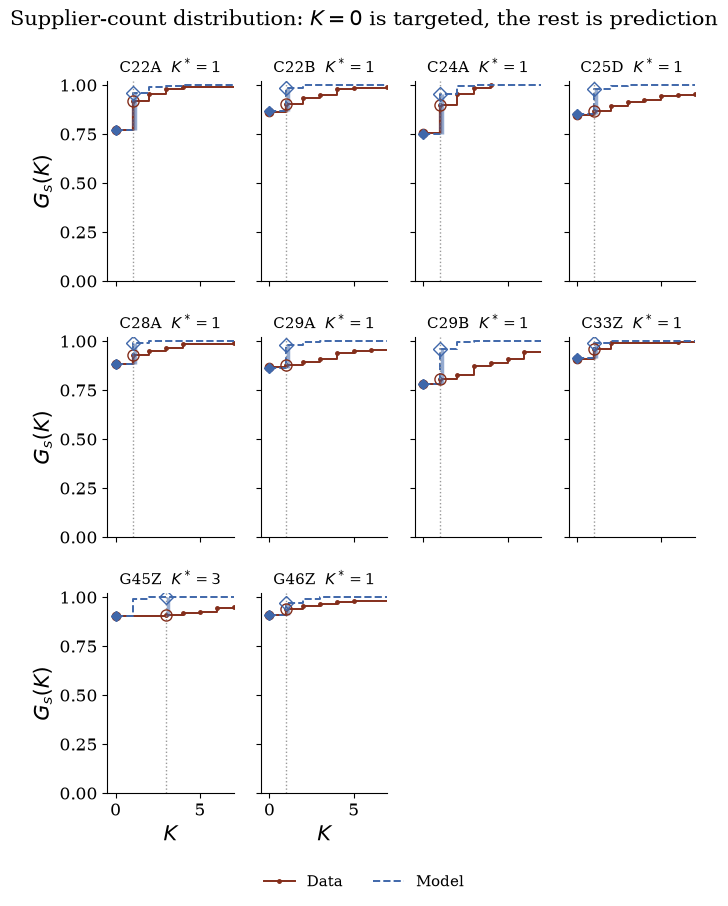

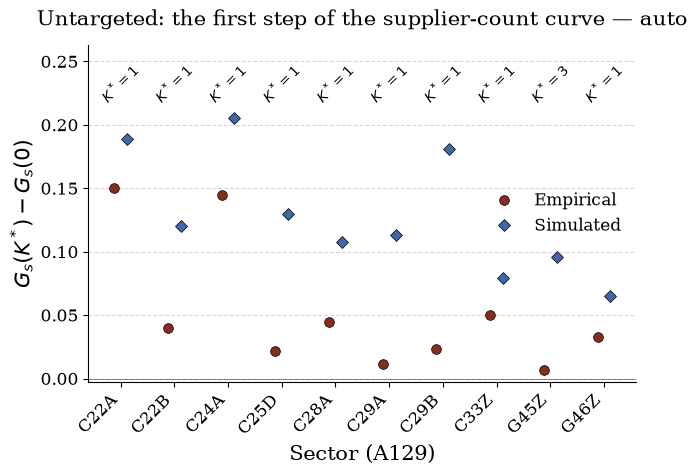

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


  G_K.csv reports 42 distinct K up to K = 248 (207 integers absent from the grid): the curve is given at the supplier counts the data realise, so it is read on that support
  K* selected for 10/10 sectors (first realised supplier count)
  check: |Ghat_s(0) here - block 6 of the fitted moment vector| <= 6.66e-16
  check: the bisection re-run here reproduces the recorded N_hat to 30 varieties  (a gap points at different N_LO bounds — see --relax_n_lo)
  aero: m = 723 varieties per cell, counts from suppliers.npy, estimator = unbiased, K grid = 42 points up to 248
  note: K* exceeds N_hat_s in ['M71Z'] — the model cannot put any mass above its own variety count, so Ghat_s(K*) is 1 there by construction and the implied N clamps. That IS the finding: the data report more suppliers in a zone than the model has varieties.
        K*  G_s(0) data  G_s(0) model  residual at K=0  dG data  dG model     gap  dG/(1-G0) data  dG/(1-G0) model  K* (model)  N_hat (from K=0)  N implied by G_s(K*)  N rat

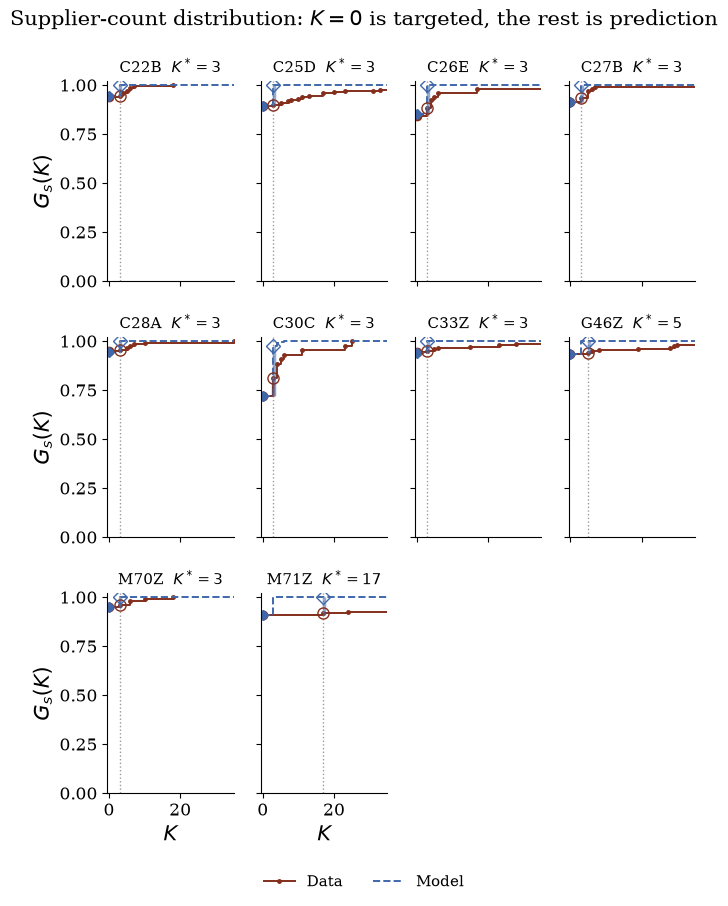

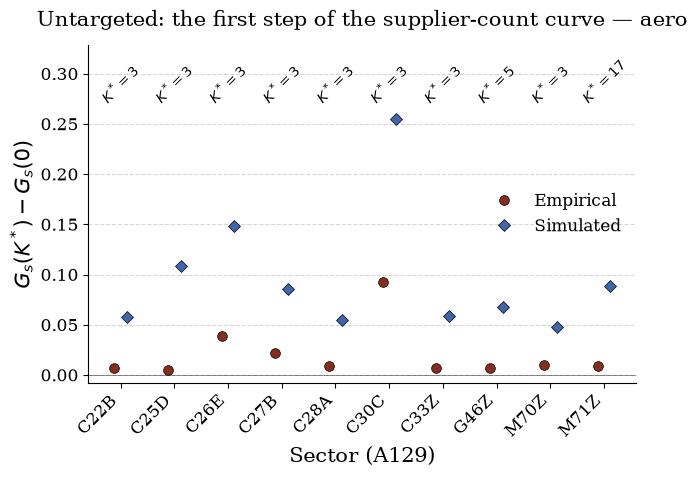

K*  G_s(0) data  G_s(0) model  residual at K=0  \
industry       sector                                                   
Motor Vehicles C22A     1     0.769912      0.768570        -0.001341   
               C22B     1     0.865000      0.865368         0.000368   
               C24A     1     0.753623      0.749705        -0.003918   
               C25D     1     0.847826      0.850610         0.002784   
               C28A     1     0.882682      0.882697         0.000016   
               C29A     1     0.866279      0.864825        -0.001454   
               C29B     1     0.781250      0.781316         0.000066   
               C33Z     1     0.910448      0.911608         0.001160   
               G45Z     3     0.902778      0.903788         0.001010   
               G46Z     1     0.907895      0.907177        -0.000718   
Aerospace      C22B     3     0.937063      0.942318         0.005255   
               C25D     3     0.893519      0.891451        -0.002068   
               C26E     3     0.843137      0.851452         0.008315   
               C27B     3     0.913978      0.914766         0.000788   
               C28A     3     0.948276      0.945397        -0.002879   
               C30C     3     0.720930      0.718370        -0.002561   
               C33Z     3     0.943262      0.940819        -0.002444   
               G46Z     5     0.933775      0.932364        -0.001411   
               M70Z     3     0.948980      0.952187         0.003207   
               M71Z    17     0.908257      0.911201         0.002944   

                        dG data  dG model       gap  dG/(1-G0) data  \
industry       sector                                                 
Motor Vehicles C22A    0.150442  0.188525  0.038083        0.653846   
               C22B    0.040000  0.120165  0.080165        0.296296   
               C24A    0.144928  0.205259  0.060331        0.588235   
               C25D    0.021739  0.129725  0.107986        0.142857   
               C28A    0.044693  0.107672  0.062979        0.380952   
               C29A    0.011628  0.112990  0.101362        0.086957   
               C29B    0.023438  0.180857  0.157420        0.107143   
               C33Z    0.049751  0.079469  0.029718        0.555556   
               G45Z    0.006944  0.096150  0.089206        0.071429   
               G46Z    0.032895  0.065408  0.032514        0.357143   
Aerospace      C22B    0.006993  0.057679  0.050686        0.111111   
               C25D    0.004630  0.108391  0.103761        0.043478   
               C26E    0.039216  0.148363  0.109147        0.250000   
               C27B    0.021505  0.085224  0.063718        0.250000   
               C28A    0.008621  0.054568  0.045947        0.166667   
               C30C    0.093023  0.255090  0.162067        0.333333   
               C33Z    0.007092  0.059180  0.052088        0.125000   
               G46Z    0.006623  0.067636  0.061013        0.100000   
               M70Z    0.010204  0.047813  0.037609        0.200000   
               M71Z    0.009174  0.088799  0.079625        0.100000   

                       dG/(1-G0) model  K* (model)  N_hat (from K=0)  \
industry       sector                                                  
Motor Vehicles C22A           0.814611           1              24.0   
               C22B           0.892545           1              21.0   
               C24A           0.820067           1              15.0   
               C25D           0.868366           1              23.0   
               C28A           0.917896           1              17.0   
               C29A           0.835882           1              19.0   
               C29B           0.827027           1              23.0   
               C33Z           0.899052           1              15.0   
               G45Z           0.999353           1              12.0   
               G46Z           0.704659           1           

In [107]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
untargeted_count_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    res = untargeted_count_moment(data)
    untargeted_count_results.append(res)

    plot_count_cdf(res, save_to=f"{out_folder}/untargeted_count_cdf_{industry}_mu{MU}.pdf")
    plt.show()
    plot_untargeted_count(res,
                          save_to=f"{out_folder}/untargeted_count_{industry}_mu{MU}.pdf")
    plt.show()

display(untargeted_count_summary(untargeted_count_results))

# What statistical secrecy does to the TARGETED moment: the criterion matches Pr(K = 0)
# against a number that is really Pr(K <= COUNT_CENSOR_MIN - 1).
for res in untargeted_count_results:
    print(f"\n[{res['industry']}] censoring at {res['censor_min']}")
    display(res["censoring"].round(4))

# Comparative advantage against distance, within a sector

Inside a sector, competition for a given downstream buyer is between **cells**, and a
cell is a (sector, *region*) pair — not an attraction area. Comparative advantage is what
is constant within an area: every region of area $a$ shares $T_{as}$, but each has its own
distance to each buyer. With Fréchet productivity and wages normalised to one, the
Ricardian competition has a closed form over cells,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

**The comparison is between two regions, not between two areas.** Region $r''$ beats
region $r'$ at buyer $r$ iff

$$\theta\alpha\big(\log d_{r'r} - \log d_{r''r}\big) \;<\; \log T_{a(r'')} - \log T_{a(r')},$$

with the distances measured *from each competing region* to the buyer and the comparative
advantages taken at the area each belongs to. Two things follow that an area-level reading
would miss:

1. when $a(r') = a(r'')$ the right-hand side is exactly zero, so **within an area
   competition is pure distance**. This is the variation that identifies $\alpha$, and it
   is invisible to any statement written in terms of area-level distances;
2. an area's edge does not protect *all* of its regions. It buys a distance handicap that
   each of its regions has to pay for out of its own location.

The section is written cell-by-cell throughout, so the only line that changes on the day
regions are allowed their own $T_{ls}$ deviating from their area's is the one that reads
$T_{a(l)s}$ off the area — nothing downstream assumes comparative advantage is constant
within an area.

**How the section proceeds.** Six tests, each in its own pair of cells (definitions, then
a run cell), building on one another:

| | question | answer |
|---|---|---|
| 1 | How unequal is comparative advantage inside a sector? | the spread of $\hat T$ across areas |
| 2 | What is that inequality worth in distance? | $\Delta \log \hat T / (\theta\hat\alpha)$, against the distances the geography offers |
| 3 | Does the favoured area actually win? | the exact comparison, buyer by buyer, region by region |
| 4 | Which of the two forces disperses the competition more? | the variance decomposition of $\log \psi$ |
| 5 | Is its covariance term telling us about the economy or about the estimator? | the Sinkhorn split of $\operatorname{Cov}(\log \hat T, \log d)$ |
| 6 | What would sourcing look like with one force switched off? | closed-form counterfactuals |

Test 1 is descriptive, 2 turns it into a distance, 3 replaces the average with the exact
statement, 4–5 ask which force does the work and whether the answer is contaminated by how
$\hat T$ was obtained, and 6 puts the two against each other in the allocation itself. A
seventh cell collects everything into one table, with a glossary.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient. Regional wages are
normalised to one in this calibration, which is why they do not appear in $\psi$.


In [108]:
# The geometry: the estimated T and alpha, and the closed-form win probabilities.
#
# Everything is computed CELL by CELL — a cell is a (sector, region) pair. Comparative
# advantage is read off the cell's attraction area, `T[s, aa_of_ze[l]]`, which is the one
# line to change the day regions are allowed a T of their own; distance is always the
# region's own distance to the buyer.

def model_theta(data):
    """Frechet shape parameter: from stats.csv when it carries one, else THETA_DEFAULT.

    Every theta*alpha-scaled quantity below — the distance equivalence, the variance
    decomposition, the win probabilities — moves with it.
    """
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are built
    from, per sector, over CELLS l = regions.

    `alpha=0` switches the distance force off, `equalise_T=True` switches comparative
    advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        # the ONE line that assumes comparative advantage is constant within an area
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}


## Test 1 — how unequal is comparative advantage inside a sector?

The starting point, and purely descriptive: one dot per active attraction area, placed at
its $\hat T$ **relative to the sector's median area**, so the question "is there one area
that stands out, or is the sector flat?" is answered before anything is traded against
distance. The top area is marked and named.

The axis is logarithmic, and its labels are the ratios themselves — $0.01$, $0.1$, $1$,
$10$ — rather than their logs. The spacing is the multiplicative one the model works in
($T$ enters as a factor, and a doubling is a doubling wherever it starts), while the
numbers stay in the units the result is quoted in: an area at $8$ has eight times the
median area's $\hat T$, which is a sentence; an area at $2.08$ in logs is not.

Read the count of regions per area beside it: an area's edge is only as useful as the
locations that can exploit it, and the areas differ enormously in how many commuting zones
they contain. Note also that $\hat T$ is only identified up to a per-sector scale — the
reference area is normalised to one — so only *differences* within a sector mean anything,
which is why the figure is centred at the median.


In [109]:
# Test 1 — the within-sector spread of estimated comparative advantage.
# The helpers below are used by every test in the section.

def _sectors_in_code_order(data):
    """
    Sector display names in A129-CODE order.

    Every sector-indexed table and figure in this section is presented in this order, so
    the reader compares the same row across figures instead of re-reading a legend that
    has been resorted by whatever the figure happens to rank on.
    """
    return [n for _, n in sorted(zip(data["sector_names"], data["sector_names"]))]


def _by_sector_code(df, data, level=None):
    """Reindex a sector-indexed frame into A129-code order, dropping absent sectors."""
    order = [s for s in _sectors_in_code_order(data)
             if s in (df.index if level is None else df.index.get_level_values(level))]
    return df.reindex(order) if level is None else df.reindex(order, level=level)


def _log_ticks(ax, axis="x", sci_above=None):
    """
    Powers-of-ten ticks LABELLED AS NUMBERS — 0.01, 0.1, 1, 10, 100 — rather than as
    logs, with unlabelled minor ticks in between.

    The quantities plotted on these axes are ratios and distances, both of which live
    naturally on a multiplicative scale; putting the scale on the axis rather than
    taking logs of the data keeps the reader in the units of the thing. `sci_above`
    switches to 10^k above a value (the distance figure uses 1000 km, beyond which the
    number stops being a distance anyone can picture).
    """
    a = ax.xaxis if axis == "x" else ax.yaxis
    a.set_major_locator(mpl.ticker.LogLocator(base=10.0))
    a.set_minor_locator(mpl.ticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1,
                                              numticks=100))
    a.set_minor_formatter(mpl.ticker.NullFormatter())

    def _fmt(v, _pos=None):
        if not np.isfinite(v) or v <= 0:
            return ""
        e = int(round(np.log10(v)))
        if sci_above is not None and v > sci_above * (1 + 1e-9):
            return rf"$10^{{{e}}}$"
        return f"{v:.0f}" if e >= 0 else f"{v:.{-e}f}"

    a.set_major_formatter(mpl.ticker.FuncFormatter(_fmt))
    return ax


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def comparative_advantage_frame(data):
    """
    One row per (sector, active attraction area): the estimated T, its log deviation
    from the sector's median area, its rank, and how many REGIONS the area contributes
    to that sector's competition (the areas differ enormously in that count, and an
    area's edge is only as useful as the locations that can exploit it).
    """
    est = unpack_estimated_T(data)
    aa_of_ze, CELL_MASK, AA_ACTIVE = data["aa_of_ze"], data["CELL_MASK"], data["AA_ACTIVE"]
    aa_names = aa_display_names(data)          # commuting-zone NAMES, not ZE codes
    rows = []
    for s in range(data["S"]):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size == 0:
            continue
        T = est["T"][s, act]
        med = np.median(np.log(np.maximum(T, 1e-300)))
        order = np.argsort(-T)
        rank = np.empty(act.size, dtype=int)
        rank[order] = np.arange(1, act.size + 1)
        for k, a in enumerate(act):
            rows.append({
                "sector": data["sector_names"][s],
                "area": aa_names[a],
                "area_code": data["aa_names"][a],
                "T": float(T[k]),
                "log_T_dev": float(np.log(max(T[k], 1e-300)) - med),
                "rank": int(rank[k]),
                "is_reference": bool(data["T_REF_AA"][s] == a),
                "n_cells": int(np.sum(CELL_MASK[s] & (aa_of_ze == a))),
            })
    return pd.DataFrame(rows)


def plot_ca_distribution(data, figsize=None, save_to=None):
    """
    The within-sector spread of estimated comparative advantage: one row per sector, one
    dot per active attraction area, as a RATIO to the sector's median area on a
    logarithmic axis. The top area is marked and named — a sector whose best area sits
    far to the right of the pack is one where comparative advantage, not geography,
    decides.

    The axis is logarithmic and its labels are the ratios themselves (0.01, 0.1, 1, 10,
    ...), not their logs: the spacing is the one the model works in — `T` enters
    multiplicatively — while the numbers stay in the units a reader can quote, "this
    area's T is eight times the median area's".
    """
    caf = comparative_advantage_frame(data)
    order = [s for s in _sectors_in_code_order(data) if s in set(caf["sector"])][::-1]

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.75))
    for y, sec in enumerate(order):
        sub = caf[caf["sector"] == sec]
        ratio = np.exp(sub["log_T_dev"].to_numpy(float))
        ax.scatter(ratio, np.full(len(sub), y), s=22, color=sim_color,
                   alpha=0.65, zorder=2)
        top = sub.loc[sub["rank"].idxmin()]
        r_top = float(np.exp(top["log_T_dev"]))
        ax.scatter([r_top], [y], s=60, marker="D", color=reference_color, zorder=3)
        ax.annotate(str(top["area"]), (r_top, y), fontsize=8,
                    xytext=(6, 4), textcoords="offset points", color=reference_color)
    ax.set_xscale("log")
    _log_ticks(ax, "x")
    ax.margins(x=0.12)
    ax.axvline(1.0, color="0.6", linewidth=0.8)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(r"$\hat T_{as}$ relative to the sector's median area (log scale)")
    ax.set_ylabel("Sector")
    ax.set_title(f"Comparative advantage within sector — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


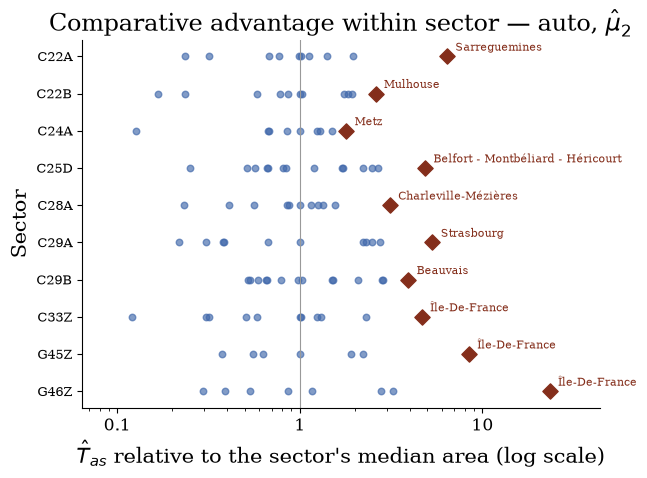

,sector,area,area_code,T,log_T_dev,rank,is_reference,n_cells
0,C22A,Île-De-France,1100,0.701017,-0.011566,6,False,11
1,C22A,Beauvais,2207,1.382199,0.667333,2,False,4
2,C22A,Rouen,2307,0.225749,-1.144674,9,False,4
3,C22A,Sarreguemines,4110,4.536073,1.855719,1,False,3
4,C22A,Vesoul,4309,0.717422,0.011566,5,False,7
5,C22A,Angers,5205,0.479609,-0.391126,8,False,20
6,C22A,Le Mans,5213,0.543799,-0.265519,7,False,11
7,C22A,Rennes,5312,0.795064,0.114324,4,False,8
8,C22A,Valence,8208,1.000000,0.343657,3,True,34
9,C22A,Annecy,8218,0.167384,-1.443805,10,False,11


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


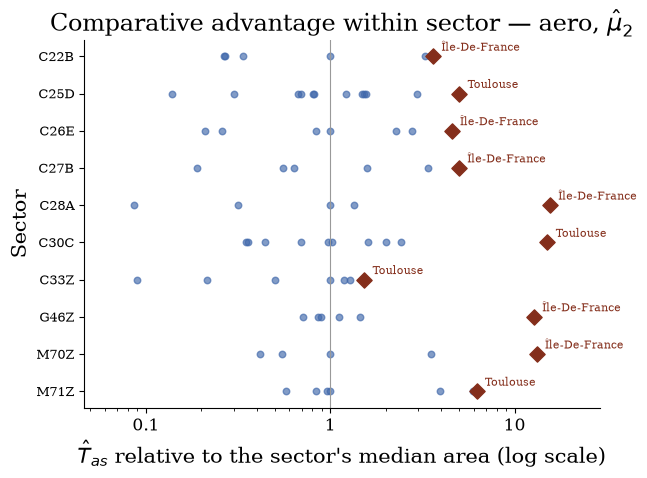

,sector,area,area_code,T,log_T_dev,rank,is_reference,n_cells
0,C22B,Roissy - Sud Picardie,0056,0.093163,-1.090093,5,False,50
1,C22B,Toulouse,0061,0.967737,1.250514,2,False,14
2,C22B,Île-De-France,1100,1.000000,1.283309,1,True,12
3,C22B,Cholet,5206,0.902650,1.180888,3,False,19
4,C22B,Châtellerault,5402,0.074054,-1.319649,6,False,8
5,C22B,Bordeaux,7204,0.277119,0.000000,4,False,8
6,C22B,Valence,8208,0.073160,-1.331798,7,False,32
7,C25D,Roissy - Sud Picardie,0056,0.027612,-1.977249,12,False,54
8,C25D,Toulouse,0061,1.000000,1.612269,1,True,18
9,C25D,Île-De-France,1100,0.304035,0.421657,4,False,12


In [110]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_frame(data).head(12))


## Test 2 — what is that inequality worth in distance?

The two forces are commensurable on a log scale, so an edge in comparative advantage can be
quoted in kilometres. A gap of $\Delta$ in $\log T$ is offset by a distance ratio of
$\exp\!\big(\Delta/(\theta\alpha)\big)$: how many times further from a buyer a region of the
favoured area may sit than a competing region of the other area, and still win.

**The figure shows that distance and nothing else.** A ratio is not yet a distance, so it
is anchored: each row runs from the distance a competing region *typically* sits from its
buyer — the geometric mean of the cell-to-buyer distances, one number for the whole
industry so the rows compare — out to the distance a region of the top area could sit at
and still win. The axis is logarithmic and labelled in kilometres, and beyond
$1000\,\mathrm{km}$, roughly the width of the country, it switches to powers of ten:
past that point the number has stopped being a distance anyone can travel, and the
statement it makes is simply that **no location offsets the edge**. The multiplier is
printed beside each row, since it is the anchor-free content.

The table `ca_distance_equivalence` keeps two benchmarks the figure no longer draws —
`geo_log_spread`, the typical p90 − p10 spread of $\log d$ across the regions competing
for a buyer, and `geo_log_range`, the extreme pooled max − min — together with the flags
that say whether the edge clears them. They are averages of a distribution, which is
exactly what Test 3 removes by making the comparison buyer by buyer; that is the version
to quote, and it is where those spreads are properly drawn.


In [111]:
# Test 2 — the edge in distance units, against the distances the geography offers.

def _typical_competitor_distance(geom, data):
    """
    The distance at which a competing region typically sits from its buyer, in km.

    The geometric mean of the cell-to-buyer distances — uniform over the cells competing
    for a buyer, purchase-weighted over buyers, pooled over sectors. The geometric mean
    is the right centre here because the whole comparison is multiplicative: the
    comparative-advantage edge is a distance RATIO, and anchoring it at this distance is
    what turns it into kilometres.
    """
    w = _buyer_weights(data)
    per_sector = [float(np.log(blk["distance"]).mean(axis=0) @ w)
                  for blk in geom["by_sector"].values()]
    return float(np.exp(np.mean(per_sector))) if per_sector else np.nan


def ca_distance_equivalence(data, ref_km=None):
    """
    How much distance a comparative-advantage gap is worth, against how much distance the
    country actually offers.

    `equiv_log_d = Delta log T / (theta*alpha)` is the log distance ratio that exactly
    offsets the gap between the top area and the median one — how much further from a
    buyer a REGION of the top area may sit than a competing REGION of the median area.
    It is compared with two benchmarks, both computed on cell-to-buyer distances:

      `geo_log_range`  the EXTREME spread, pooled max - min of log distance across all
                       competing cells and buyers. Anchored at the own-region cell, so
                       one degenerate observation sets it: it is the largest gap the
                       geography could ever offer;
      `geo_log_spread` the TYPICAL spread: p90 - p10 of log distance across the cells
                       competing for a given buyer, averaged over buyers with their
                       purchase weights.

    These two are averages over a distribution. `ca_win_margin` does the same comparison
    exactly, buyer by buyer, and is the one to quote; this table is the summary version.

    `equiv_distance_km` is the same edge in kilometres: the ratio applied to a reference
    distance `ref_km`, which defaults to the distance a competing region typically sits
    from its buyer (`_typical_competitor_distance`, the same for every sector so the
    rows stay comparable). It reads "a competitor of the median area typically sits at
    `ref_km`; a region of the top area could sit at `equiv_distance_km` and still win" —
    and a value beyond the ~1000 km width of the country is the statement that no
    location compensates.
    """
    geom = sourcing_geometry(data)
    ta = geom["theta"] * geom["alpha"]
    ref = _typical_competitor_distance(geom, data) if ref_km is None else float(ref_km)
    caf = comparative_advantage_frame(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        name = data["sector_names"][s]
        sub = caf[caf["sector"] == name].sort_values("rank")
        if sub.empty:
            continue
        logT = np.log(np.maximum(sub["T"].to_numpy(), 1e-300))
        d_top_med = float(logT[0] - np.median(logT))
        d_top_2nd = float(logT[0] - logT[1]) if logT.size > 1 else np.nan
        ld = np.log(blk["distance"])
        geo_range = float(ld.max() - ld.min())
        per_buyer = np.percentile(ld, 90, axis=0) - np.percentile(ld, 10, axis=0)
        geo_spread = float(per_buyer @ _buyer_weights(data))
        equiv = d_top_med / ta if ta > 0 else np.inf
        rows.append({
            "sector": name, "top_area": sub["area"].iloc[0], "n_areas": len(sub),
            "dlogT_top_vs_median": d_top_med, "dlogT_top_vs_2nd": d_top_2nd,
            "equiv_log_d": equiv,
            "equiv_distance_ratio": float(np.exp(min(equiv, 700))),
            "equiv_distance_km": float(ref * np.exp(min(equiv, 700))),
            "geo_log_range": geo_range, "geo_log_spread": geo_spread,
            "CA_beats_any_geography": bool(equiv > geo_range),
            "CA_beats_typical_geography": bool(equiv > geo_spread),
        })
    df = _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)
    df.attrs["theta_alpha"] = ta
    df.attrs["ref_distance_km"] = ref
    return df


def plot_ca_distance_equivalence(data, ref_km=None, annotate_ratio=True,
                                 figsize=None, save_to=None):
    """
    What the top area's edge is worth in distance, in kilometres and nothing else.

    Each row runs from the distance a competing region TYPICALLY sits from its buyer
    (the dotted anchor) out to `equiv_distance_km`: how far from that buyer a region of
    the top area could sit and still win against a region of the median area. The axis
    is logarithmic because the edge is a distance RATIO — `Delta log T/(theta*alpha)` —
    so equal edges are equal lengths on the axis whatever the anchor; the labels are
    kilometres, and beyond 1000 km, roughly the width of the country, they switch to
    powers of ten, since past that point the number is no longer a distance anyone can
    travel and the statement is simply that no location compensates.

    The geographic benchmarks (the extreme range and the typical p90 - p10 spread) stay
    in `ca_distance_equivalence`'s table and are drawn buyer by buyer, exactly, by
    `plot_ca_win_margin` in test 3.
    """
    df = ca_distance_equivalence(data, ref_km=ref_km)[::-1]   # code order, top to bottom
    ref = df.attrs["ref_distance_km"]
    y = np.arange(len(df))
    vals = df["equiv_distance_km"].to_numpy(float)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    ax.set_xscale("log")
    ax.hlines(y, ref, vals, color=sim_color, linewidth=5, alpha=0.85, zorder=2)
    ax.scatter(vals, y, marker="D", s=34, color=reference_color, zorder=3,
               label="distance a top-area region could sit at and still win")
    ax.axvline(ref, color="0.45", linestyle=":", linewidth=1.2, zorder=1,
               label=f"typical competitor distance, {ref:.0f} km")
    if annotate_ratio:
        for yi, (v, r) in enumerate(zip(vals, df["equiv_distance_ratio"])):
            if np.isfinite(v) and v > 0:
                ax.annotate(rf"$\times${r:,.0f}" if r >= 10 else rf"$\times${r:.1f}",
                            (v, yi), xytext=(7, 0), textcoords="offset points",
                            va="center", fontsize=8, color=reference_color)
    _log_ticks(ax, "x", sci_above=1000)
    ax.margins(x=0.16)
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("Distance from the buyer (km, log scale)")
    ax.set_title(f"What the comparative-advantage edge is worth in distance — "
                 f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"\n" rf"$\theta\hat\alpha$ = {df.attrs['theta_alpha']:.3f}"
                 f", anchored at {ref:.0f} km", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center",
              bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


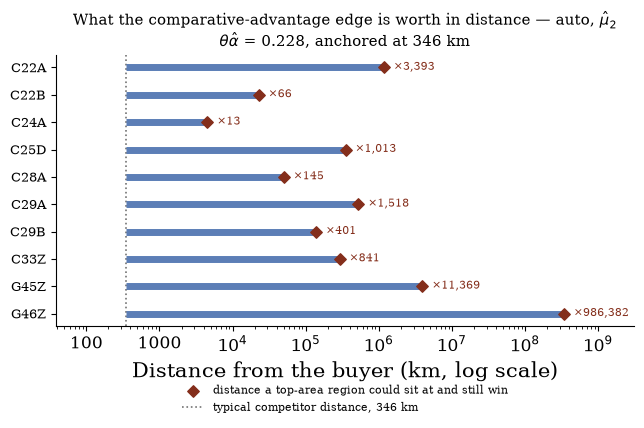

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,equiv_distance_km,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,,
C22A,Sarreguemines,10,1.855719,1.188386,8.129536,3393.225449,1.174852e+06,4.510434,1.538358,True,True
C22B,Mulhouse,11,0.955204,0.303019,4.184562,65.664709,2.273539e+04,4.533789,1.350025,False,True
C24A,Metz,9,0.586143,0.180975,2.567777,13.036811,4.513794e+03,4.533789,1.342422,False,True
C25D,Belfort - Montbéliard - Héricourt,14,1.579761,0.597289,6.920621,1012.948630,3.507178e+05,4.771428,1.528611,True,True
C28A,Charleville-Mézières,11,1.135484,0.691776,4.974329,144.651759,5.008344e+04,4.552407,1.367805,True,True
C29A,Strasbourg,11,1.672087,0.666924,7.325082,1517.898810,5.255490e+05,4.787456,1.272539,True,True
C29B,Beauvais,14,1.368051,0.317779,5.993161,400.679152,1.387290e+05,4.745919,1.528344,True,True
C33Z,Île-De-France,11,1.537396,0.707666,6.735026,841.365210,2.913097e+05,4.533789,1.365123,True,True
G45Z,Île-De-France,7,2.131719,1.328828,9.338638,11368.907837,3.936309e+06,4.536379,1.381816,True,True


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


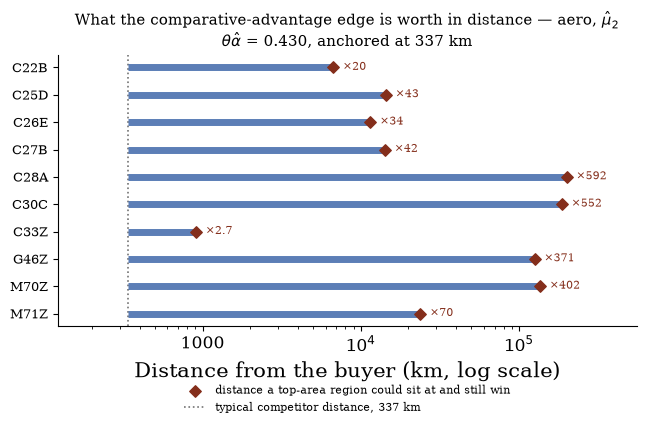

,top_area,n_areas,dlogT_top_vs_median,dlogT_top_vs_2nd,equiv_log_d,equiv_distance_ratio,equiv_distance_km,geo_log_range,geo_log_spread,CA_beats_any_geography,CA_beats_typical_geography
sector,,,,,,,,,,,
C22B,Île-De-France,7,1.283309,0.032795,2.986668,19.819525,6683.296548,4.925035,1.435774,False,True
C25D,Toulouse,12,1.612269,0.528349,3.752262,42.617382,14370.909388,5.647328,1.413060,False,True
C26E,Île-De-France,7,1.515270,0.497274,3.526516,34.005284,11466.843614,4.434990,1.663617,False,True
C27B,Île-De-France,6,1.606423,0.384114,3.738657,42.041511,14176.721400,4.326218,1.299195,False,True
C28A,Île-De-France,5,2.742887,2.447149,6.383570,592.037784,199639.700040,4.182868,1.250889,True,True
C30C,Toulouse,10,2.712873,1.831732,6.313718,552.093629,186170.223434,4.778641,1.572740,True,True
C33Z,Toulouse,7,0.425131,0.181105,0.989415,2.689660,906.973904,4.788015,1.623199,False,False
G46Z,Île-De-France,6,2.542584,2.167679,5.917401,371.445158,125254.167709,4.394953,1.504883,True,True
M70Z,Île-De-France,5,2.576651,1.323802,5.996685,402.093710,135589.095667,4.349354,1.478601,True,True


In [112]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_distance_equivalence(data))


## Test 3 — does the favoured area actually win?

Test 2 compares an average edge with an average spread. Neither average has to hold for any
particular buyer, so here the comparison is made exactly, **buyer by buyer and region by
region**, which is the form the inequality at the top of the section takes.

For each sector let $A^*$ be the area with the highest $\hat T$. For each downstream buyer
$r$, every competing cell $l$ carries a score $\log \psi_{lr} = \log T_{a(l)} - \theta\alpha
\log d_{lr}$, and $A^*$ takes the buyer iff its best cell outscores the best cell outside
it. Two numbers come out, both in log-distance units:

* **`mean_win_margin`** — $\big[\max_{l \in A^*} \log\psi - \max_{l \notin A^*}
  \log\psi\big]/(\theta\alpha)$: how much further from this buyer the favoured area's best
  region could be and still win. Positive means it wins; `share_buyers_won` is the
  purchase-weighted share of buyers it takes;
* **`mean_within_penalty`** — $\log d$ of the worst region of $A^*$ minus that of its best,
  for the same buyer. Inside an area $T$ cancels exactly, so this comparison is **pure
  geography**: it is the handicap the area's own spread imposes on its worst region, and it
  is the variation that identifies $\alpha$.

Putting the two side by side answers a question the area-level statement cannot even pose:
does it matter more *which area* a supplier belongs to, or *which region of it* it sits in?
When the second bar is longer than the first, the answer is the region — and that is
exactly the case in which letting regions deviate from their area's $T$ would change the
picture most.


In [113]:
# Test 3 — the exact comparison, buyer by buyer and region by region.

def ca_win_margin(data):
    """
    The decisive test, buyer by buyer and REGION by region — no averaging of distances.

    For each sector, let A* be the area with the highest T. For each downstream buyer r,
    every competing cell l has score

        log psi_lr = log T_{a(l)} - theta*alpha*log d_{lr},

    so A* takes the buyer iff its best cell outscores the best cell OUTSIDE it. Two
    numbers come out of that comparison, both in LOG-DISTANCE units (divide by
    theta*alpha), which is what makes them readable:

      win_margin_r  = [max_{l in A*} score - max_{l not in A*} score] / (theta*alpha)
                      how much FURTHER the favoured area's best region could be from
                      this buyer and still win. Positive = it wins.
      within_penalty_r = log d(worst cell of A*) - log d(best cell of A*)
                      the handicap A*'s own geography imposes on its worst region. Inside
                      an area T cancels exactly, so this comparison is PURE DISTANCE —
                      it is the variation that identifies alpha, and it is invisible to
                      any statement written in terms of area-level distances.

    Both are averaged over buyers with their purchase weights. `share_buyers_won` is the
    purchase-weighted share of buyers the favoured area actually takes; comparing
    `mean_win_margin` with `mean_within_penalty` says whether belonging to the right area
    or sitting in the right region of it matters more.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    est_T = geom["T"]
    rows = []
    for s, blk in geom["by_sector"].items():
        act = np.flatnonzero(data["AA_ACTIVE"][s])
        if act.size == 0:
            continue
        top_area = int(act[np.argmax(est_T[s, act])])
        in_top = blk["areas"] == top_area
        if not in_top.any() or in_top.all():
            continue                       # no cross-area comparison to make
        score = blk["log_psi"]                                   # (n_cell, R_d)
        ld = np.log(blk["distance"])
        best_top = score[in_top].max(axis=0)
        best_out = score[~in_top].max(axis=0)
        margin = (best_top - best_out) / ta if ta > 0 else np.full_like(best_top, np.inf)
        penalty = ld[in_top].max(axis=0) - ld[in_top].min(axis=0)
        rows.append({
            "sector": data["sector_names"][s],
            "top_area": aa_display_names(data)[top_area],
            "n_cells_top_area": int(in_top.sum()),
            "share_buyers_won": float((margin > 0) @ w),
            "mean_win_margin": float(margin @ w),
            "min_win_margin": float(margin.min()),
            "mean_within_penalty": float(penalty @ w),
            "area_beats_own_geography": bool(float(margin @ w) > float(penalty @ w)),
        })
    df = pd.DataFrame(rows)
    return _by_sector_code(df.set_index("sector"), data) if len(df) else df


def plot_ca_win_margin(data, figsize=None, save_to=None):
    """
    The exact test, per sector: how much further the top area's best region could be from
    the average buyer and still win (bar), against the distance handicap that area's own
    geography already imposes on its worst region (marker). Both in log-distance units,
    so they are directly comparable — a bar shorter than its marker is a sector where
    WHICH REGION of the favoured area a supplier sits in matters more than the area's
    edge itself.
    """
    df = ca_win_margin(data)
    if not len(df):
        raise ValueError("no sector has cells both inside and outside its top area — "
                         "there is no cross-area comparison to draw.")
    df = df[::-1]
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    ax.barh(y, df["mean_win_margin"],
            color=[reference_color if v else sim_color
                   for v in df["area_beats_own_geography"]], alpha=0.85,
            label="win margin of the top area (log distance it could give away)")
    ax.scatter(df["mean_within_penalty"], y, marker="|", s=220, color="black", zorder=3,
               label="within-area distance handicap (best to worst region of that area)")
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    for i, (_, r) in enumerate(df.iterrows()):
        ax.annotate(f"{100 * r['share_buyers_won']:.0f}% of buyers",
                    (max(r["mean_win_margin"], 0.0), i), fontsize=8,
                    xytext=(4, -3), textcoords="offset points")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance")
    ax.set_title(f"Does the favoured area actually win? — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


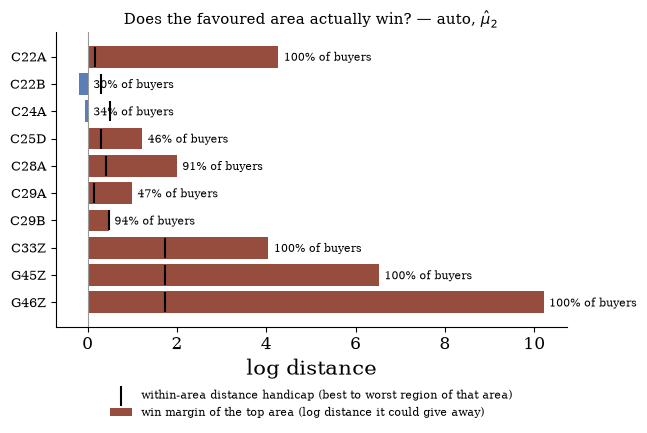

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22A,Sarreguemines,3,1.000000,4.267735,2.211579,0.163494,True
C22B,Mulhouse,4,0.301290,-0.195206,-2.066765,0.306439,False
C24A,Metz,7,0.340575,-0.064811,-2.147457,0.497587,False
C25D,Belfort - Montbéliard - Héricourt,3,0.459465,1.218489,-0.213569,0.296740,True
C28A,Charleville-Mézières,4,0.908475,1.994199,-0.106490,0.419986,True
C29A,Strasbourg,4,0.471849,0.988877,-0.154471,0.150576,True
C29B,Beauvais,3,0.944026,0.474431,-1.395903,0.466361,True
C33Z,Île-De-France,14,1.000000,4.046695,0.404516,1.722662,True
G45Z,Île-De-France,14,1.000000,6.521338,3.855291,1.722662,True


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


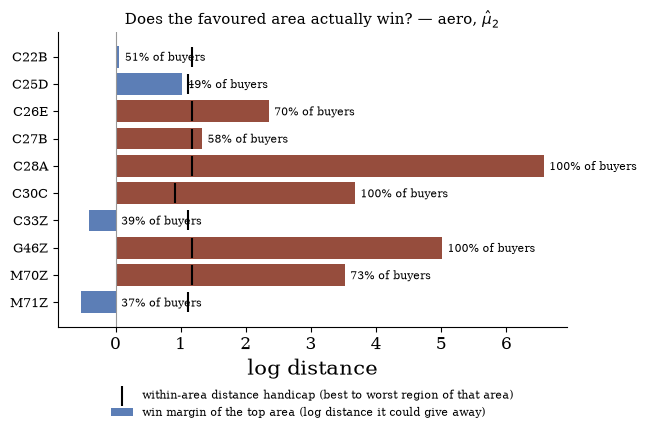

,top_area,n_cells_top_area,share_buyers_won,mean_win_margin,min_win_margin,mean_within_penalty,area_beats_own_geography
sector,,,,,,,
C22B,Île-De-France,12,0.514449,0.057870,-3.632667,1.179510,False
C25D,Toulouse,18,0.490007,1.016699,-0.811832,1.111834,False
C26E,Île-De-France,9,0.697858,2.348473,-2.268416,1.167285,True
C27B,Île-De-France,11,0.577955,1.326139,-2.815037,1.179510,True
C28A,Île-De-France,11,1.000000,6.570698,3.177298,1.175907,True
C30C,Toulouse,6,1.000000,3.673657,0.981455,0.917569,True
C33Z,Toulouse,21,0.390076,-0.402285,-2.690355,1.111834,False
G46Z,Île-De-France,12,1.000000,5.010553,1.943572,1.179510,True
M70Z,Île-De-France,12,0.727581,3.516662,-0.628082,1.179510,True


In [114]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_ca_win_margin(
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_win_margin(data))


## Test 4 — which force disperses the competition more?

Tests 2 and 3 ask who wins. This one asks which force is doing the work, and it is an
identity rather than a regression. Because $\log\psi$ is a sum, its dispersion across the
cells competing for a given buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

Variances are taken **across cells at a fixed buyer** — the competition the model actually
runs — and then averaged over buyers with their purchase weights.
$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like size of the two pulls, and `ratio_CA_over_distance` above one says
comparative advantage disperses the competition more than geography does.

The three shares sum to one by construction. The covariance share is the interesting one
and the one not to over-read — which is what Test 5 is for.


In [115]:
# Test 4 — the exact variance decomposition of log psi across competing cells.

def ca_variance_decomposition(data):
    """
    The exact split of the dispersion of log psi across competing cells.

    For a given buyer r, log psi_{l,r} = log T_l - theta*alpha*log d_{l,r}, so

        Var_l(log psi) = Var_l(log T) + (theta*alpha)^2 Var_l(log d)
                         - 2*theta*alpha*Cov_l(log T, log d)

    holds with no approximation. Variances are taken ACROSS CELLS at a fixed buyer —
    which is the competition the model actually runs — then averaged over buyers with
    their purchase weights. `sd_logT` against `sd_dist` is the like-for-like size of the
    two forces.

    The covariance term is NOT free of the estimator: T is the Sinkhorn image of the
    observed sourcing shares, which loads onto comparative advantage whatever distance
    takes away, so a positive Cov(log T, log d) — hence a negative contribution
    `share_covariance` — is the expected reading. `ca_covariance_benchmark` splits it.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        ld = np.log(blk["distance"])                       # (n_cell, R_d)
        v_T = float(np.var(logT))
        v_d = np.var(ld, axis=0)                           # per buyer
        cov = np.array([np.cov(logT, ld[:, r], bias=True)[0, 1] for r in range(ld.shape[1])])
        v_psi = v_T + (ta ** 2) * v_d - 2 * ta * cov
        vd_bar, cov_bar, vpsi_bar = float(v_d @ w), float(cov @ w), float(v_psi @ w)
        rows.append({
            "sector": data["sector_names"][s],
            "sd_logT": np.sqrt(v_T),
            "sd_dist": ta * np.sqrt(vd_bar),
            "ratio_CA_over_distance": np.sqrt(v_T) / (ta * np.sqrt(vd_bar))
            if vd_bar > 0 else np.inf,
            "share_CA": v_T / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_distance": (ta ** 2) * vd_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_covariance": -2 * ta * cov_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "sd_log_psi": np.sqrt(vpsi_bar),
        })
    return _by_sector_code(pd.DataFrame(rows).set_index("sector"), data)


In [116]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_variance_decomposition(data))


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22A,0.646854,0.143408,4.510577,0.990982,0.048708,-0.039690,0.649790
C22B,0.869439,0.131992,6.587063,0.890662,0.020527,0.088811,0.921262
C24A,0.992669,0.146356,6.782546,0.853673,0.018557,0.127770,1.074382
C25D,0.944432,0.148158,6.374488,0.846555,0.020834,0.132612,1.026462
C28A,0.743101,0.133378,5.571392,0.819060,0.026387,0.154553,0.821088
C29A,1.004207,0.132223,7.594825,0.870090,0.015084,0.114826,1.076568
C29B,0.580684,0.152631,3.804497,0.768229,0.053076,0.178695,0.662513
C33Z,0.974689,0.133501,7.300991,0.879691,0.016503,0.103806,1.039204
G45Z,0.868850,0.135668,6.404234,0.947740,0.023108,0.029152,0.892484


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,sd_log_psi
sector,,,,,,,
C22B,1.119134,0.266342,4.201862,0.873937,0.049499,0.076564,1.197132
C25D,1.098827,0.254286,4.321225,0.892925,0.047819,0.059256,1.162845
C26E,1.204145,0.312154,3.857536,0.813999,0.054702,0.131299,1.334648
C27B,1.068703,0.251557,4.248354,0.863414,0.047839,0.088748,1.150132
C28A,1.629855,0.236316,6.896924,0.927393,0.019496,0.053111,1.692455
C30C,1.258899,0.317989,3.958942,0.866592,0.055291,0.078116,1.352333
C33Z,0.965487,0.297326,3.247231,0.888583,0.084270,0.027147,1.024230
G46Z,0.753689,0.274916,2.741522,0.780474,0.103842,0.115684,0.853125
M70Z,1.186850,0.271882,4.365304,0.838419,0.043998,0.117583,1.296179


## Test 5 — is the covariance term about the economy or about the estimator?

Under `--profile_T=true`, $\hat T$ is not a free estimate: it is the Sinkhorn image that
makes the model reproduce the *observed* sourcing shares at the current $\alpha$. At the
area level,

$$\log \hat T_{as} \;=\; \log \hat\gamma^{\,emp}_{as} \;-\; \log M_{as}(\alpha) + \text{const},
\qquad M_{as}(\alpha) = \sum_r \omega_r\, d_{ar}^{-\theta\alpha}/\Phi_{sr},$$

with $M$ the market-access term. $M$ falls with distance to markets, so a remote area that
nonetheless sells must be handed a **higher** $T$: the inversion loads onto comparative
advantage exactly what distance takes away. Hence, cell by cell,

$$\operatorname{Cov}(\log \hat T, \log d) \;=\; \underbrace{\operatorname{Cov}(\log \hat\gamma^{\,emp}, \log d)}_{\text{the gradient in the data}} \;-\; \underbrace{\operatorname{Cov}(\log M, \log d)}_{<\,0,\ \text{growing in } \alpha},$$

so the expected sign of $\operatorname{Cov}(\log \hat T, \log d)$ is **positive** unless the
observed sourcing shares fall with distance fast enough to outweigh the correction — and a
positive covariance makes Test 4's `share_covariance` **negative**: the two forces offset,
and $\operatorname{Var}(\log\psi)$ is smaller than the sum of the two separate variances.
That is the inversion's signature, not a finding about the economy, and reading Test 4
without it invites calling comparative advantage "large" when what is large is the
compensation for remoteness.

`ca_covariance_benchmark` reports the two terms separately, taking
$\log M = \log\hat\gamma^{emp} - \log\hat T$ as the residual (exact up to the per-sector
constant, which a covariance drops), so which one drives the total is a number. At
$\alpha = 0$ the market-access term is common within a sector and must vanish, leaving
$\operatorname{Cov}(\log\hat T, \log d) = \operatorname{Cov}(\log\hat\gamma, \log d)$ — the
limiting case to check the split against.


In [117]:
# Test 5 — where the covariance term comes from, given how T was obtained.

def ca_covariance_benchmark(data):
    """
    Where the covariance term of the decomposition comes from — the data, or the
    inversion.

    Under profiling, T is chosen so the model reproduces the observed sourcing shares:
    at the area level, log T_a = log gamma^emp_a - log M_a(alpha) + const, with M the
    market-access term. Hence, cell by cell,

        Cov(log T, log d) = Cov(log gamma^emp, log d) - Cov(log M, log d),

    and since M falls with distance to markets the second term is negative, i.e. the
    inversion MECHANICALLY pushes Cov(log T, log d) up: a remote area that nonetheless
    sells must be handed a higher T. This function reports the two pieces, taking
    log M = log gamma^emp - log T as the residual (exact up to the per-sector constant,
    which drops out of a covariance). Read `cov_gamma` as the gradient in the data and
    `-cov_M` as what the inversion added on top of it.

    At alpha = 0 the market-access term is common within a sector and `cov_M` must
    vanish, leaving `cov_T == cov_gamma` — the limiting case to check the split against.
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    emp_gamma_aa, aa_of_ze = data["emp_gamma_aa"], data["aa_of_ze"]
    rows = []
    for s, blk in geom["by_sector"].items():
        cells, areas = blk["cells"], blk["areas"]
        g = emp_gamma_aa[s, areas]
        keep = (g > 0) & (blk["T_cell"] > 0)
        if keep.sum() < 2:
            continue
        logT = np.log(blk["T_cell"][keep])
        logG = np.log(g[keep])
        logM = logG - logT                                  # the market-access residual
        ld = np.log(blk["distance"][keep])
        def _cov(x):
            return float(np.array([np.cov(x, ld[:, r], bias=True)[0, 1]
                                   for r in range(ld.shape[1])]) @ w)
        cov_T, cov_G, cov_M = _cov(logT), _cov(logG), _cov(logM)
        sd_ld = float(np.sqrt(np.array([np.var(ld[:, r]) for r in range(ld.shape[1])]) @ w))
        rows.append({
            "sector": data["sector_names"][s],
            "cov_T": cov_T, "cov_gamma": cov_G, "cov_M": cov_M,
            "check_gamma_minus_M": cov_G - cov_M - cov_T,      # 0 by construction
            "corr_T_d": cov_T / (np.std(logT) * sd_ld) if sd_ld > 0 and np.std(logT) > 0 else np.nan,
            "corr_gamma_d": cov_G / (np.std(logG) * sd_ld) if sd_ld > 0 and np.std(logG) > 0 else np.nan,
            "share_covariance": np.nan,
        })
    df = pd.DataFrame(rows).set_index("sector")
    vd = ca_variance_decomposition(data)
    df["share_covariance"] = vd["share_covariance"].reindex(df.index)
    df.attrs["theta_alpha"] = ta
    return _by_sector_code(df, data)


In [118]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(ca_covariance_benchmark(data))


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22A,0.036707,0.234161,0.197453,-4.857226e-17,0.090328,0.390179,-0.039690
C22B,-0.165104,0.070128,0.235232,-8.326673e-17,-0.328410,0.169587,0.088811
C24A,-0.323050,-0.153344,0.169706,5.551115e-17,-0.507575,-0.336166,0.127770
C25D,-0.306049,0.087636,0.393685,0.000000e+00,-0.499277,0.187015,0.132612
C28A,-0.228234,0.024428,0.252662,-2.775558e-17,-0.525649,0.072531,0.154553
C29A,-0.291505,-0.040101,0.251404,-5.551115e-17,-0.501145,-0.106569,0.114826
C29B,-0.171801,0.108043,0.279844,-5.551115e-17,-0.442475,0.247324,0.178695
C33Z,-0.245554,0.068004,0.313558,-5.551115e-17,-0.430767,0.112579,0.103806
G45Z,-0.050862,0.283052,0.333914,1.734723e-16,-0.098495,0.343403,0.029152


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,cov_T,cov_gamma,cov_M,check_gamma_minus_M,corr_T_d,corr_gamma_d,share_covariance
sector,,,,,,,
C22B,-0.127683,-0.066226,0.061457,-2.775558e-17,-0.184059,-0.115192,0.076564
C25D,-0.093240,-0.042733,0.050507,-1.387779e-17,-0.143382,-0.085350,0.059256
C26E,-0.272157,-0.263884,0.008273,1.665335e-16,-0.311111,-0.327946,0.131299
C27B,-0.136608,-0.092699,0.043909,-1.387779e-16,-0.218337,-0.150156,0.088748
C28A,-0.177028,-0.121355,0.055674,-8.326673e-17,-0.197490,-0.167895,0.053111
C30C,-0.166240,-0.176851,-0.010611,-2.775558e-17,-0.178434,-0.190413,0.078116
C33Z,-0.033139,0.002358,0.035498,-7.632783e-17,-0.049603,0.003101,0.027147
G46Z,-0.097977,-0.045714,0.052263,2.775558e-17,-0.203178,-0.103989,0.115684
M70Z,-0.229879,-0.182016,0.047863,1.110223e-16,-0.306103,-0.259687,0.117583


## Test 6 — what would sourcing look like with one force switched off?

The win probabilities are closed form, so the allocation can be recomputed with either
force removed — no re-simulation, no re-estimation. Four regimes: both forces, distance
only ($T$ equalised within the sector), comparative advantage only ($\alpha = 0$), and
neither, which is the uniform $1/n$ benchmark every cell equally likely.

Read as a decomposition: the move from *Neither* to *Distance only* is what geography alone
does to the concentration and reach of sourcing, and the move to *Comparative advantage
only* is what $T$ alone does. Four statistics per sector and regime, all averaged over
buyers with their purchase weights: the share of the single best cell, the HHI, the mean
sourcing distance, and the sourcing share of the sector's highest-$T$ area.


In [119]:
# Test 6 — the allocation of winners with one force switched off.

CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0),
              "Neither": dict(equalise_T=True, alpha=0.0)}


def counterfactual_sourcing(data, regimes=CF_REGIMES):
    """
    The allocation of winners with each force switched off, from the closed-form win
    probabilities — no re-simulation.

    Per sector and regime, averaged over buyers with their purchase weights:
      top_cell_share : max_l rho_{l,r}, how concentrated sourcing is on one cell,
      hhi            : sum_l rho^2,
      mean_distance  : sum_l rho_{l,r} d_{l,r}, how far sourcing actually reaches,
      top_area_share : the sourcing share of the sector's highest-T area.

    "Neither" is the uniform benchmark: every cell equally likely. Reading the table as a
    decomposition, the move from "Neither" to "Distance only" is what geography alone
    does, and to "Comparative advantage only" what T alone does.
    """
    w = _buyer_weights(data)
    est = unpack_estimated_T(data)
    rows = []
    for label, kw in regimes.items():
        geom = sourcing_geometry(data, **kw)
        for s, blk in geom["by_sector"].items():
            rho, d = blk["rho"], blk["distance"]
            top_area = int(np.argmax(est["T"][s] * data["AA_ACTIVE"][s]))
            in_top = blk["areas"] == top_area
            rows.append({
                "sector": data["sector_names"][s], "regime": label,
                "top_cell_share": float((rho.max(axis=0)) @ w),
                "hhi": float((rho ** 2).sum(axis=0) @ w),
                "mean_distance": float((rho * d).sum(axis=0) @ w),
                "top_area_share": float(rho[in_top].sum(axis=0) @ w) if in_top.any() else np.nan,
                "n_cells": int(blk["cells"].size),
            })
    df = pd.DataFrame(rows)
    df["regime"] = pd.Categorical(df["regime"], categories=list(regimes), ordered=True)
    df["sector"] = pd.Categorical(df["sector"], categories=_sectors_in_code_order(data),
                                  ordered=True)
    return df.set_index(["sector", "regime"]).sort_index()


def plot_counterfactual_sourcing(data, figsize=None, save_to=None):
    """
    What each force does to the allocation of winners, from the closed-form win
    probabilities: the mean distance sourcing reaches, and how concentrated it is on the
    single best cell, under both forces and with each switched off.
    """
    cf = counterfactual_sourcing(data).reset_index()
    sectors = [s for s in _sectors_in_code_order(data) if s in set(cf["sector"])]
    regimes = list(CF_REGIMES)
    palette = [sim_color, (0.45, 0.6, 0.45), reference_color, "0.7"]

    fig, axes = plt.subplots(1, 2, figsize=figsize or get_figsize(wf=1.0, hf=0.5))
    x = np.arange(len(sectors))
    width = 0.8 / len(regimes)
    for k, (reg, col) in enumerate(zip(regimes, palette)):
        sub = cf[cf["regime"] == reg].set_index("sector").reindex(sectors)
        off = (k - (len(regimes) - 1) / 2) * width
        axes[0].bar(x + off, sub["mean_distance"], width, color=col, label=reg)
        axes[1].bar(x + off, sub["top_cell_share"], width, color=col, label=reg)

    for ax, lab in zip(axes, ["Mean sourcing distance (km)",
                              "Sourcing share of the single best cell"]):
        ax.set_xticks(x)
        ax.set_xticklabels(sectors, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel(lab, fontsize=10)
        _despine(ax)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"Winners with one force switched off — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=12)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


# What every column of `comparative_advantage_summary` means. Printed by
# `display(comparative_advantage_glossary())` next to the table itself, so the table can
# be read without coming back to the source.


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


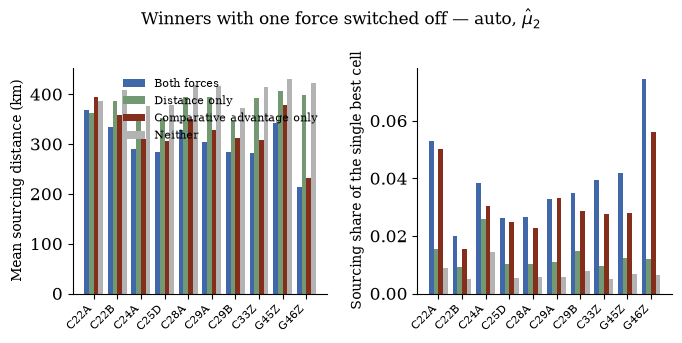

top_cell_share    hhi  mean_distance  \
sector regime                                                             
C22A   Both forces                          0.053  0.016        367.990   
       Distance only                        0.015  0.009        362.227   
       Comparative advantage only           0.050  0.015        394.889   
       Neither                              0.009  0.009        387.073   
C22B   Both forces                          0.020  0.008        334.092   
       Distance only                        0.009  0.005        386.244   
       Comparative advantage only           0.015  0.008        357.944   
       Neither                              0.005  0.005        409.164   
C24A   Both forces                          0.038  0.022        289.807   
       Distance only                        0.026  0.015        352.152   
       Comparative advantage only           0.031  0.020        309.984   
       Neither                              0.014  0.014        377.271   
C25D   Both forces                          0.026  0.010        284.892   
       Distance only                        0.010  0.006        351.665   
       Comparative advantage only           0.025  0.010        305.679   
       Neither                              0.005  0.005        378.446   
C28A   Both forces                          0.027  0.009        327.225   
       Distance only                        0.010  0.006        394.974   
       Comparative advantage only           0.023  0.008        350.891   
       Neither                              0.006  0.006        418.570   
C29A   Both forces                          0.033  0.015        304.654   
       Distance only                        0.011  0.006        394.377   
       Comparative advantage only           0.033  0.014        327.448   
       Neither                              0.006  0.006        417.390   
C29B   Both forces                          0.035  0.015        284.845   
       Distance only                        0.015  0.008        346.075   
       Comparative advantage only           0.029  0.013        312.688   
       Neither                              0.008  0.008        373.140   
C33Z   Both forces                          0.039  0.017        281.628   
       Distance only                        0.010  0.005        391.645   
       Comparative advantage only           0.028  0.014        308.365   
       Neither                              0.005  0.005        415.392   
G45Z   Both forces                          0.042  0.018        342.959   
       Distance only                        0.012  0.007        407.034   
       Comparative advantage only           0.028  0.015        377.964   
       Neither                              0.007  0.007        431.115   
G46Z   Both forces                          0.075  0.049        214.734   
       Distance only                        0.012  0.007        398.133   
       Comparative advantage only           0.056  0.045        231.709   
       Neither                              0.007  0.007        423.294   

                                   top_area_share  n_cells  
sector regime                                               
C22A   Both forces                          0.155      113  
       Distance only                        0.027      113  
       Comparative advantage only           0.150      113  
       Neither                              0.027      113  
C22B   Both forces                          0.063      200  
       Distance only                        0.021      200  
       Comparative advantage only           0.062      200  
       Neither                              0.020      200  
C24A   Both forces                          0.219       69  
       Distance only                        0.109       69  
       Comparative advantage only           0.214       69  
       Neither                              0.101       69  
C25D   Both forces            

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


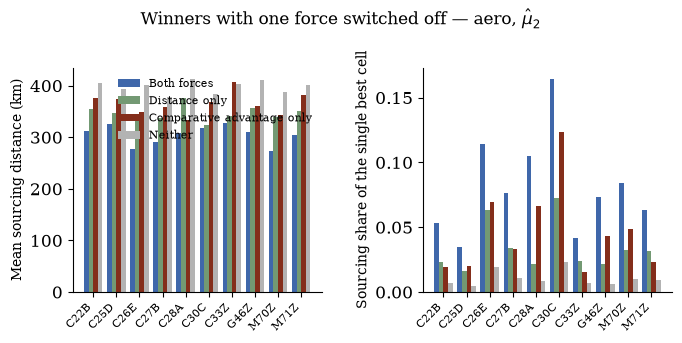

top_cell_share    hhi  mean_distance  \
sector regime                                                             
C22B   Both forces                          0.053  0.019        313.085   
       Distance only                        0.023  0.008        355.200   
       Comparative advantage only           0.019  0.015        375.346   
       Neither                              0.007  0.007        404.745   
C25D   Both forces                          0.035  0.012        325.766   
       Distance only                        0.016  0.005        347.647   
       Comparative advantage only           0.020  0.011        373.604   
       Neither                              0.005  0.005        393.851   
C26E   Both forces                          0.114  0.062        276.513   
       Distance only                        0.063  0.023        340.601   
       Comparative advantage only           0.069  0.051        349.880   
       Neither                              0.020  0.020        402.302   
C27B   Both forces                          0.077  0.029        291.772   
       Distance only                        0.034  0.012        337.377   
       Comparative advantage only           0.033  0.021        359.041   
       Neither                              0.011  0.011        378.396   
C28A   Both forces                          0.105  0.059        308.091   
       Distance only                        0.022  0.009        375.575   
       Comparative advantage only           0.067  0.050        333.388   
       Neither                              0.009  0.009        413.707   
C30C   Both forces                          0.165  0.102        317.872   
       Distance only                        0.073  0.028        323.775   
       Comparative advantage only           0.124  0.095        367.516   
       Neither                              0.023  0.023        384.765   
C33Z   Both forces                          0.042  0.013        328.076   
       Distance only                        0.024  0.008        341.743   
       Comparative advantage only           0.016  0.011        406.269   
       Neither                              0.007  0.007        403.810   
G46Z   Both forces                          0.074  0.031        311.173   
       Distance only                        0.022  0.007        357.381   
       Comparative advantage only           0.044  0.025        359.931   
       Neither                              0.007  0.007        411.198   
M70Z   Both forces                          0.084  0.040        274.283   
       Distance only                        0.033  0.012        339.634   
       Comparative advantage only           0.049  0.033        343.854   
       Neither                              0.010  0.010        387.999   
M71Z   Both forces                          0.063  0.024        305.070   
       Distance only                        0.032  0.010        350.133   
       Comparative advantage only           0.023  0.018        381.378   
       Neither                              0.009  0.009        401.673   

                                   top_area_share  n_cells  
sector regime                                               
C22B   Both forces                          0.271      143  
       Distance only                        0.105      143  
       Comparative advantage only           0.229      143  
       Neither                              0.084      143  
C25D   Both forces                          0.375      216  
       Distance only                        0.094      216  
       Comparative advantage only           0.366      216  
       Neither                              0.083      216  
C26E   Both forces                          0.659       51  
       Distance only                        0.231       51  
       Comparative advantage only           0.625       51  
       Neither                              0.176       51  
C27B   Both forces            

In [120]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    plot_counterfactual_sourcing(
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(counterfactual_sourcing(data).round(3))


## Everything in one table

The six tests joined on the sector, in A129-code order, with
`comparative_advantage_glossary()` documenting what every column is and how to read it.


In [121]:
# The six tests in one table, and the reading guide for it.

CA_SUMMARY_GLOSSARY = [
    ("top_area", "The attraction area with the highest estimated T in that sector: the "
                 "sector's favoured location, named by its anchor commuting zone."),
    ("n_areas", "How many attraction areas host at least one observed supplier of the "
                "sector — the number of distinct T values in the competition."),
    ("dlogT_top_vs_median", "log T of the top area minus log T of the median area. The "
                            "size of the edge, in log points, before any distance is "
                            "traded against it."),
    ("equiv_log_d", "That edge converted into distance: Delta log T / (theta*alpha), the "
                    "log distance ratio that exactly offsets it. A region of the top "
                    "area may be exp(.) times further from a buyer than a competing "
                    "region of the median area and still win."),
    ("equiv_distance_km", "The same edge in kilometres: the ratio above applied to the "
                          "distance a competing region typically sits from its buyer "
                          "(the geometric mean of cell-to-buyer distances, common to "
                          "every sector so the rows compare). A value beyond the ~1000 km "
                          "width of the country says no location offsets the edge. This "
                          "is what test 2's figure plots."),
    ("geo_log_spread", "The log-distance spread a buyer typically faces across the "
                       "regions competing for it (p90 - p10, purchase-weighted). The "
                       "benchmark `equiv_log_d` has to clear for the edge to be decisive "
                       "in ordinary competition."),
    ("geo_log_range", "The extreme version of the same thing: max - min log distance over "
                      "all competing regions and buyers. Anchored at the own-region cell, "
                      "so it is the largest handicap the geography could ever impose."),
    ("CA_beats_typical_geography", "equiv_log_d > geo_log_spread: the edge beats the "
                                   "distances buyers ordinarily face."),
    ("CA_beats_any_geography", "equiv_log_d > geo_log_range: no location in the country "
                               "offsets the edge."),
    ("share_buyers_won", "The exact test, purchase-weighted: the share of downstream "
                         "buyers whose best supplier region actually belongs to the top "
                         "area. Unlike the columns above, nothing is averaged before the "
                         "comparison is made."),
    ("mean_win_margin", "How much further from the buyer the top area's best region could "
                        "be and still beat the best region outside it, in log distance, "
                        "purchase-weighted. Negative means it loses."),
    ("mean_within_penalty", "The log-distance gap between the best and the worst region "
                            "OF THE TOP AREA. Inside an area T cancels, so this is pure "
                            "geography: the handicap the area's own spread imposes."),
    ("area_beats_own_geography", "mean_win_margin > mean_within_penalty: the area's edge "
                                 "matters more than which of its regions a supplier is in."),
    ("sd_logT", "Standard deviation of log T across the cells competing for a buyer — the "
                "pull of comparative advantage."),
    ("sd_dist", "theta*alpha times the standard deviation of log distance across the same "
                "cells — the pull of geography, in the same units."),
    ("ratio_CA_over_distance", "sd_logT / sd_dist. Above one: comparative advantage "
                               "disperses the competition more than distance does."),
    ("share_CA", "Share of Var(log psi) attributable to Var(log T)."),
    ("share_distance", "Share attributable to (theta*alpha)^2 Var(log d)."),
    ("share_covariance", "Share attributable to -2 theta*alpha Cov(log T, log d). Expected "
                         "NEGATIVE: T is the Sinkhorn image of the observed sourcing "
                         "shares, so it compensates remoteness and the two forces offset. "
                         "See ca_covariance_benchmark for the split of that covariance."),
    ("top_area_share (both)", "Purchase-weighted sourcing share of the top area under the "
                              "estimated model."),
    ("top_area_share (CA only)", "The same with alpha = 0: what comparative advantage "
                                 "alone would give it."),
    ("top_area_share (distance only)", "The same with T equalised within the sector: what "
                                       "geography alone would give it."),
]


def comparative_advantage_glossary():
    """The column-by-column reading guide for `comparative_advantage_summary`."""
    return pd.DataFrame(CA_SUMMARY_GLOSSARY, columns=["column", "meaning"]).set_index("column")


def comparative_advantage_summary(data):
    """
    One row per sector: the spread of T, what it buys in distance, whether it actually
    wins, how the dispersion of log psi splits, and the counterfactual allocations.

    `comparative_advantage_glossary()` documents every column.
    """
    eq = ca_distance_equivalence(data)
    wm = ca_win_margin(data)
    vd = ca_variance_decomposition(data)
    cf = counterfactual_sourcing(data)["top_area_share"].unstack("regime")
    out = eq.join(vd, how="outer")
    if len(wm):
        out = out.join(wm.drop(columns=[c for c in ("top_area",) if c in wm.columns]),
                       how="outer")
    out["top_area_share (both)"] = cf["Both forces"]
    out["top_area_share (CA only)"] = cf["Comparative advantage only"]
    out["top_area_share (distance only)"] = cf["Distance only"]
    cols = [c for c, _ in CA_SUMMARY_GLOSSARY]
    return _by_sector_code(out[[c for c in cols if c in out.columns]], data)


In [122]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)

    display(comparative_advantage_summary(data))

display(comparative_advantage_glossary())


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,equiv_distance_km,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,...,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,,,,,
C22A,Sarreguemines,10,1.855719,8.129536,1.174852e+06,1.538358,4.510434,True,True,1.000000,...,True,0.646854,0.143408,4.510577,0.990982,0.048708,-0.039690,0.154913,0.150286,0.027366
C22B,Mulhouse,11,0.955204,4.184562,2.273539e+04,1.350025,4.533789,True,False,0.301290,...,False,0.869439,0.131992,6.587063,0.890662,0.020527,0.088811,0.063373,0.061522,0.021440
C24A,Metz,9,0.586143,2.567777,4.513794e+03,1.342422,4.533789,True,False,0.340575,...,False,0.992669,0.146356,6.782546,0.853673,0.018557,0.127770,0.219158,0.213816,0.108843
C25D,Belfort - Montbéliard - Héricourt,14,1.579761,6.920621,3.507178e+05,1.528611,4.771428,True,True,0.459465,...,True,0.944432,0.148158,6.374488,0.846555,0.020834,0.132612,0.073308,0.074191,0.016989
C28A,Charleville-Mézières,11,1.135484,4.974329,5.008344e+04,1.367805,4.552407,True,True,0.908475,...,True,0.743101,0.133378,5.571392,0.819060,0.026387,0.154553,0.101273,0.091614,0.025968
C29A,Strasbourg,11,1.672087,7.325082,5.255490e+05,1.272539,4.787456,True,True,0.471849,...,True,1.004207,0.132223,7.594825,0.870090,0.015084,0.114826,0.126811,0.132368,0.023862
C29B,Beauvais,14,1.368051,5.993161,1.387290e+05,1.528344,4.745919,True,True,0.944026,...,True,0.580684,0.152631,3.804497,0.768229,0.053076,0.178695,0.098110,0.085903,0.028342
C33Z,Île-De-France,11,1.537396,6.735026,2.913097e+05,1.365123,4.533789,True,True,1.000000,...,True,0.974689,0.133501,7.300991,0.879691,0.016503,0.103806,0.427664,0.385016,0.085483
G45Z,Île-De-France,7,2.131719,9.338638,3.936309e+06,1.381816,4.536379,True,True,1.000000,...,True,0.868850,0.135668,6.404234,0.947740,0.023108,0.029152,0.455891,0.393154,0.120463


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,equiv_distance_km,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,share_buyers_won,...,area_beats_own_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,,,,,
C22B,Île-De-France,7,1.283309,2.986668,6683.296548,1.435774,4.925035,True,False,0.514449,...,False,1.119134,0.266342,4.201862,0.873937,0.049499,0.076564,0.270879,0.228540,0.105432
C25D,Toulouse,12,1.612269,3.752262,14370.909388,1.413060,5.647328,True,False,0.490007,...,False,1.098827,0.254286,4.321225,0.892925,0.047819,0.059256,0.375282,0.365858,0.093887
C26E,Île-De-France,7,1.515270,3.526516,11466.843614,1.663617,4.434990,True,False,0.697858,...,True,1.204145,0.312154,3.857536,0.813999,0.054702,0.131299,0.658541,0.625158,0.230835
C27B,Île-De-France,6,1.606423,3.738657,14176.721400,1.299195,4.326218,True,False,0.577955,...,True,1.068703,0.251557,4.248354,0.863414,0.047839,0.088748,0.416242,0.368459,0.151226
C28A,Île-De-France,5,2.742887,6.383570,199639.700040,1.250889,4.182868,True,True,1.000000,...,True,1.629855,0.236316,6.896924,0.927393,0.019496,0.053111,0.776180,0.734519,0.121745
C30C,Toulouse,10,2.712873,6.313718,186170.223434,1.572740,4.778641,True,True,1.000000,...,True,1.258899,0.317989,3.958942,0.866592,0.055291,0.078116,0.723118,0.741148,0.155992
C33Z,Toulouse,7,0.425131,0.989415,906.973904,1.623199,4.788015,False,False,0.390076,...,False,0.965487,0.297326,3.247231,0.888583,0.084270,0.027147,0.338338,0.331444,0.161769
G46Z,Île-De-France,6,2.542584,5.917401,125254.167709,1.504883,4.394953,True,True,1.000000,...,True,0.753689,0.274916,2.741522,0.780474,0.103842,0.115684,0.574104,0.523240,0.100898
M70Z,Île-De-France,5,2.576651,5.996685,135589.095667,1.478601,4.349354,True,True,0.727581,...,True,1.186850,0.271882,4.365304,0.838419,0.043998,0.117583,0.618986,0.588320,0.158317


,meaning
column,
top_area,The attraction area with the highest estimated...
n_areas,How many attraction areas host at least one ob...
dlogT_top_vs_median,log T of the top area minus log T of the media...
equiv_log_d,That edge converted into distance: Delta log T...
equiv_distance_km,The same edge in kilometres: the ratio above a...
geo_log_spread,The log-distance spread a buyer typically face...
geo_log_range,The extreme version of the same thing: max - m...
CA_beats_typical_geography,equiv_log_d > geo_log_spread: the edge beats t...
CA_beats_any_geography,equiv_log_d > geo_log_range: no location in th...


# Amplification of shocks along vertical production linkages

Section 5.1 of the paper, Figure 6. Two numbers per shocked downstream region, both read
off the simulated firm-level economy and therefore selected by `MU` like everything else
here.

**The amplification coefficient.** `share` in `suppliers.parquet` is `exp_val`, the share
of downstream region $r$'s unit cost spent on that supplying firm, so summing over firms
gives $r$'s intermediate-input share of costs and

$$D_r \;=\; 1 \;+\; \sum_{l} X_{lr},$$

the aggregate increase in sales one additional euro of demand in $r$ generates — the euro
itself plus what it pulls upstream. About $1.5$ in the paper: one euro of final demand
generating roughly 50 cents of upstream sales.

**The share of upstream sales within a radius.**

$$L_r(d) \;=\; \frac{\sum_{l\,:\,\mathrm{Dist}_{lr} \le d} X_{lr}}{\sum_l X_{lr}},$$

the geographic incidence of the same shock. The denominator is upstream sales *only* —
the euro of downstream demand is not in it — so $L_r(d)$ is a share of what propagates.

**The radius is a free parameter.** `AMPLIFICATION_RADII` in the Constants cell sets what
the run uses, every function takes `radius_km` or `radii`, and
`amplification_summary(data, radii=(100, 200))` returns both in one pass.
`local_share_profile` sweeps it, so the 100 km headline can be seen for what it is — one
point on a curve — rather than assumed robust.

Three conventions that set the *level* of $D_r$, stated because they are easy to trip over:
`share` is a share of downstream **cost** and the markup factor $\mu$ relating cost to
sales is not applied (the convention of the published figure); the parquet's
`intermediate_derivative` column is renormalised *within* intermediates, sums to one by
construction, and is **not** an amplification measure; and the model has a single upstream
tier, so $D_r$ is the whole of its amplification — there is no round-2 Leontief term to add.

**Is $D_r$ large?** Summing `exp_val` over varieties kills the within-sector CES index
exactly, and summing over sectors kills the across-sector one, so in the model

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}$$

over the modelled domestic sectors. $D_r$ is a **cost-share** object: the
comparative-advantage parameters do not appear in it, so the fact that $T$ is only
identified as $w^{\theta}T$ — wages normalised to one — does not contaminate it. That
conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why
the coefficients are nearly flat across commuting zones.

The last cells of the section put that number against the input-output table: the
composition and **coverage** of the downstream industry's intermediate purchases (which
need no gross-output data at all), and then the Leontief cascade
$M_d = \sum_i[(I-A)^{-1}]_{id}$ on two supports — every A129 sector, and the modelled
sectors only — which is the aggregate benchmark Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi (2016) use. Read the caveat in that cell before quoting the cascade: the
TES block carries no value added, so the intermediate share each column is normalised to
has to be supplied, and a *common* one makes every sector's multiplier exactly
$1/(1-m)$.

In [123]:
# The two objects of Figure 6 — the amplification coefficient D_r and the share of
# the upstream sales it generates that stays within a radius of the shock. Both are
# read off the simulated firm-level economy, so `mu` selects them. The conventions
# that set the LEVEL of D_r are in the markdown above; the radius is a free
# parameter throughout.

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid


def build_diffusion_frame(data, value_col="share"):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    agg = (sup.groupby(["ze2010_downstream", "ze2010"], as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    shocked = np.sort(sup["ze2010_downstream"].unique())

    grid = pd.MultiIndex.from_product([shocked, np.arange(1, R + 1)],
                                      names=["ze2010_downstream", "ze2010"]).to_frame(index=False)
    df = grid.merge(agg, on=["ze2010_downstream", "ze2010"], how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")

In [124]:
# The two Figure-6 panels, the radius sweep the fixed 100 km hides, and the two
# together in one scatter.

def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share(data, radius_km=AMPLIFICATION_RADIUS_KM, value_col="share",
                     summary=None, figsize=None, save_to=None):
    """Bottom panel of Figure 6: the share of upstream sales within `radius_km`."""
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary)
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` "
                       "to amplification_summary, or let this function build it.")
    s = s.sort_values(col)
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s[col], color=toulouse_color)
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean = {s[col].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def amplification_report(data, radii=(AMPLIFICATION_RADIUS_KM, 200), value_col="share",
                         out_folder=None, show=True):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels,
    the radius sweep, the joint scatter and the summary table.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the radius the bar chart and the scatter use.
    """
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radius_km=radii[0], summary=summ,
                     save_to=tag(f"local_share_{int(radii[0])}km"))
    if show:
        plt.show()
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()
    return summ, prof

## Is $D_r$ large? The input-output benchmark

The model's amplification has a closed form. Summing `share` over the varieties of a
sector kills the within-sector CES index exactly, and summing the result over sectors
kills the across-sector one, so over the modelled domestic sectors

$$D_r \;=\; 1 + (1-\Omega_L)\left(\frac{P_r}{c_r}\right)^{1-\lambda}.$$

Three things follow. $D_r$ is a **cost-share** object: the comparative-advantage
parameters do not appear in it — $T$ reallocates *which* cell supplies, not *how much* is
bought — so the fact that $T$ is only identified as $w^\theta T$ does not contaminate it.
That conflation shapes the *geography* of a shock, not its *size*. The only regional
variation left is $(P_r/c_r)^{1-\lambda}$, local access to cheap inputs, which is why the
coefficients are nearly flat across commuting zones. And $D_r - 1$ *is* the downstream
firm's intermediate-input share of unit cost, so it can be checked against one minus the
aggregate labor share the estimator targets: those two disagreeing is a real problem,
agreeing is a check that the level is not an artefact of the summation.

**The benchmark.** The model has one upstream tier, so $D_r$ is a first-round object. The
input-output analogue of the first round is $1 + \sum_i a_{id}$, the column sum of the
technical-coefficient matrix; the analogue of the whole cascade is the column sum of the
Leontief inverse, $M_d = \sum_i[(I-A)^{-1}]_{id}$ — the total output generated across the
economy by one euro of final demand for $d$ (Acemoglu, Carvalho, Ozdaglar and
Tahbaz-Salehi, 2016).

**The one thing the TES block cannot supply.** $a_{ij} = X_{ij}/x_j$ needs sector $j$'s
gross output, and the intermediate-flow block carries no value added and no output row.
Each column has to be normalised to an intermediate share $m_j$ supplied from outside —
and with a *common* $m$, every column of $A$ sums to $m$, so $\sum_i (A^k)_{ij} = m^k$ and
the Leontief total is exactly $1/(1-m)$ for **every** sector. The cascade then measures
the assumption and nothing about the network. Pass a per-sector Series (value added over
gross output) for an informative answer; the scalar path still runs, and says so loudly.

Two comparisons need no output data at all, which is why they come first: the
**composition** of the downstream industry's intermediate purchases against the model's
own simulated split, and the **coverage** — the share of those purchases falling on the
modelled sectors, and how much of the column is domestic. The model's $D_r - 1$ is a
first-round, domestic, modelled-sectors-only object, so $(D_r-1)/\text{coverage}$ is what
it implies for the downstream firm's total intermediate share, a number that has to be
below one and near the labour-share moment's complement to be credible.


In [125]:
# The input-output benchmark for D_r: the composition and coverage of the downstream
# industry's intermediate purchases, then the Leontief cascade. The caveat about the
# intermediate share the TES block cannot supply is in the markdown above, and the
# scalar path repeats it at runtime.

IO_TABLE_KINDS = ("dom", "imp")     # TES_dom.csv = domestic flows, TES_imp.csv = imports


def read_io_table(kind, folder):
    """
    One INSEE TES intermediate-flow block, long: (A129_1 supplying, A129_2 using, value).

    Same parsing as the pipeline that built `pi_s`: semicolon separated, no header,
    the first column being the row labels, and a comma decimal separator.
    """
    path = Path(folder) / f"TES_{kind}.csv"
    if not path.exists():
        raise FileNotFoundError(path)
    io = pd.read_csv(path, sep=";", header=None, index_col=0)
    io.columns = io.index
    io = io.reset_index()
    first = io.columns[0]
    io = io.melt(id_vars=first, var_name="A129_2", value_name="value")
    io = io.rename(columns={first: "A129_1"})
    io["value"] = io["value"].astype(str).str.replace(",", ".").astype(float)
    io["A129_1"] = io["A129_1"].astype(str).str.strip()
    io["A129_2"] = io["A129_2"].astype(str).str.strip()
    return io


def io_flow_matrix(data, kinds=("dom",), io_folder=None):
    """
    The square (supplying x using) flow matrix, summed over `kinds`.

    `kinds=("dom",)` is the domestic technology — the right support for a multiplier
    that is meant to stay in France, since imports leak out of the cascade.
    `("dom", "imp")` is total use, which is the support the sector shares `pi_s` were
    built on.
    """
    folders = ([Path(io_folder)] if io_folder is not None
               else [data["input_folder"], data["folder"], data["input_folder"].parent])
    total, used = None, None
    for f in folders:
        try:
            parts = [read_io_table(k, f) for k in kinds]
        except FileNotFoundError:
            continue
        used = f
        for p in parts:
            m = p.pivot(index="A129_1", columns="A129_2", values="value").fillna(0.0)
            total = m if total is None else total.add(m, fill_value=0.0)
        break
    if total is None:
        raise FileNotFoundError(
            "no TES table found. Looked for " + ", ".join(f"TES_{k}.csv" for k in kinds)
            + " in " + ", ".join(str(f) for f in folders) +
            ". Pass `io_folder=` to point at the directory that holds them.")
    idx = sorted(set(total.index) | set(total.columns))
    total = total.reindex(index=idx, columns=idx).fillna(0.0)
    total.attrs["io_folder"] = str(used)
    total.attrs["kinds"] = tuple(kinds)
    return total


def io_technical_coefficients(X, intermediate_share):
    """
    `A` from the flow block: each column normalised to sum to that sector's
    intermediate share of output.

    `intermediate_share` is a scalar applied to every sector, or a Series indexed by
    A129. A column of zeros (a sector that buys nothing in the table) stays zero.
    """
    col_tot = X.sum(axis=0).replace(0.0, np.nan)
    m = (pd.Series(float(intermediate_share), index=X.columns)
         if np.isscalar(intermediate_share)
         else pd.Series(intermediate_share).reindex(X.columns))
    if m.isna().any():
        raise ValueError(f"no intermediate share for {list(m.index[m.isna()])}")
    if (m >= 1).any():
        raise ValueError("an intermediate share >= 1 makes (I - A) singular: a sector "
                         "cannot spend its whole output on intermediates and still "
                         "close the cascade.")
    return (X / col_tot).fillna(0.0) * m


def leontief_multipliers(A, max_rounds=None):
    """
    Column sums of the Leontief inverse — total output per euro of final demand — and,
    when `max_rounds` is given, the same truncated after that many rounds.

    `(I - A)^{-1} = I + A + A^2 + ...`, so the round-1 truncation `1 + sum_i a_{id}`
    is the object the model's single upstream tier corresponds to.
    """
    n = A.shape[0]
    L = np.linalg.inv(np.eye(n) - A.to_numpy())
    if (np.diag(L) <= 0).any() or not np.isfinite(L).all():
        raise ValueError("(I - A) is not invertible or the inverse is not positive — "
                         "check the intermediate shares.")
    out = {"total": pd.Series(L.sum(axis=0), index=A.columns)}
    if max_rounds:
        P, acc = np.eye(n), np.eye(n)
        for _ in range(max_rounds):
            P = P @ A.to_numpy()
            acc = acc + P
            out[f"rounds_{_ + 1}"] = pd.Series(acc.sum(axis=0), index=A.columns)
    return pd.DataFrame(out)


def io_downstream_column(data, io_folder=None, summary=None):
    """
    Who supplies the downstream industry, in the IO table and in the model.

    Needs no gross output and no assumption: both sides are SHARES of the downstream
    industry's intermediate purchases. `pi_s_io` is the object the sector weights were
    calibrated on (dom + imp over the modelled sectors, renormalised); `share_model` is
    the simulated split of upstream sales across sectors, so the two should agree, and
    a sector where they do not is a fit problem rather than a benchmarking one.
    """
    d = data["d"]
    dom = io_flow_matrix(data, kinds=("dom",), io_folder=io_folder)
    imp = io_flow_matrix(data, kinds=("imp",), io_folder=io_folder)
    if d not in dom.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table.")
    col = pd.DataFrame({"dom": dom[d], "imp": imp[d].reindex(dom.index).fillna(0.0)})
    col["total"] = col["dom"] + col["imp"]
    col["modelled"] = col.index.isin(data["sector_names"])
    col["share_of_total"] = col["total"] / col["total"].sum()
    col["share_of_dom"] = col["dom"] / col["dom"].sum()
    col["pi_s_io"] = np.where(col["modelled"],
                              col["total"] / col.loc[col["modelled"], "total"].sum(), np.nan)

    sup = data.get("suppliers")
    if sup is not None:
        by_s = sup.groupby("A129")["share"].sum()
        by_s = by_s / by_s.sum()
        # the parquet keys sectors by the model's 1..S index, in A129-code order
        names = list(data["sector_names"])
        by_s.index = [names[int(i) - 1] if 1 <= int(i) <= len(names) else str(i)
                      for i in by_s.index]
        col["share_model"] = by_s.reindex(col.index)
    return col.sort_values("total", ascending=False)


def io_amplification_benchmark(data, summary=None, intermediate_share=None,
                               kinds=("dom",), io_folder=None, verbose=True):
    """
    The model's D_r against the input-output benchmarks: the first round, and the whole
    Leontief cascade — the latter on TWO supports, since restricting the economy to the
    modelled sectors is a judgement call rather than a fact.

      FULL     every A129 sector in the table: the true aggregate multiplier;
      SUBSET   the modelled sectors plus the downstream industry: the cascade the model
               could in principle represent, so the honest ceiling for it.

    Returns a one-row-per-support table plus the per-sector multipliers for the figure.
    """
    d = data["d"]                                    # C29A (auto) / C30C (aero)
    X = io_flow_matrix(data, kinds=kinds, io_folder=io_folder)
    if d not in X.columns:
        raise KeyError(f"the downstream industry {d} is not a column of the TES table "
                       f"({len(X.columns)} sectors).")
    m = (1.0 - float(data["agg_labor_share"])) if intermediate_share is None \
        else intermediate_share
    scalar_m = np.isscalar(m)

    subset = [s for s in data["sector_names"] if s in X.columns]
    if d not in subset:
        subset = subset + [d]
    missing = [s for s in data["sector_names"] if s not in X.columns]

    rows, per_sector = [], {}
    for label, cols in (("full", list(X.columns)), ("subset", subset)):
        Xs = X.loc[cols, cols]
        A = io_technical_coefficients(Xs, m)
        mult = leontief_multipliers(A, max_rounds=2)
        per_sector[label] = mult
        rows.append({
            "support": label,
            "n_sectors": len(cols),
            "round1": 1.0 + float(A[d].sum()),
            "rounds_2": float(mult.loc[d, "rounds_2"]),
            "leontief_total": float(mult.loc[d, "total"]),
        })
    tab = pd.DataFrame(rows).set_index("support")

    # --- coverage: what fraction of the true first round the model can represent,
    # from shares alone, with no output data and no assumption
    col = io_downstream_column(data, io_folder=io_folder, summary=summary)
    cov_dom = float(col.loc[col["modelled"], "dom"].sum() / col["dom"].sum())
    cov_tot = float(col.loc[col["modelled"], "total"].sum() / col["total"].sum())
    dom_share = float(col["dom"].sum() / col["total"].sum())

    # the model side: D_r - 1 IS the intermediate share of downstream unit cost
    s = amplification_summary(data) if summary is None else summary
    D_mean = float(s["amplification"].mean())
    tab["model_D_r"] = D_mean
    tab["captured_of_aggregate"] = (D_mean - 1.0) / (tab["leontief_total"] - 1.0)
    tab["model_over_round1"] = (D_mean - 1.0) / (tab["round1"] - 1.0)
    tab.attrs.update(intermediate_share=m, downstream=d, kinds=tuple(kinds),
                     io_folder=X.attrs["io_folder"], per_sector=per_sector,
                     missing_sectors=missing, downstream_column=col,
                     scalar_m=scalar_m,
                     coverage_modelled_dom=cov_dom, coverage_modelled_total=cov_tot,
                     domestic_share_of_column=dom_share,
                     implied_intermediate_share=D_mean - 1.0,
                     implied_total_intermediate_share=(D_mean - 1.0) / cov_dom
                     if cov_dom > 0 else np.nan,
                     data_intermediate_share=1.0 - float(data["agg_labor_share"]))

    if verbose:
        print(f"[{data['industry']}]  downstream industry {d}, TES from "
              f"{X.attrs['io_folder']} ({'+'.join(kinds)}), "
              f"intermediate share m = {m if np.isscalar(m) else 'per sector'}")
        print(f"  model  : mean D_r = {D_mean:.3f}  -> the modelled domestic sectors are "
              f"{D_mean - 1:.3f} of downstream unit cost")
        print(f"  IO     : those sectors are {100 * cov_dom:.1f}% of the industry's "
              f"DOMESTIC intermediate purchases ({100 * cov_tot:.1f}% of dom + imp; "
              f"the column is {100 * dom_share:.1f}% domestic)")
        print(f"           => implied TOTAL intermediate share of unit cost = "
              f"{(D_mean - 1) / cov_dom:.3f}" if cov_dom > 0 else "")
        print(f"           1 - aggregate labor share (the targeted moment) = "
              f"{1 - float(data['agg_labor_share']):.3f}")
        if scalar_m:
            print("  NOTE: a COMMON intermediate share was used, so every sector's "
                  f"Leontief total is exactly 1/(1-m) = {1 / (1 - m):.3f} and the "
                  "cascade below measures that assumption, not the network. Pass a "
                  "per-sector `intermediate_share` (value added / gross output) for an "
                  "informative comparison.")
        for lab, r in tab.iterrows():
            print(f"  IO {lab:<6}: round 1 = {r['round1']:.3f}, "
                  f"two rounds = {r['rounds_2']:.3f}, Leontief total = "
                  f"{r['leontief_total']:.3f}   "
                  f"(model captures {100 * r['captured_of_aggregate']:.0f}% of the "
                  f"aggregate, {100 * r['model_over_round1']:.0f}% of round 1)")
        if missing:
            print(f"  NOTE: {len(missing)} modelled sector(s) absent from the TES "
                  f"table: {missing}")
    return tab


def plot_io_benchmark(data, benchmark=None, figsize=None, save_to=None, **kw):
    """
    Is D_r large? The distribution of the Leontief total multiplier across ALL sectors,
    with the downstream industry, the model's mean D_r and the first-round benchmark
    marked on it. A number is high or low relative to that distribution, not in itself.
    """
    tab = io_amplification_benchmark(data, verbose=False, **kw) if benchmark is None \
        else benchmark
    mult = tab.attrs["per_sector"]["full"]["total"].sort_values()
    d, D_mean = tab.attrs["downstream"], float(tab["model_D_r"].iloc[0])
    if tab.attrs.get("scalar_m", False):
        print("plot_io_benchmark: the cross-sector distribution is degenerate under a "
              "common intermediate share (every sector at 1/(1-m)). The figure still "
              "places the model, but the spread is an artefact — pass a per-sector "
              "`intermediate_share` for a real distribution.")

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    ax.plot(mult.to_numpy(), np.linspace(0, 1, len(mult)), color=sim_color, lw=1.6,
            label="all A129 sectors (Leontief total)")
    for x, c, lab in ((mult.get(d, np.nan), reference_color,
                       f"{d} Leontief total = {mult.get(d, np.nan):.2f}"),
                      (float(tab.loc["full", "round1"]), "0.45",
                       f"{d} round 1 = {tab.loc['full', 'round1']:.2f}"),
                      (D_mean, toulouse_color, rf"model mean $D_r$ = {D_mean:.2f}")):
        if np.isfinite(x):
            ax.axvline(x, color=c, linestyle="--", lw=1.3, label=lab)
    q = float((mult <= D_mean).mean())
    ax.set_xlabel("Total output per euro of final demand")
    ax.set_ylabel("Share of sectors below")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   model $D_r$ at the {100 * q:.0f}th percentile of sectors",
                 fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[auto, mu = 2]  mean D_r = 1.838 (one euro of demand -> 0.838 upstream), p90 = 1.839
                 share of upstream sales within 100 km: mean 0.075, median 0.057, min 0.017, max 0.180
                 share of upstream sales within 200 km: mean 0.239, median 0.222, min 0.145, max 0.418


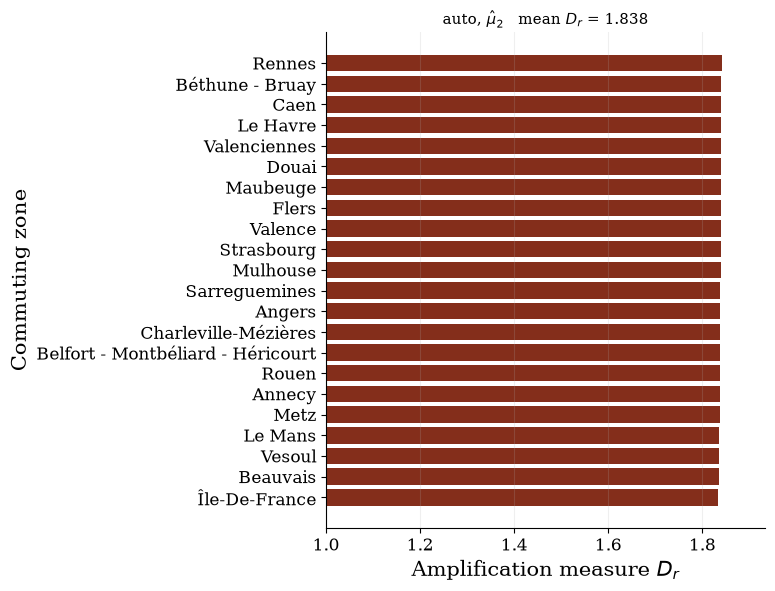

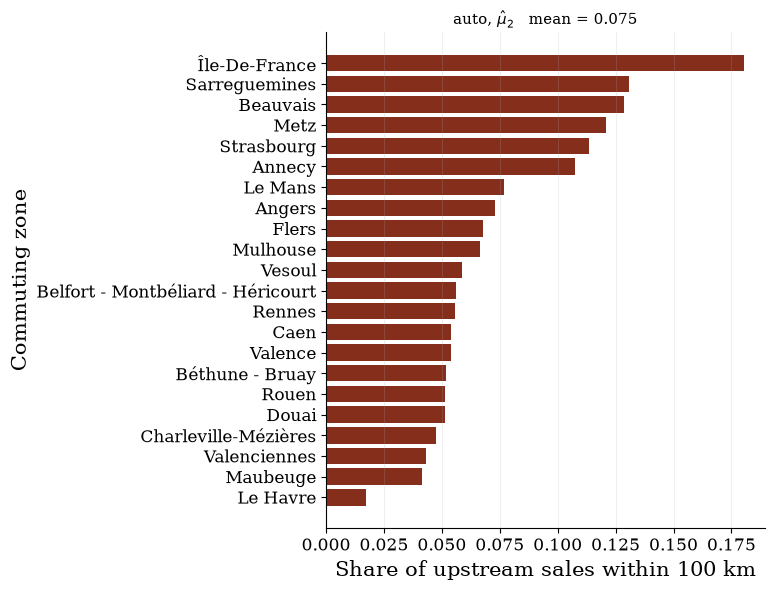

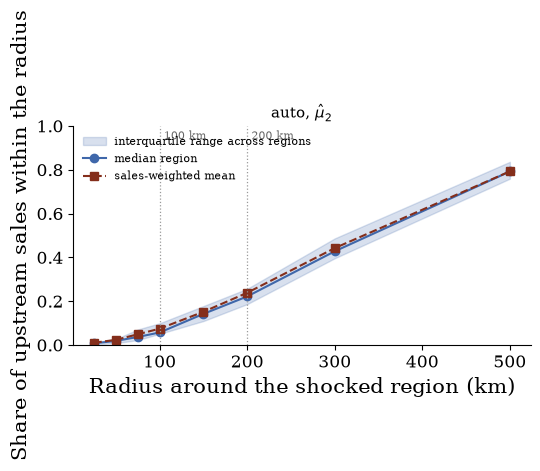

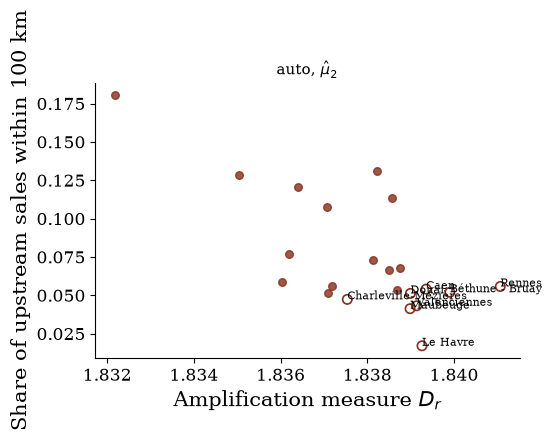

[auto]  downstream industry C29A, TES from ../baseline_auto (dom), intermediate share m = 0.8448979386516853
  model  : mean D_r = 1.838  -> the modelled domestic sectors are 0.838 of downstream unit cost
  IO     : those sectors are 63.5% of the industry's DOMESTIC intermediate purchases (67.3% of dom + imp; the column is 59.0% domestic)
           => implied TOTAL intermediate share of unit cost = 1.320
           1 - aggregate labor share (the targeted moment) = 0.845
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.447 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round 1)
  IO subset: round 1 = 1.845, two rounds = 2.559, Leontief total = 6.447   (model captures 15% of the aggregate, 99% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.845,2.559,6.447,1.838,0.154,0.992
subset,10,1.845,2.559,6.447,1.838,0.154,0.992


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C29A,1305.992,3491.482,4797.474,True,0.1602,0.0739,0.2380,0.2354
C29B,1264.404,1907.007,3171.411,True,0.1059,0.0715,0.1573,0.1577
G45Z,2368.608,0.000,2368.608,True,0.0791,0.1340,0.1175,0.1185
C28A,385.795,1799.754,2185.549,True,0.0730,0.0218,0.1084,0.1074
G46Z,1874.860,179.963,2054.823,True,0.0686,0.1060,0.1019,0.1054
C25D,1606.833,0.000,1606.833,True,0.0536,0.0909,0.0797,0.0800
C22B,841.858,514.752,1356.610,True,0.0453,0.0476,0.0673,0.0667
C33Z,1150.074,90.690,1240.764,True,0.0414,0.0650,0.0616,0.0619
M73Z,663.758,218.441,882.199,False,0.0295,0.0375,NaN,NaN


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


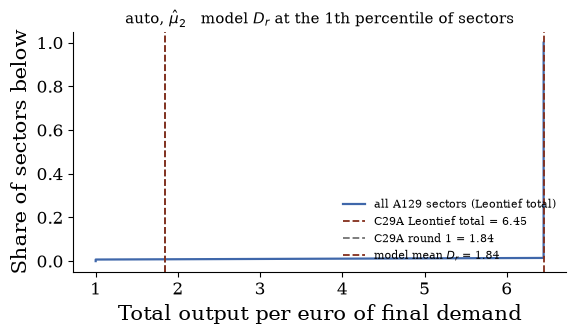

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero, mu = 2]  mean D_r = 1.841 (one euro of demand -> 0.841 upstream), p90 = 1.851
                 share of upstream sales within 100 km: mean 0.081, median 0.046, min 0.000, max 0.450
                 share of upstream sales within 200 km: mean 0.194, median 0.173, min 0.001, max 0.650


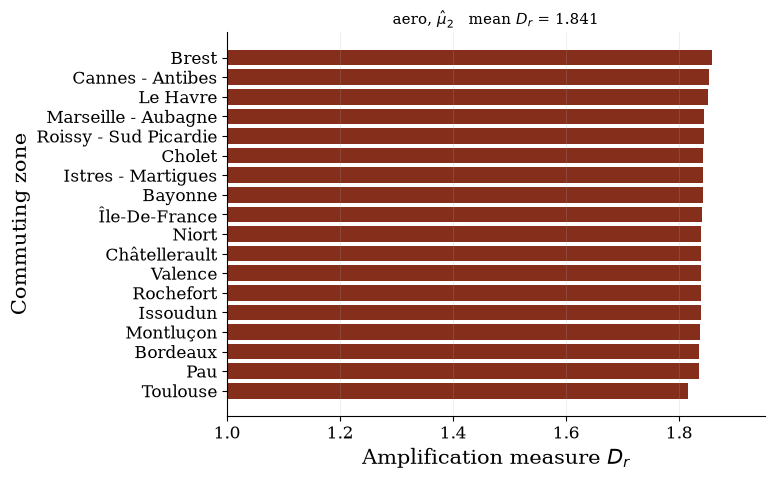

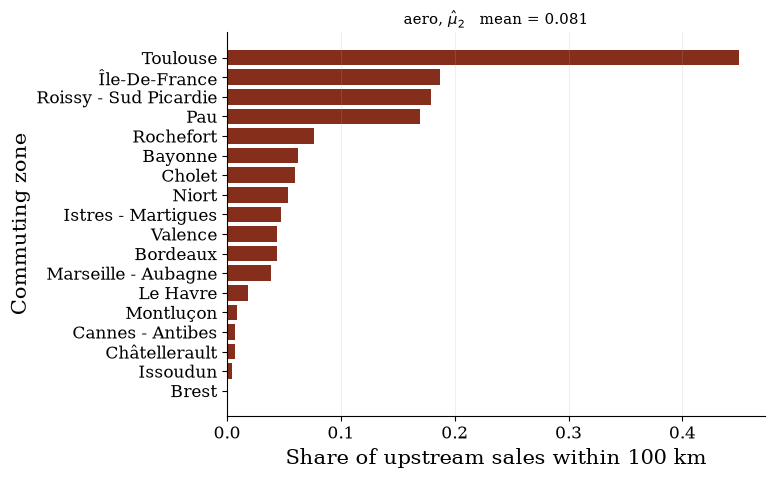

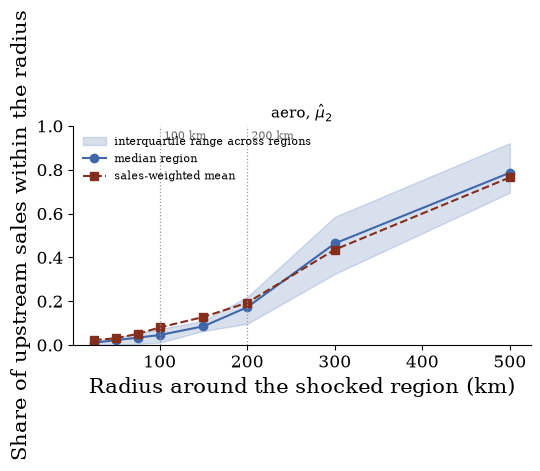

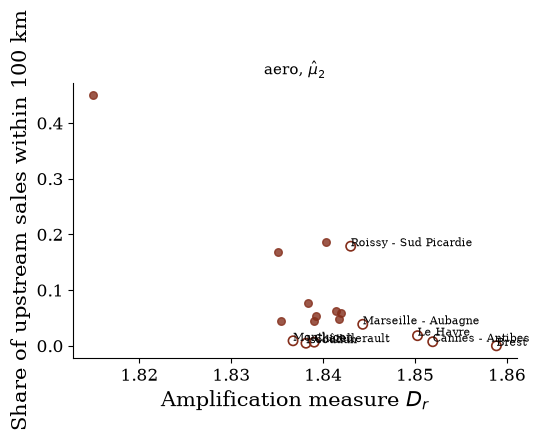

[aero]  downstream industry C30C, TES from ../baseline_aero (dom), intermediate share m = 0.8510782076751053
  model  : mean D_r = 1.841  -> the modelled domestic sectors are 0.841 of downstream unit cost
  IO     : those sectors are 72.3% of the industry's DOMESTIC intermediate purchases (80.5% of dom + imp; the column is 45.8% domestic)
           => implied TOTAL intermediate share of unit cost = 1.163
           1 - aggregate labor share (the targeted moment) = 0.851
  NOTE: a COMMON intermediate share was used, so every sector's Leontief total is exactly 1/(1-m) = 6.715 and the cascade below measures that assumption, not the network. Pass a per-sector `intermediate_share` (value added / gross output) for an informative comparison.
  IO full  : round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 99% of round 1)
  IO subset: round 1 = 1.851, two rounds = 2.575, Leontief total = 6.715   (model captures 15% of the aggregate, 99% of round

,n_sectors,round1,rounds_2,leontief_total,model_D_r,captured_of_aggregate,model_over_round1
support,,,,,,,
full,138,1.851,2.575,6.715,1.841,0.147,0.988
subset,10,1.851,2.575,6.715,1.841,0.147,0.988


,dom,imp,total,modelled,share_of_total,share_of_dom,pi_s_io,share_model
A129_1,,,,,,,,
C30C,6349.585,16899.867,23249.452,True,0.4979,0.2972,0.6184,0.6118
C33Z,4340.815,342.295,4683.110,True,0.1003,0.2032,0.1246,0.1306
C26E,12.912,2563.343,2576.255,True,0.0552,0.0006,0.0685,0.0692
G46Z,2124.009,203.879,2327.888,True,0.0499,0.0994,0.0619,0.0644
C28A,269.091,1255.322,1524.413,True,0.0326,0.0126,0.0405,0.0414
N78Z,977.000,0.000,977.000,False,0.0209,0.0457,NaN,NaN
M70Z,828.542,55.679,884.221,True,0.0189,0.0388,0.0235,0.0170
M71Z,569.876,148.231,718.107,True,0.0154,0.0267,0.0191,0.0209
C27B,110.626,468.915,579.541,True,0.0124,0.0052,0.0154,0.0169


plot_io_benchmark: the cross-sector distribution is degenerate under a common intermediate share (every sector at 1/(1-m)). The figure still places the model, but the spread is an artefact — pass a per-sector `intermediate_share` for a real distribution.


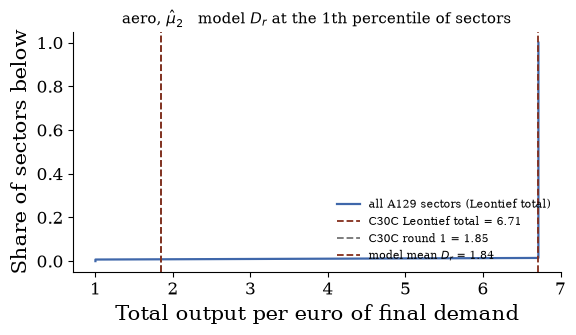

In [126]:
# --- RUN THIS SECTION ON ITS OWN -------------------------------------------
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name

    # --- Amplification along vertical linkages (Figure 6) --------------------
    # radii[0] is the radius the bar chart and the scatter use; change
    # AMPLIFICATION_RADII in the Constants cell to test another one.
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)

    # --- Is D_r large? the input-output benchmark ----------------------------
    # Guarded: without TESdom.csv / TESimp.csv beside the run this prints a note
    # instead of breaking the section.
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# Validation of the sections above

These sections do arithmetic that is easy to get wrong *silently*: an index space
confused for another, a mask applied on the wrong axis, an estimator that converges to
a plausible-looking number that is not the one intended. None of it would raise. So each
is gated by `test/test_analysis_granular_sections.py`, which needs neither Julia nor the
real data:

```bash
python test/test_analysis_granular_sections.py
```

It writes a **synthetic run tree with the exact file layout the loader expects** and then
executes **the notebook's own code cells** against it (located by content, not by index),
so what is tested is the shipped artefact rather than a copy that can drift from it. The
reasoning behind each gate:

**Identification / sensitivity.** Two risks. The *axis*: the variety-count columns are
appended on the right of the Jacobian by Julia, so the loader has to attach the label
block to the correct end, and a silent off-by-one would move the $N_s$ derivative onto the
wrong parameters and still look reasonable. The gate plants a diagonal
$\partial \bar G_s/\partial N_s$ and requires the embedded columns to be exactly zero off
block 6 and equal to $\hat N_s\,(\partial m/\partial N)/m$ on it. The *thresholds*: a
structural zero and an unmeasurable entry are different objects and must never be pooled,
so the gate plants one entry whose Monte-Carlo standard deviation is twice its elasticity
and requires it — and only it — to be masked, while the exact zeros come back as measured.

**Untargeted moment.** Two independent risks. The *wiring*: `fepois_fit` writes the
formula, passes the Monte-Carlo draw weights as analytic weights and clusters on the
supplier's region, and a mistake in any of those returns a plausible number without
complaint. It is checked against `statsmodels`' Poisson GLM with **explicit dummies** — a
different algorithm for the same estimand — agreeing to $10^{-6}$; a continuous share-like
outcome recovers a planted elasticity (Poisson PML is a conditional-*mean* estimator,
which is exactly why shares are admissible). The *panel*: the zeros are half the moment,
so the gate checks the grid is filled to exactly $n_{\text{firms}} \times R_d$ rows, that
$a_{ir}$ sums to one per supplier, and that every distance matches `distances.npy` read by
integer region index. The decomposition is checked for the sign of its extensive term, for
the identity closing to within the documented fixed-effect wedge, and for the intensive
regression running on strictly fewer cells than the total. The bin profile is checked to
normalise at the reference bin and to differ from the unconditional profile — i.e. that
the fixed effect is doing something.

**Untargeted count moment.** Three risks, none of which raises. The *selection*: the
empirical curve is a step function over finitely many commuting zones, so a crossing $K$
can land on a plateau where the data carry no mass, and a moment placed there compares
against granularity rather than against a measurement. The gate builds curves by hand —
one ordinary, one whose crossing sits on a flat step, one truncated before the halfway
point, one degenerate with no non-empty cell — and requires the rule to return the $K$ a
reader would pick, or nothing. The *estimator*: the hypergeometric estimator must be
unbiased for $\Pr(\mathrm{Bin}(N,q) \le K)$, which is checked by averaging it over the
exact $\mathrm{Bin}(m,q)$ law of the win count at three values of $q$ (to $10^{-14}$),
and it must collapse at $K=0$ onto `gbar_cell` transcribed from `model_CP.jl` — otherwise
the $K = 0$ column is not the fitted block-6 moment and nothing above it is comparable
either. The plug-in is checked to be biased at a realistic $m$ and to converge as $m$
grows, which is the contrast the section reports. The *inversion*: on a planted economy
whose empirical curve IS the model's own, $\hat N_s$, $K^*_s$ and $N^{(K^*)}_s$ must all
come back exactly and the gap must be zero; feeding the same economy a wrong variety count
must open the gap and leave the implied $N$ pointing back at the truth. The $q_{ls}$
fallback is checked to scatter into cells in Julia's column-major `findall` order — swap
it and the sectors silently get each other's cells.

**Comparative advantage.** The risk is the parameter layout: `best_params` is the raw
$\theta$, whose $T$ block is s-major over the *active* $(s, a)$ pairs and includes each
sector's reference, which `unpack_params` then divides out. Read it with the wrong offset
or the wrong ordering and every number downstream is wrong but finite. The gate plants a
known $T$, checks the recovered matrix equals $T/T_{\text{ref}}$ entry by entry, and
checks the length assertion fires on a mismatch. The win probabilities are recomputed
independently from the closed form and must agree; $\alpha = 0$ must make $\rho$
buyer-invariant and proportional to $T$; equalising $T$ must leave pure gravity; the
"Neither" regime must return exactly the uniform $1/n$. The variance decomposition is an
identity, so its three shares must sum to one to machine precision. Finally a sector is
given a large planted edge and one a flat profile, and the gate checks the summary ranks
them accordingly — that the measurement responds to the thing it claims to measure.

**Amplification.** The measure is a ratio whose numerator and denominator are easy to
mismatch — the denominator is upstream sales only, the numerator a distance-truncated part
of the same sum — and a wrong distance lookup would still produce a plausible bar chart.
The gate plants a firm-level economy in which every downstream region spends a known total
on intermediates, so $D_r = 1.5$ must come back exactly; it checks the
(region $\times$ region) grid is fully zero-filled, that every distance matches
`distances.npy` read by integer index, and that $L_r(d)$ reproduces a direct count on the
same frame. Because $L_r(\cdot)$ is a CDF in the radius, the profile must be monotone with
$p_{25}\le$ median $\le p_{75}$ throughout, a 10 000 km radius must return exactly one, and
a 0 km radius must keep the shocked region alone — four properties a sign error or a
transposed distance matrix would break. A smaller radius keeping strictly less than a
larger one is the check that the radius is genuinely free rather than baked in somewhere.

**The input-output benchmark.** Three separable risks. The *parser*: the TES CSV has
comma decimals, no header and its labels in the first column, so a silent misread would
transpose supplying and using sectors — the gate writes a known matrix out in that exact
format and requires it back, orientation included. The *normalisation*: each column of
$A$ must sum to the intermediate share it was given, scalar or per sector. The *algebra*:
under a common $m$ every column of $A$ sums to $m$, so
$\sum_i (A^k)_{ij} = m^k$ and the Leontief total must be exactly the geometric series
$1/(1-m)$ for every sector, with the truncations $1+m$ and $1+m+m^2$ — three closed
forms the gate checks to machine precision, which pins the inverse, the round
truncations and their nesting at once. It is also the reason the scalar path prints a
warning: that same identity means a common $m$ makes the cross-sector distribution
degenerate, so the cascade would be measuring the assumption rather than the network.
Finally the *coverage* numbers, which need no output data, are checked against a direct
share computation, and both an unknown downstream industry and an absent table must
raise something that names what is missing.

Two behaviours are asserted rather than assumed because they are the ones a reader would
otherwise have to take on trust: the exact zeros in the $N_s$ columns (structural, not
numerical) and the refusal to run the distance-equivalence under a binned trade cost,
where no single distance elasticity exists.

# Full Run

In [127]:
# =============================================================================
# RUN THE REPORTING — every section above, in order, on one set of flags.
#
# Each section can be run on its own from its own run cell; this cell re-executes all
# of them for a clean end-to-end pass. A new figure has to be added in BOTH places.
# =============================================================================
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 1

INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=False, optimizer="pso")

AMPLIFICATION_RADII = (100, 200)

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# --- Moment table: labor share + industry shares -----------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)

untargeted_results = []
untargeted_count_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Fit ------------------------------------------------------------------
    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()
    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()
    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()
    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Jacobian: the triptych, the per-block panels, the summary ------------
    plot_jacobian_triptych(data, noise_max=NOISE_MAX, out_folder=out_folder,
                           tag="jacobian")
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data, noise_max=NOISE_MAX))

    # --- Variance-covariance and correlation of the moments -------------------
    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))

    # --- Identification / sensitivity -----------------------------------------
    plot_identification_map(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data, threshold=IDENT_THRESHOLD, noise_max=NOISE_MAX))

    # --- Untargeted moment: the PPML distance elasticity of comovement --------
    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])
    ladder = untargeted_specification_ladder(data, panel=untargeted_results[-1]["panel"])
    plot_untargeted_ladder(ladder, industry,
                           save_to=f"{out_folder}/untargeted_ladder_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Untargeted moment: the supplier-count distribution beyond the zero ---
    untargeted_count_results.append(untargeted_count_moment(data))
    plot_count_cdf(untargeted_count_results[-1],
                   save_to=f"{out_folder}/untargeted_count_cdf_{industry}_mu{MU}.pdf")
    plt.show()
    plot_untargeted_count(untargeted_count_results[-1],
                          save_to=f"{out_folder}/untargeted_count_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Comparative advantage against distance: the six tests, in order -------
    plot_ca_distribution(                                            # 1 spread of T
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_distance_equivalence(                                    # 2 in distance units
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_win_margin(                                              # 3 the exact test
        data, save_to=f"{out_folder}/ca_win_margin_{industry}_mu{MU}.pdf")
    plt.show()
    display(ca_variance_decomposition(data))                         # 4 which force
    display(ca_covariance_benchmark(data))                           # 5 and the estimator
    plot_counterfactual_sourcing(                                    # 6 one force off
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_summary(data))

    # --- Amplification along vertical linkages (Figure 6) ---------------------
    summary, _ = amplification_report(data, radii=AMPLIFICATION_RADII,
                                      out_folder=out_folder)

    # --- Is D_r large? the input-output benchmark -----------------------------
    try:
        bench = io_amplification_benchmark(data, summary=summary)
        display(bench.round(3))
        display(io_downstream_column(data).head(15).round(4))
        plot_io_benchmark(data, benchmark=bench,
                          save_to=f"{out_folder}/io_benchmark_{industry}_mu{MU}.pdf")
        plt.show()
    except FileNotFoundError as e:
        print(f"  IO benchmark skipped: {e}")

# --- Untargeted moment: model eta against the reduced-form delta/gamma -------
plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))
display(untargeted_count_summary(untargeted_count_results))
for res in untargeted_count_results:                 # what statistical secrecy costs
    print(f"\n[{res['industry']}] censoring at {res['censor_min']}")
    display(res["censoring"].round(4))
display(comparative_advantage_glossary())


FileNotFoundError: run folder ../reporting_auto_profiled_aa_gran_pso not found — check profile_T / ca_level / granular / relax_n_lo / optimizer against main.jl's naming